# Anomaly Detection in Equity Portfolios

> **Welcome!** This notebook walks you through anomaly detection for a multi-asset equity portfolio — from the simplest statistical rule ("flag anything beyond 3 standard deviations") to industrial-strength machine-learning approaches (Isolation Forest, Autoencoders). **No prior background in anomaly detection is assumed.** Every section starts with a plain-English explanation before introducing any mathematics.

## Why Anomaly Detection Matters in Finance

> In plain English: an anomaly is a data point that is **surprisingly different** from what you would expect given the surrounding context. In financial portfolios, anomalies can signal:
> - A **fat-finger trade** that will be corrected (bad data)
> - A **regime change** — the market just shifted behaviour (real signal)
> - A **fraud or manipulation event** — e.g., wash trading, spoofing
> - A **liquidity crisis** — spreads blow out, correlations spike toward 1
> - A **model breakdown** — your risk model is no longer valid for current conditions

## What You Will Learn

| # | Technique | What It Detects | Complexity |
|---|-----------|----------------|------------|
| 1 | **Imports & Portfolio Data** | Synthetic 10-stock portfolio with planted anomalies | Foundation |
| 2 | **Z-Score & Modified Z-Score** | Return-level outliers per asset | ⭐ Beginner |
| 3 | **Rolling Bollinger Bands** | Regime-adjusted price deviations | ⭐ Beginner |
| 4 | **Interquartile Range (IQR)** | Robust non-parametric outlier detection | ⭐ Beginner |
| 5 | **Mahalanobis Distance** | Multivariate portfolio-level anomalies | ⭐⭐ Intermediate |
| 6 | **CUSUM — Change-Point Detection** | Structural breaks & mean-shift in returns | ⭐⭐ Intermediate |
| 7 | **Isolation Forest** | Non-linear anomaly manifold (ML) | ⭐⭐ Intermediate |
| 8 | **Local Outlier Factor (LOF)** | Density-based neighbourhood anomaly | ⭐⭐ Intermediate |
| 9 | **One-Class SVM** | Hyperplane separating normal vs anomalous | ⭐⭐⭐ Advanced |
| 10 | **Autoencoder (Neural Network)** | High-dimensional reconstruction error | ⭐⭐⭐ Advanced |
| 11 | **Ensemble Anomaly Score** | Combine all methods into one ranked signal | ⭐⭐⭐ Advanced |
| 12 | **Summary & Decision Guide** | When to use which method | — |

## The Big Picture

```
UNIVARIATE (per asset)       MULTIVARIATE (portfolio)     TEMPORAL (time-aware)
──────────────────────       ────────────────────────     ─────────────────────
Z-Score                      Mahalanobis Distance         CUSUM
Modified Z-Score             Isolation Forest             Rolling Bollinger Bands
IQR                          LOF                          Autoencoder (LSTM)
                             One-Class SVM

          ↓  All methods produce a score per day  ↓
          ↓  Ensemble: rank days by combined score ↓
          ↓  Visualise: Risk Calendar Heatmap      ↓
```

**Dataset:** 10-stock synthetic equity portfolio (1 000 trading days) with **planted anomalies** at known dates — so we can measure detection accuracy (precision, recall) for each method.

### Beginner Explanation

This notebook is about finding days that look unusual compared with the portfolio's normal behavior. In practice, that means spotting returns, correlations, or yield-curve moves that are too strange to ignore.

A simple way to think about the whole notebook is:

- first, define what "normal" looks like
- then, measure how far each day is from that normal pattern
- finally, compare different methods because each one sees a different kind of anomaly

If you are new to the topic, read each section with one question in mind: **what kind of abnormal event is this method best at catching?**

## 1. Import Libraries & Generate Portfolio Data

### What We Import and Why

| Library | Purpose in This Notebook |
|---------|--------------------------|
| `numpy`, `pandas` | Array math and tabular data handling |
| `matplotlib`, `seaborn` | All charts and heatmaps |
| `scipy.stats` | Z-scores, chi-squared, statistical tests |
| `sklearn` | Isolation Forest, LOF, One-Class SVM, preprocessing |
| `tensorflow.keras` | Autoencoder neural network |

### Synthetic Portfolio Design

We simulate **10 correlated equity stocks** over 1 000 trading days, then **plant anomalies** at known locations:

| Anomaly Type | How Planted | What It Represents |
|-------------|------------|-------------------|
| Return spike | 5–8× normal vol at specific dates | Flash crash / fat-finger |
| Correlation breakdown | Intra-sector correlation collapses | Contagion / liquidity crisis |
| Volatility regime shift | Vol doubles from day 400–450 | VIX spike / market stress |
| Mean shift | Portfolio drifts by 3 standard deviations | Systematic model bias |

> **Why synthetic data?** With real data you never know the *ground truth* (which days were truly anomalous). Synthetic data lets us compute precision, recall, and F1 — measuring how accurately each algorithm finds what we planted.

### Beginner Explanation

This section creates the practice dataset for the notebook. Instead of waiting for real market anomalies, the notebook builds a synthetic portfolio and deliberately inserts abnormal events so every method can be tested against known answers.

That is useful for learning because you can ask two clear questions:

- did the method flag the abnormal day?
- did it also create too many false alarms on normal days?

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import mahalanobis
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
print("✓ All libraries imported successfully")

✓ All libraries imported successfully


✓ Portfolio: 10 stocks × 1000 trading days
✓ Planted anomalies: 98 days (9.8% of all days)

Return statistics (first 5 stocks):
            AAPL       MSFT      GOOGL       AMZN       META
count  1000.0000  1000.0000  1000.0000  1000.0000  1000.0000
mean     -0.0002     0.0001    -0.0005    -0.0012    -0.0013
std       0.0227     0.0209     0.0240     0.0277     0.0248
min      -0.1040    -0.1145    -0.0980    -0.1358    -0.1181
25%      -0.0117    -0.0115    -0.0134    -0.0163    -0.0149
50%       0.0002     0.0003     0.0002    -0.0001     0.0007
75%       0.0125     0.0127     0.0134     0.0144     0.0141
max       0.1683     0.1388     0.1867     0.1952     0.0842


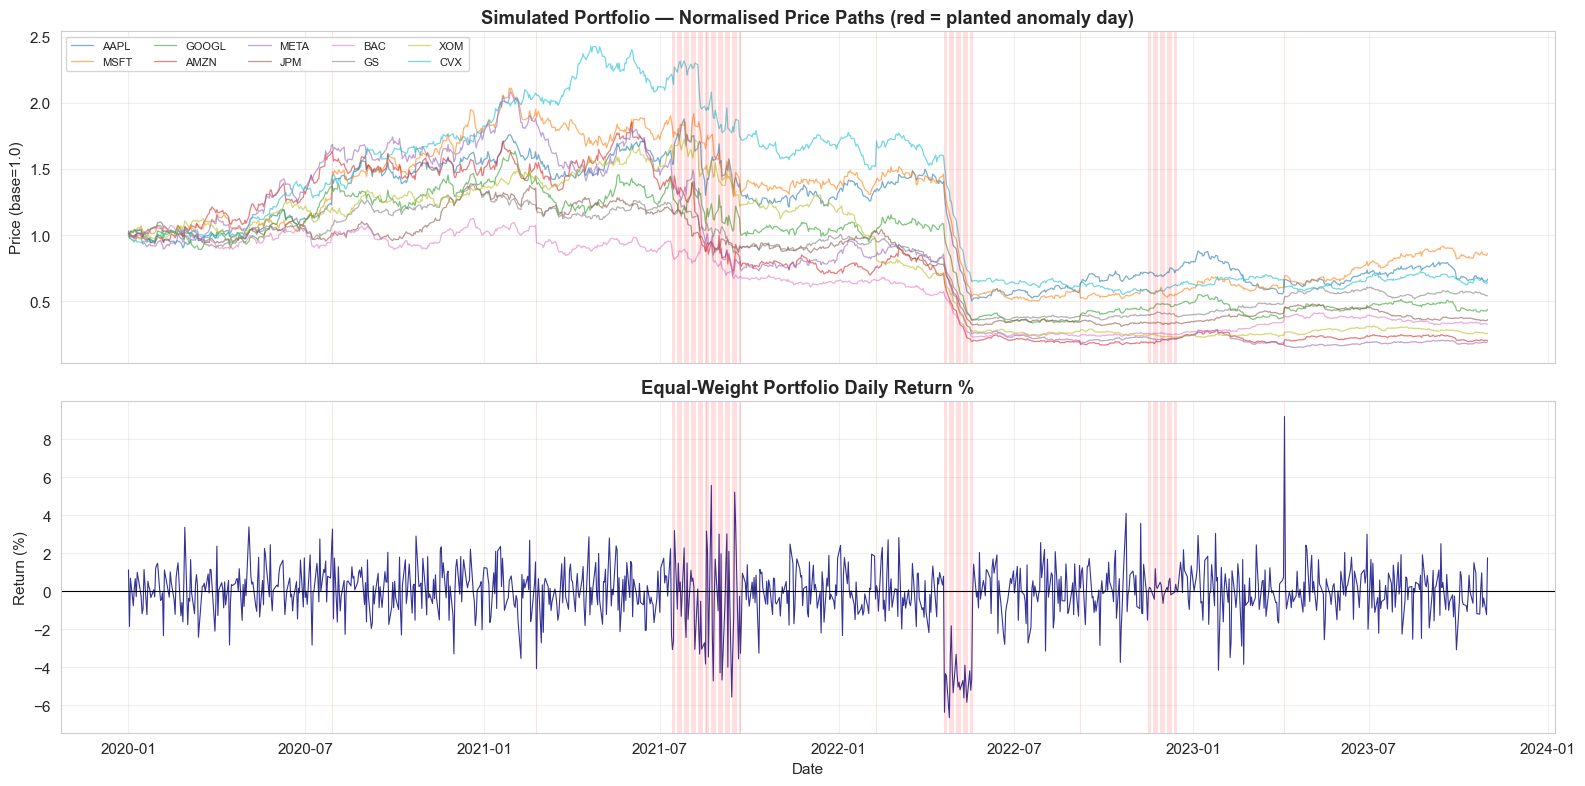

In [6]:
np.random.seed(42)

# ── Portfolio Parameters ──────────────────────────────────────────────────────
N_DAYS    = 1000
N_STOCKS  = 10
TICKERS   = ['AAPL','MSFT','GOOGL','AMZN','META','JPM','BAC','GS','XOM','CVX']
SECTORS   = ['Tech','Tech','Tech','Tech','Tech','Finance','Finance','Finance','Energy','Energy']
dates     = pd.date_range('2020-01-01', periods=N_DAYS, freq='B')

# ── Correlation structure (intra-sector ≈ 0.7, cross-sector ≈ 0.3) ───────────
corr = np.full((N_STOCKS, N_STOCKS), 0.30)
# Tech block (0-4)
corr[0:5, 0:5] = 0.70
# Finance block (5-7)
corr[5:8, 5:8] = 0.70
# Energy block (8-10)
corr[8:, 8:] = 0.70
np.fill_diagonal(corr, 1.0)
L = np.linalg.cholesky(corr)

# Annualised parameters (per stock)
mu_annual  = np.array([0.15, 0.18, 0.12, 0.20, 0.14, 0.10, 0.09, 0.11, 0.08, 0.09])
vol_annual = np.array([0.28, 0.26, 0.30, 0.35, 0.32, 0.22, 0.24, 0.20, 0.25, 0.23])
mu_daily   = mu_annual / 252
vol_daily  = vol_annual / np.sqrt(252)

# ── Generate correlated base returns ─────────────────────────────────────────
Z      = np.random.randn(N_DAYS, N_STOCKS)
Z_corr = Z @ L.T
returns_base = mu_daily + Z_corr * vol_daily  # shape (N_DAYS, N_STOCKS)

returns = returns_base.copy()

# ── Plant known anomalies ─────────────────────────────────────────────────────
# We record every anomalous day so we can measure detection accuracy later
anomaly_days = set()

# 1. Return spikes: individual stocks on specific days (flash-crash style)
spike_events = [(150, [0, 1], 8.0),   # Tech crash: AAPL, MSFT spike 8σ
                (300, [5, 6], 7.0),   # Finance shock: JPM, BAC
                (550, [8, 9], 9.0),   # Energy shock: XOM, CVX
                (700, [0,1,2,3,4], 6.0),  # Broad tech selloff
                (850, list(range(10)), 7.0)]  # Market-wide crash
for day, stocks, sigma_mult in spike_events:
    for s in stocks:
        returns[day, s] = returns[day, s] + sigma_mult * vol_daily[s] * np.random.choice([-1, 1])
    anomaly_days.add(day)

# 2. Volatility regime shift: days 400–450, vol doubles
for d in range(400, 451):
    returns[d, :] = returns[d, :] * 2.5
    anomaly_days.add(d)

# 3. Mean shift: days 600–620, portfolio drifts significantly negative
for d in range(600, 621):
    returns[d, :] -= 3.0 * vol_daily
    anomaly_days.add(d)

# 4. Correlation breakdown: days 750–770, intra-sector corr collapses
Z_uncorr = np.random.randn(21, N_STOCKS) * vol_daily
for i, d in enumerate(range(750, 771)):
    returns[d, :] = mu_daily + Z_uncorr[i]
    anomaly_days.add(d)

# ── Build DataFrames ──────────────────────────────────────────────────────────
df_ret    = pd.DataFrame(returns, index=dates, columns=TICKERS)
df_prices = 100 * (1 + df_ret).cumprod()

# Ground truth anomaly flag (1 = anomalous day, 0 = normal)
y_true = np.zeros(N_DAYS, dtype=int)
for d in anomaly_days:
    y_true[d] = 1

print(f"✓ Portfolio: {N_STOCKS} stocks × {N_DAYS} trading days")
print(f"✓ Planted anomalies: {len(anomaly_days)} days ({100*len(anomaly_days)/N_DAYS:.1f}% of all days)")
print(f"\nReturn statistics (first 5 stocks):")
print(df_ret[TICKERS[:5]].describe().round(4))

# ── Overview Chart ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Normalised price paths
ax = axes[0]
for t in TICKERS:
    ax.plot(dates, df_prices[t] / 100, alpha=0.6, linewidth=0.9, label=t)
# Shade anomaly regions
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='red', alpha=0.15, linewidth=0.6)
ax.set_title('Simulated Portfolio — Normalised Price Paths (red = planted anomaly day)', fontweight='bold')
ax.set_ylabel('Price (base=1.0)')
ax.legend(ncol=5, fontsize=8, loc='upper left')
ax.grid(alpha=0.3)

# Portfolio equal-weight daily return
ax = axes[1]
ptf_ret = df_ret.mean(axis=1)
ax.plot(dates, ptf_ret * 100, color='navy', linewidth=0.8, alpha=0.8)
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='red', alpha=0.15, linewidth=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Equal-Weight Portfolio Daily Return %', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.set_xlabel('Date')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Z-Score & Modified Z-Score

> **In plain English:** The Z-score asks: "How many standard deviations is this return away from the mean?" If a stock normally moves ±1% per day and today it moved −8%, its Z-score is −8. We flag days where |Z| > threshold (usually 3.0).
>
> **The problem with regular Z-scores in finance:** Financial returns have fat tails. A single extreme event (say, the 2008 GFC crash) inflates both the mean and standard deviation, making subsequent anomalies appear smaller. The **modified Z-score** uses the **median** and **MAD (Median Absolute Deviation)** instead — which are resistant to outliers contaminating the reference distribution.
>
> **Thresholds:**
> | Threshold | Sensitivity | False Positive Rate |
> |-----------|------------|---------------------|
> | |Z| > 2.0 | High — catches subtle outliers | Many false positives |
> | |Z| > 3.0 | Standard — 0.3% chance for normal data | Balanced |
> | |Z| > 3.5 | Conservative — only extreme events | Few false positives |
>
> **Modified Z-score formula:** $M_i = \frac{0.6745 \cdot (x_i - \tilde{x})}{\text{MAD}}$ where $\tilde{x}$ is the median and MAD = median(|x_i - \tilde{x}|)

### What to Look For in the Output
- **Per-asset heatmap**: which stocks flag anomalous on which days
- **Portfolio-level score**: days where *multiple* stocks simultaneously breach the threshold are the most dangerous (systemic events, not idiosyncratic)

### Beginner Explanation

A Z-score is one of the simplest anomaly tools because it just checks how unusually large a move is compared with typical history. If the move is far from the average, the day gets attention.

The modified Z-score exists because financial data often has extreme events already baked into history. Using the median and MAD makes the benchmark less distorted by past crashes.

Z-Score (standard)              Precision=0.902  Recall=0.561  F1=0.692  Flagged=61
Modified Z-Score (MAD)          Precision=0.791  Recall=0.694  F1=0.739  Flagged=86


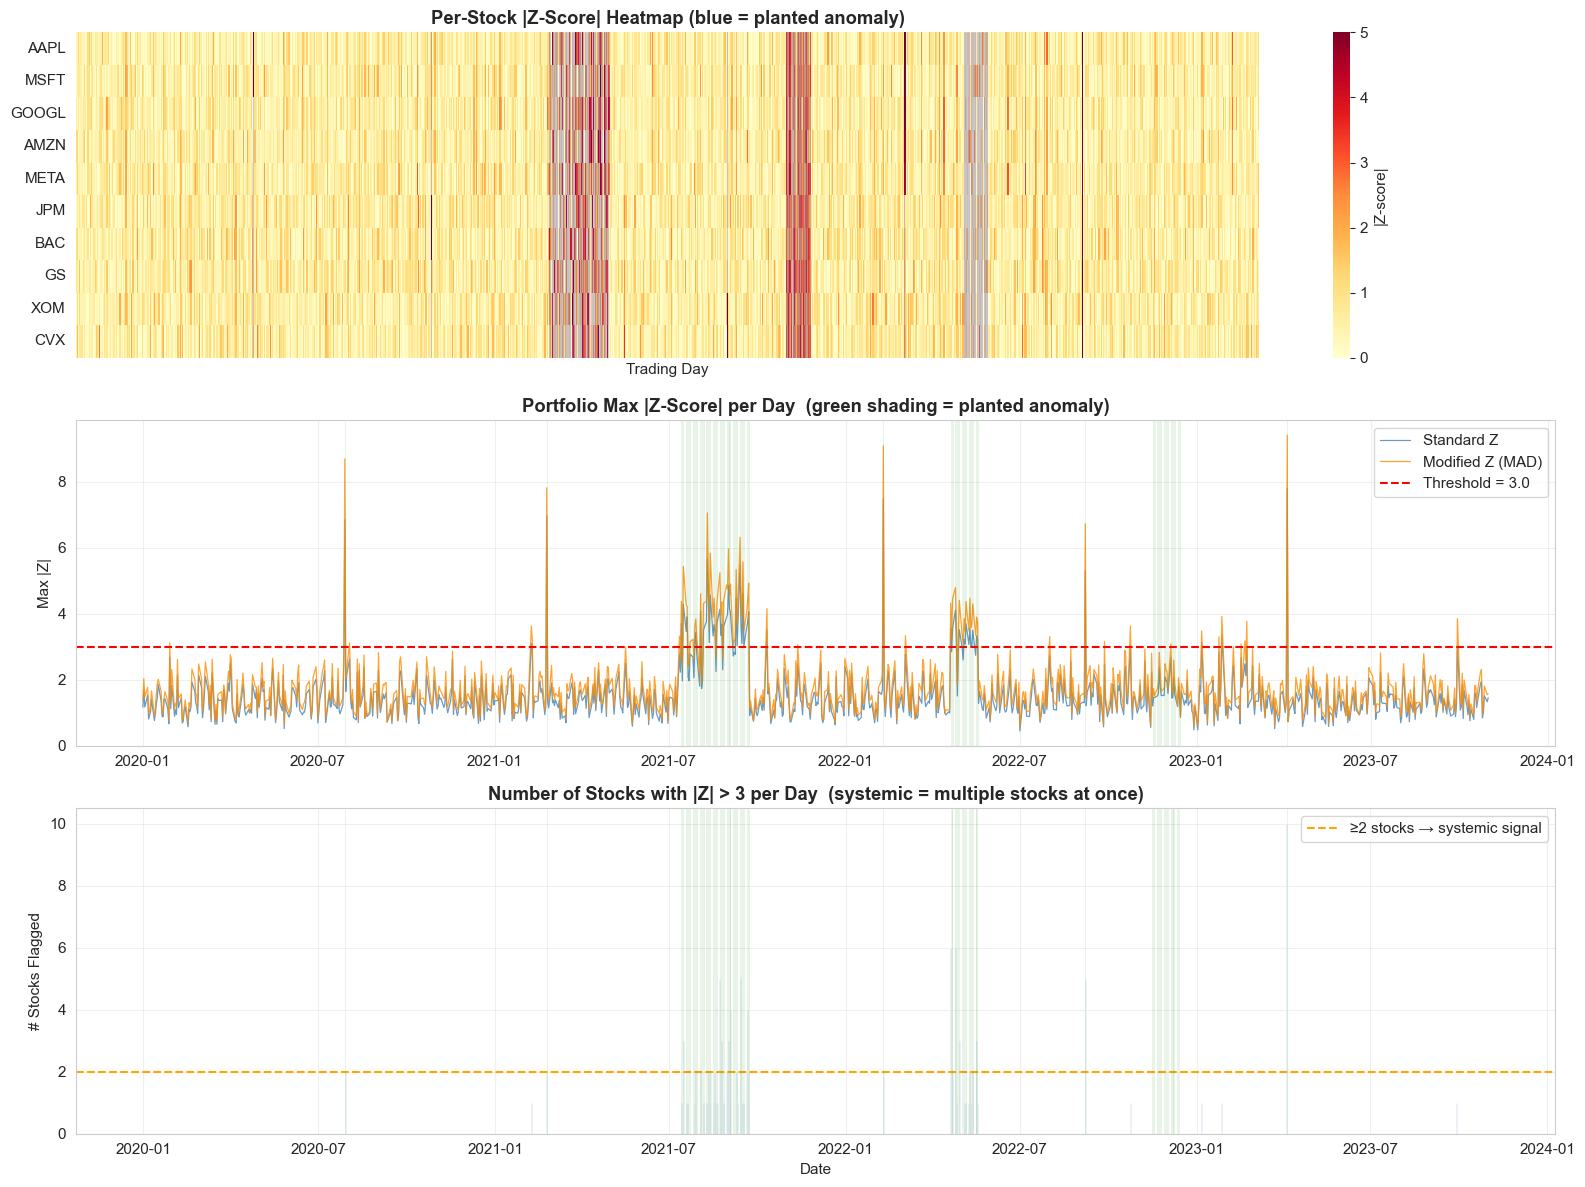

In [7]:
ZSCORE_THRESH = 3.0

# ── Standard Z-score ──────────────────────────────────────────────────────────
z_scores = df_ret.apply(lambda col: (col - col.mean()) / col.std())

# ── Modified Z-score (MAD-based, robust to outliers) ─────────────────────────
def modified_zscore(series):
    median = series.median()
    mad    = (series - median).abs().median()
    return 0.6745 * (series - median) / (mad + 1e-10)

mz_scores = df_ret.apply(modified_zscore)

# Portfolio-level: max absolute Z across all stocks on each day
z_portfolio  = z_scores.abs().max(axis=1)
mz_portfolio = mz_scores.abs().max(axis=1)

# Flag anomalous days
z_flags  = (z_portfolio  > ZSCORE_THRESH).astype(int).values
mz_flags = (mz_portfolio > ZSCORE_THRESH).astype(int).values

# ── Evaluation helper ─────────────────────────────────────────────────────────
def evaluate(name, y_pred, y_true=y_true):
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"{name:<30s}  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}  "
          f"Flagged={y_pred.sum()}")
    return {'name': name, 'precision': p, 'recall': r, 'f1': f1,
            'flagged': int(y_pred.sum())}

results = []
results.append(evaluate("Z-Score (standard)", z_flags))
results.append(evaluate("Modified Z-Score (MAD)", mz_flags))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Heatmap of per-stock |Z-scores|
ax = axes[0]
sns.heatmap(z_scores.abs().T, ax=ax, cmap='YlOrRd', vmin=0, vmax=5,
            xticklabels=False, yticklabels=TICKERS,
            cbar_kws={'label': '|Z-score|'})
# Mark anomaly columns
for d in sorted(anomaly_days):
    ax.axvline(d, color='blue', alpha=0.3, linewidth=0.5)
ax.set_title('Per-Stock |Z-Score| Heatmap (blue = planted anomaly)', fontweight='bold')
ax.set_xlabel('Trading Day')

# 2. Portfolio max |Z| over time
ax = axes[1]
ax.plot(dates, z_portfolio,  color='steelblue', alpha=0.8, linewidth=0.9, label='Standard Z')
ax.plot(dates, mz_portfolio, color='darkorange', alpha=0.8, linewidth=0.9, label='Modified Z (MAD)')
ax.axhline(ZSCORE_THRESH, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {ZSCORE_THRESH}')
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='green', alpha=0.12, linewidth=0.5)
ax.set_title('Portfolio Max |Z-Score| per Day  (green shading = planted anomaly)', fontweight='bold')
ax.set_ylabel('Max |Z|')
ax.legend()
ax.grid(alpha=0.3)

# 3. Number of stocks breaching threshold on each day
ax = axes[2]
stocks_above = (z_scores.abs() > ZSCORE_THRESH).sum(axis=1)
ax.bar(dates, stocks_above, width=1, color='steelblue', alpha=0.7)
ax.axhline(2, color='orange', linestyle='--', linewidth=1.5, label='≥2 stocks → systemic signal')
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='green', alpha=0.12, linewidth=0.5)
ax.set_title('Number of Stocks with |Z| > 3 per Day  (systemic = multiple stocks at once)',
             fontweight='bold')
ax.set_ylabel('# Stocks Flagged')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Rolling Bollinger Bands

> **In plain English:** A static Z-score uses the *full-history* mean and std. But in markets, volatility is time-varying — what looked like a 3σ event in calm 2017 markets would be a 1σ event during COVID 2020. Rolling Bollinger Bands solve this by computing the mean and standard deviation over a **rolling window** (typically 20 days), so the bands automatically widen during high-vol regimes.
>
> **How it works:** For each day t, compute the rolling 20-day mean μ_t and std σ_t of the portfolio return. Flag any day where the return is more than k·σ_t away from μ_t.
>
> **Finance context:** Bollinger Bands are one of the most widely used technical indicators. In equities, a band breach often signals:
> - A **mean-reversion opportunity** (contrarian traders buy the lower band)
> - A **breakout** (momentum traders go with the direction)
> - An **anomaly** worth investigating for risk purposes
>
> **Key insight:** The rolling approach captures **regime-conditional** anomalies. A 2% single-day loss in calm markets is anomalous. The same 2% loss during a VIX spike is completely normal — and rolling bands correctly account for this.

### Beginner Explanation

Rolling Bollinger Bands are useful when markets change mood over time. Instead of comparing today with the entire history, they compare today with the recent local regime.

That means the method is less likely to panic during already-volatile periods and more likely to notice moves that are abnormal for the current environment.

Bollinger Bands (20d, 2.5σ)     Precision=0.154  Recall=0.020  F1=0.036  Flagged=13


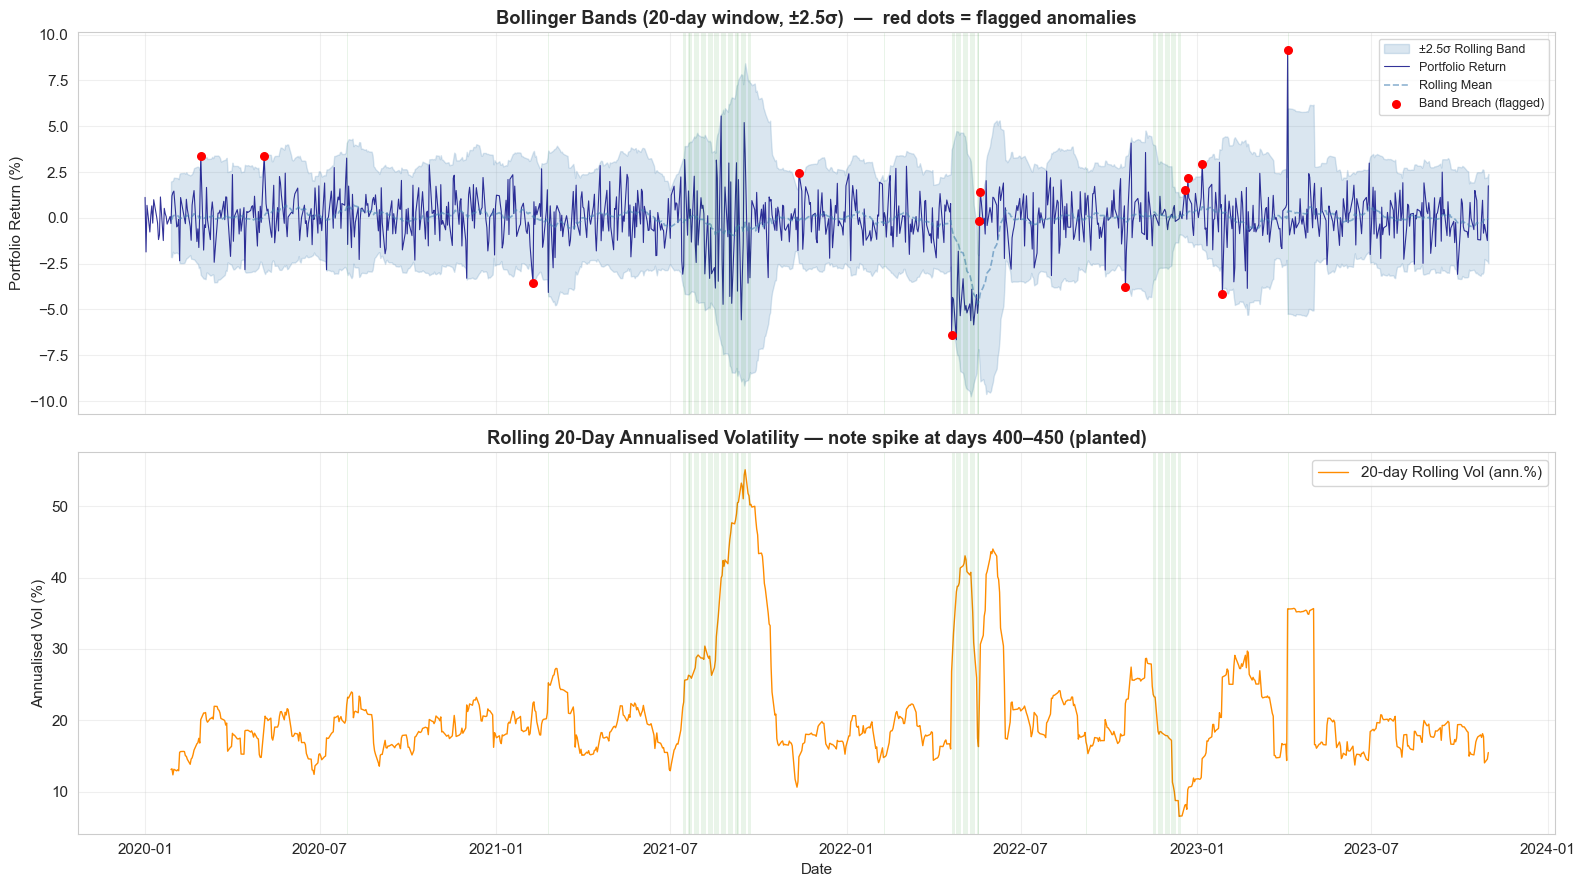


Bollinger Band breaches: 13 days flagged
Of which overlap with planted anomalies: 2 days


In [8]:
WINDOW = 20
BB_K   = 2.5   # number of std deviations for the band

# Equal-weight portfolio return
ptf_ret = df_ret.mean(axis=1)

# Rolling bands
roll_mean = ptf_ret.rolling(WINDOW).mean()
roll_std  = ptf_ret.rolling(WINDOW).std()
upper_band = roll_mean + BB_K * roll_std
lower_band = roll_mean - BB_K * roll_std

# Flag days outside the bands
bb_breach  = ((ptf_ret > upper_band) | (ptf_ret < lower_band)).astype(int)
bb_flags   = bb_breach.fillna(0).astype(int).values

results.append(evaluate("Bollinger Bands (20d, 2.5σ)", bb_flags))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Portfolio return with Bollinger Bands
ax = axes[0]
ax.fill_between(dates, lower_band * 100, upper_band * 100,
                alpha=0.2, color='steelblue', label=f'±{BB_K}σ Rolling Band')
ax.plot(dates, ptf_ret * 100, color='navy', linewidth=0.8, alpha=0.8, label='Portfolio Return')
ax.plot(dates, roll_mean * 100, color='steelblue', linewidth=1.2, linestyle='--',
        alpha=0.6, label='Rolling Mean')

# Mark breaches in red
breach_dates  = dates[bb_breach.astype(bool)]
breach_values = ptf_ret[bb_breach.astype(bool)] * 100
ax.scatter(breach_dates, breach_values, color='red', zorder=5, s=30, label='Band Breach (flagged)')

for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='green', alpha=0.12, linewidth=0.5)
ax.set_title(f'Bollinger Bands ({WINDOW}-day window, ±{BB_K}σ)  —  red dots = flagged anomalies',
             fontweight='bold')
ax.set_ylabel('Portfolio Return (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Rolling volatility (annualised)
ax = axes[1]
roll_vol_ann = roll_std * np.sqrt(252) * 100
ax.plot(dates, roll_vol_ann, color='darkorange', linewidth=1.0, label='20-day Rolling Vol (ann.%)')
# Shade anomaly regions
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='green', alpha=0.12, linewidth=0.5)
ax.set_title('Rolling 20-Day Annualised Volatility — note spike at days 400–450 (planted)',
             fontweight='bold')
ax.set_ylabel('Annualised Vol (%)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBollinger Band breaches: {bb_flags.sum()} days flagged")
print(f"Of which overlap with planted anomalies: "
      f"{(bb_flags & y_true).sum()} days")

## 4. Interquartile Range (IQR) — Robust Outlier Detection

> **In plain English:** IQR is the range between the 25th and 75th percentiles of your data. The rule: any point more than **1.5 × IQR below Q1** or **above Q3** is an outlier. It's the same rule your statistics teacher used for box plots — but it works surprisingly well on financial returns.
>
> **Why IQR is more robust than Z-scores:** Z-scores use the mean and standard deviation, both of which are heavily influenced by extreme values. IQR only uses the middle 50% of the data, so extreme past events don't inflate the "normal" band. This is called **breakdown point = 50%** — you'd need to corrupt 50% of the data to fool the IQR estimate.
>
> **The multiplier choice:**
> - **1.5 × IQR** → standard "mild" outlier threshold (Tukey's fence)
> - **3.0 × IQR** → "extreme" outlier threshold (only very severe events)
>
> For financial data, 3.0× is typically more appropriate since returns naturally have heavier tails than a Gaussian distribution.

### Beginner Explanation

The IQR rule is a robust way to define what counts as unusually far from the middle of the data. It focuses on the middle 50% of observations and ignores the influence of extreme past points.

That makes it a good beginner tool when you suspect the data is not nicely bell-shaped and you do not want a few old crises to redefine what "normal" means.

IQR (3.0× fence, ≥1 stock)      Precision=1.000  Recall=0.194  F1=0.325  Flagged=19


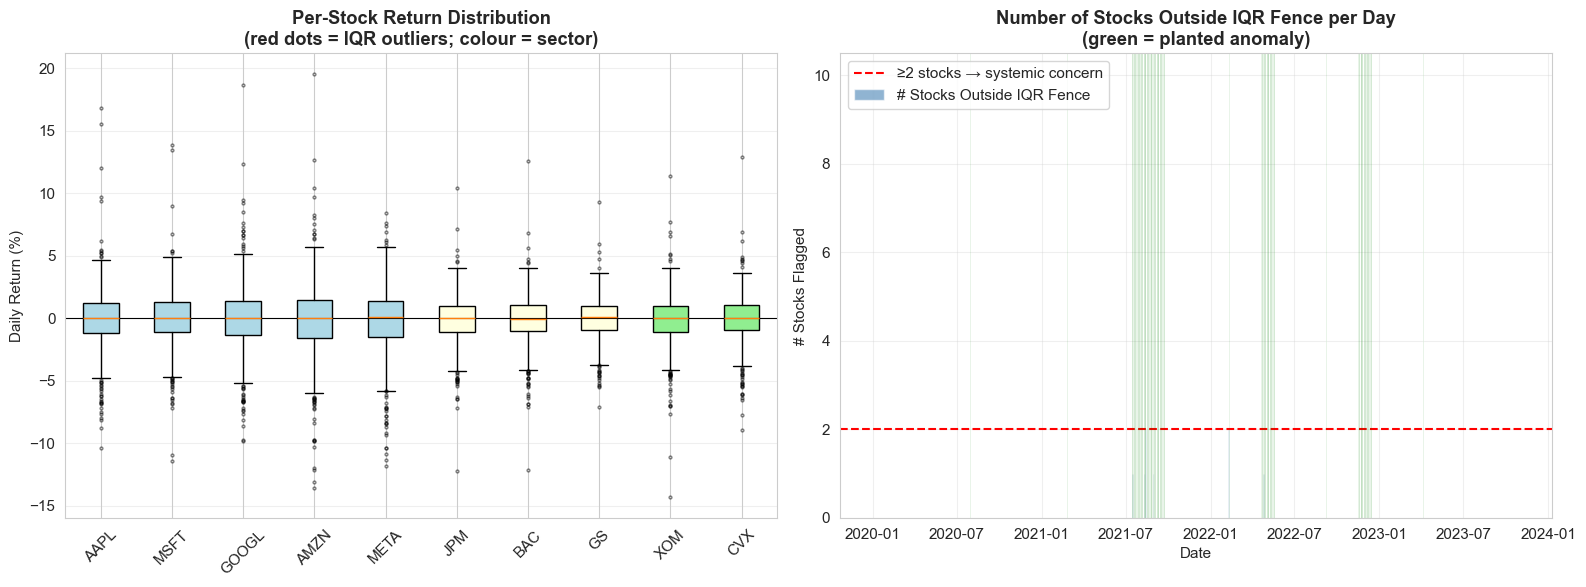

In [5]:
IQR_MULT = 3.0

# Per-stock IQR outlier detection
q1   = df_ret.quantile(0.25)
q3   = df_ret.quantile(0.75)
iqr  = q3 - q1
lower_iqr = q1 - IQR_MULT * iqr
upper_iqr = q3 + IQR_MULT * iqr

# A day is anomalous if ANY stock is outside its IQR fence
iqr_breach_per_stock = (df_ret < lower_iqr) | (df_ret > upper_iqr)
iqr_count_per_day    = iqr_breach_per_stock.sum(axis=1)  # #stocks breaching
iqr_flags            = (iqr_count_per_day >= 1).astype(int).values

results.append(evaluate("IQR (3.0× fence, ≥1 stock)", iqr_flags))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plots per stock
ax = axes[0]
plot_data = [df_ret[t].values * 100 for t in TICKERS]
bp = ax.boxplot(plot_data, labels=TICKERS, patch_artist=True,
                flierprops=dict(marker='o', markersize=2, alpha=0.5, color='red'))
for patch, sector in zip(bp['boxes'], SECTORS):
    colour = 'lightblue' if sector == 'Tech' else ('lightyellow' if sector == 'Finance' else 'lightgreen')
    patch.set_facecolor(colour)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Per-Stock Return Distribution\n(red dots = IQR outliers; colour = sector)',
             fontweight='bold')
ax.set_ylabel('Daily Return (%)')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

# IQR breach count per day over time
ax = axes[1]
ax.bar(dates, iqr_count_per_day, width=1, color='steelblue', alpha=0.6,
       label='# Stocks Outside IQR Fence')
ax.axhline(2, color='red', linestyle='--', linewidth=1.5,
           label='≥2 stocks → systemic concern')
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='green', alpha=0.12, linewidth=0.5)
ax.set_title('Number of Stocks Outside IQR Fence per Day\n(green = planted anomaly)',
             fontweight='bold')
ax.set_ylabel('# Stocks Flagged')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Mahalanobis Distance — Multivariate Portfolio Anomalies

> **In plain English:** The Z-score looks at each stock individually and asks "is this one stock's return unusual?" Mahalanobis distance looks at **all 10 stocks simultaneously** and asks "is this *combination* of returns unusual?" This matters because:
>
> - AAPL down 2%, MSFT down 2% simultaneously is *much more* unusual than either alone (if they are normally correlated at 0.7, seeing both crash together is a much rarer joint event)
> - A day where tech stocks are up and energy stocks are down might be unremarkable individually but unusual for the portfolio structure
>
> **The formula:**  $D_M(x) = \sqrt{(x - \mu)^T \Sigma^{-1} (x - \mu)}$
>
> where $\Sigma$ is the covariance matrix of returns. $D_M$ accounts for both scale (like Z-score) and correlations. Under multivariate normality, $D_M^2$ follows a $\chi^2$ distribution with k degrees of freedom (k = number of assets).
>
> **Threshold:** We flag the top 1% of $D_M^2$ by the $\chi^2(k)$ distribution. This gives us a statistically principled threshold without arbitrary tuning.

### Why This Catches What Z-Scores Miss
A flash crash might see every stock fall by exactly their normal proportion — individually unremarkable Z-scores — but the *joint* extreme is captured by Mahalanobis distance.

### Beginner Explanation

Mahalanobis distance is a portfolio-level version of outlier detection. Instead of asking whether one stock moved too much, it asks whether the whole combination of stock moves looks unusual together.

This matters because markets can produce strange patterns even when no single stock looks extreme by itself. The anomaly may live in the relationship between assets, not in one number alone.

Mahalanobis Distance (χ²,99%)   Precision=1.000  Recall=0.561  F1=0.719  Flagged=55


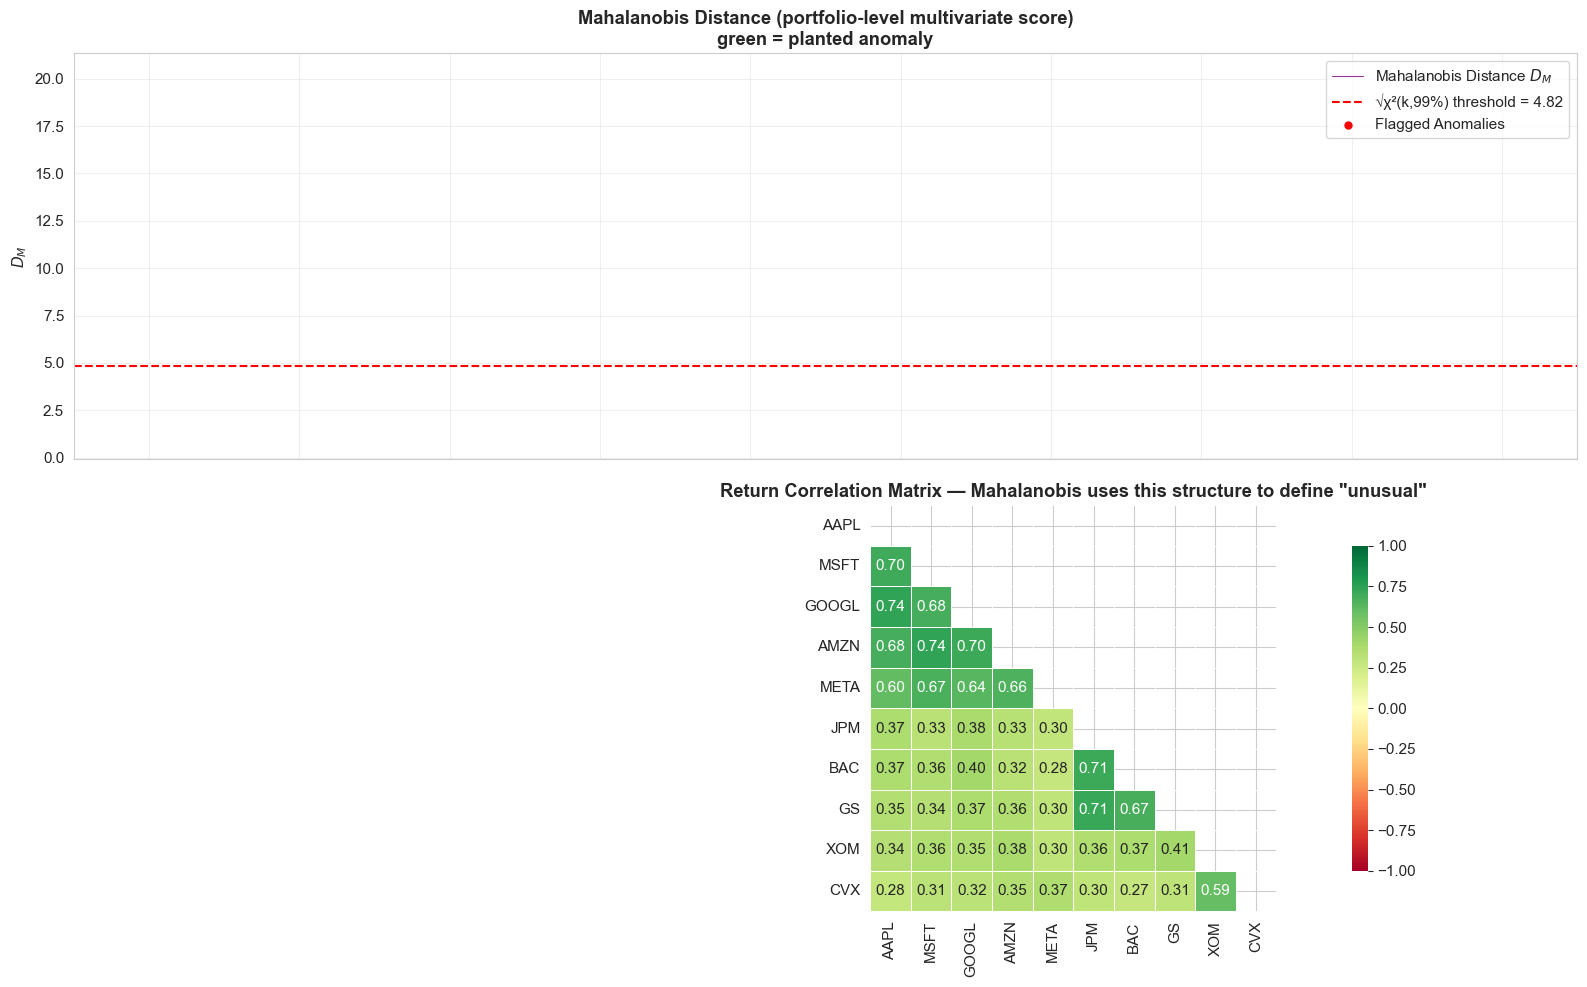


χ²(10) 99th percentile = 23.21  →  D_M threshold = 4.82
Mahalanobis flags 55 days as anomalous


In [6]:
from scipy.stats import chi2

# Estimate covariance on the full dataset (for simplicity; robust covariance via MCD is better in production)
X = df_ret.values
mu_vec = X.mean(axis=0)
cov    = np.cov(X.T)
cov_inv = np.linalg.pinv(cov)  # pseudo-inverse for numerical stability

# Mahalanobis distance for each day
def maha(row, mu, cov_inv):
    diff = row - mu
    return np.sqrt(diff @ cov_inv @ diff)

maha_dist = np.array([maha(X[i], mu_vec, cov_inv) for i in range(N_DAYS)])
maha_sq   = maha_dist ** 2

# Chi-squared threshold at 99th percentile with k degrees of freedom
k         = N_STOCKS
chi2_thr  = chi2.ppf(0.99, df=k)
maha_flags = (maha_sq > chi2_thr).astype(int)

results.append(evaluate("Mahalanobis Distance (χ²,99%)", maha_flags))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Mahalanobis distance over time
ax = axes[0]
ax.plot(dates, maha_dist, color='purple', linewidth=0.8, alpha=0.8,
        label='Mahalanobis Distance $D_M$')
threshold_line = np.sqrt(chi2_thr)
ax.axhline(threshold_line, color='red', linestyle='--', linewidth=1.5,
           label=f'√χ²(k,99%) threshold = {threshold_line:.2f}')
flagged_mask = maha_flags.astype(bool)
ax.scatter(dates[flagged_mask], maha_dist[flagged_mask],
           color='red', zorder=5, s=25, label='Flagged Anomalies')
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='green', alpha=0.12, linewidth=0.5)
ax.set_title('Mahalanobis Distance (portfolio-level multivariate score)\ngreen = planted anomaly',
             fontweight='bold')
ax.set_ylabel('$D_M$')
ax.legend()
ax.grid(alpha=0.3)

# Correlation matrix heatmap (visual context)
ax = axes[1]
corr_matrix = df_ret.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, mask=mask, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Return Correlation Matrix — Mahalanobis uses this structure to define "unusual"',
             fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nχ²({k}) 99th percentile = {chi2_thr:.2f}  →  D_M threshold = {threshold_line:.2f}")
print(f"Mahalanobis flags {maha_flags.sum()} days as anomalous")

## 6. CUSUM — Change-Point & Mean-Shift Detection

> **In plain English:** CUSUM (Cumulative Sum) is the simplest alarm system for detecting when a process has *shifted* its mean. Imagine monitoring a factory assembly line: individual measurements fluctuate randomly, but when the process goes out of control, the measurements consistently drift in one direction. CUSUM accumulates this drift and triggers an alarm when the cumulative sum exceeds a threshold.
>
> **In finance:** CUSUM detects when portfolio returns have **shifted their mean** — e.g., from a normal regime (daily mean near zero) to a crisis regime (persistent negative drift). Single-day Z-score flags individual spikes; CUSUM catches **sustained regime shifts**.
>
> **Algorithm:**
> 1. For each day t, compute $S_t^+ = \max(0, S_{t-1}^+ + (x_t - \mu_0 - k))$ (upper CUSUM)
> 2. And $S_t^- = \max(0, S_{t-1}^- - (x_t - \mu_0 + k))$ (lower CUSUM)
> 3. Trigger alarm when $S_t^+ > h$ or $S_t^- > h$
>
> - $\mu_0$ = target (in-control) mean  
> - $k$ = allowance (typically half the shift you want to detect)  
> - $h$ = decision interval (alarm threshold)
>
> **What CUSUM catches that Z-score misses:** A portfolio that loses 0.5% every day for 20 consecutive days — well below the 3σ Z-score threshold for each day — but clearly a crisis. CUSUM accumulates and alarms on day ~10.

### Beginner Explanation

CUSUM is not mainly looking for one dramatic spike. It is looking for repeated pressure in the same direction. That makes it useful for detecting slow deterioration that builds over time.

So if daily losses are individually small but keep coming day after day, CUSUM can raise an alert before a simple point-by-point outlier rule would.

CUSUM (5σ threshold)            Precision=0.336  Recall=0.776  F1=0.469  Flagged=226


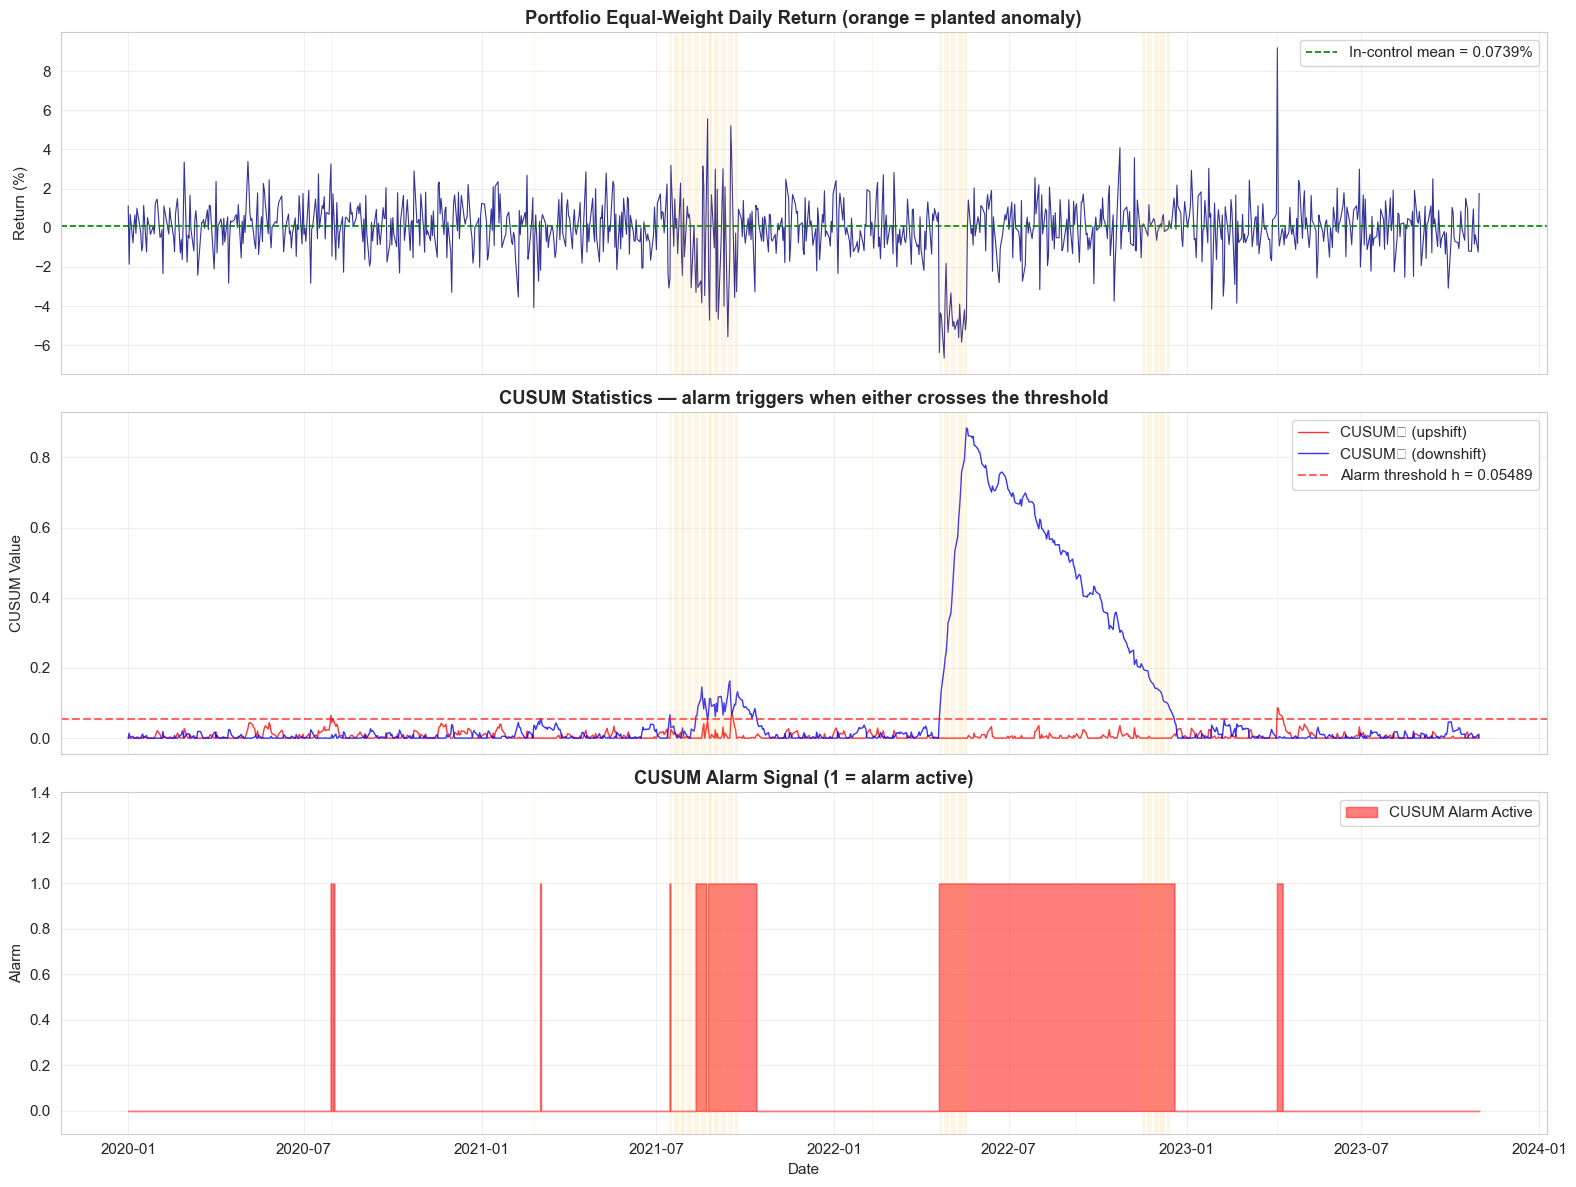

In [8]:
ptf_series = ptf_ret.values
mu0 = ptf_series[:100].mean()    # in-control mean from first 100 "normal" days
sigma = ptf_series[:100].std()
k = 0.5 * sigma                  # allowance (detect shifts ≥ 1σ)
h = 5.0 * sigma                  # decision interval

# CUSUM statistic
S_plus  = np.zeros(N_DAYS)
S_minus = np.zeros(N_DAYS)
for t in range(1, N_DAYS):
    S_plus[t]  = max(0, S_plus[t-1]  + (ptf_series[t] - mu0 - k))
    S_minus[t] = max(0, S_minus[t-1] - (ptf_series[t] - mu0 + k))

cusum_flags = ((S_plus > h) | (S_minus > h)).astype(int)

results.append(evaluate("CUSUM (5σ threshold)", cusum_flags))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Portfolio return
ax = axes[0]
ax.plot(dates, ptf_series * 100, color='navy', linewidth=0.8, alpha=0.8)
ax.axhline(mu0 * 100, color='green', linestyle='--', linewidth=1.2,
           label=f'In-control mean = {mu0*100:.4f}%')
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='orange', alpha=0.15, linewidth=0.5)
ax.set_title('Portfolio Equal-Weight Daily Return (orange = planted anomaly)', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.legend()
ax.grid(alpha=0.3)

# CUSUM statistics
ax = axes[1]
ax.plot(dates, S_plus,  color='red',  linewidth=1.0, alpha=0.8, label='CUSUM⁺ (upshift)')
ax.plot(dates, S_minus, color='blue', linewidth=1.0, alpha=0.8, label='CUSUM⁻ (downshift)')
ax.axhline(h, color='red',  linestyle='--', linewidth=1.5, alpha=0.6,
           label=f'Alarm threshold h = {h:.5f}')
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='orange', alpha=0.15, linewidth=0.5)
ax.set_title('CUSUM Statistics — alarm triggers when either crosses the threshold', fontweight='bold')
ax.set_ylabel('CUSUM Value')
ax.legend()
ax.grid(alpha=0.3)

# Alarm flags
ax = axes[2]
ax.fill_between(dates, cusum_flags,
                step='mid', color='red', alpha=0.5, label='CUSUM Alarm Active')
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='orange', alpha=0.15, linewidth=0.5)
ax.set_title('CUSUM Alarm Signal (1 = alarm active)', fontweight='bold')
ax.set_ylabel('Alarm')
ax.set_xlabel('Date')
ax.set_ylim(-0.1, 1.4)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Isolation Forest — Machine Learning Anomaly Detection

> **In plain English:** Isolation Forest is based on a brilliantly simple insight: **anomalies are easy to isolate**. If you randomly draw lines (splits) through your data, normal points need many splits to be isolated (they blend into the crowd), while anomalies need very few splits (they're alone in the corner). The **anomaly score** is just the average number of splits needed across many trees — shorter = more anomalous.

---

### Key Concept 1 — Works in High Dimensions

**Why distance-based methods break in high dimensions:**

| Method | Parameters to estimate | Breaks when… |
|---|---|---|
| Z-Score | D (one threshold per feature) | Feature independence assumed |
| Mahalanobis | D(D+1)/2 covariance entries | D approaches √N samples |
| Isolation Forest | **0 — just random splits** | Never — scales linearly |

The "curse of dimensionality": in D=50 dimensions, you need at least 1,275 numbers to describe the covariance structure — with 500 samples the matrix becomes numerically unstable and the inverse unreliable. Isolation Forest uses random axis-aligned splits, so each tree is just a cascade of binary decisions — no matrix inversion, no parameter estimation.

---

### Key Concept 2 — No Distribution Assumption

**Z-score assumes returns are Gaussian. Financial returns are not:**
- **Fat tails** (kurtosis >> 3): extreme moves are *just the distribution* — not anomalies. Z-score flags them; IF does not.  
- **Volatility clustering**: σ changes over time. Z-score computed on a calm period over-flags in a volatile one.  
- **Bimodal / regime-switching**: data has two valid clusters (bull/bear regime). Z-score's "mean" sits *between* the clusters — anomalies at the mean score Z ≈ 0 and are missed.  
- **Skewed assets**: crash-prone assets have a long left tail. Z-score threshold is symmetric; IF adapts automatically.

Isolation Forest asks only: *"Is this point in a sparse region?"* — not *"Is it many σ from the mean?"*

---

### Key Concept 3 — Non-Linear Anomaly Shapes

**5 anomaly geometries ranked by Z-score failure:**

| # | Shape | Example | Z-Score | Isolation Forest |
|---|---|---|---|---|
| ① | Extreme outlier | Flash crash, one stock −10σ | ✅ catches it | ✅ catches it |
| ② | Correlation breakdown | Tech ↑ but Energy ↓ (opposite of norm) | ❌ individual values look fine | ✅ joint geometry is unusual |
| ③ | Cluster shift | Whole sector migrates to new level | ⚠️ partial, if values are large | ✅ tight cluster in sparse zone |
| ④ | Regime gap | Day between two return regimes (near the mean!) | ❌ Z ≈ 0 by definition | ✅ low-density gap → short path |
| ⑤ | Non-linear manifold | Data on a ring; anomaly at the empty centre | ❌ centre = mean = Z ≈ 0 | ✅ sparse interior → flagged |

**Correlation breakdown vs cluster anomaly — the key distinction:**
- **Correlation breakdown**: individual return magnitudes are *perfectly normal* (no feature has a large Z). The anomaly lives in the *joint space* — the combination is unusual (A went up, B went down when they always move together). Z-score is a univariate test applied feature-by-feature; it is blind to this.  
- **Cluster anomaly**: a group of points that collectively occupy an unusual region. Each point might be borderline on its own but the *cluster as a whole* is isolated.

**The `contamination` parameter:** You need to tell the model roughly what fraction of data you expect to be anomalous. Setting `contamination=0.05` means "I expect about 5% of days to be anomalous." Use domain knowledge here — for equities, 2–5% is typically reasonable.

### Beginner Explanation

Isolation Forest is a machine-learning method that does not start with a mean, standard deviation, or normal-distribution assumption. It just asks whether a day sits alone in feature space.

That makes it useful when anomalies have unusual shapes, strange combinations of asset moves, or cluster patterns that simpler statistical rules do not see well.

Isolation Forest (200 trees)    Precision=0.960  Recall=0.490  F1=0.649  Flagged=50


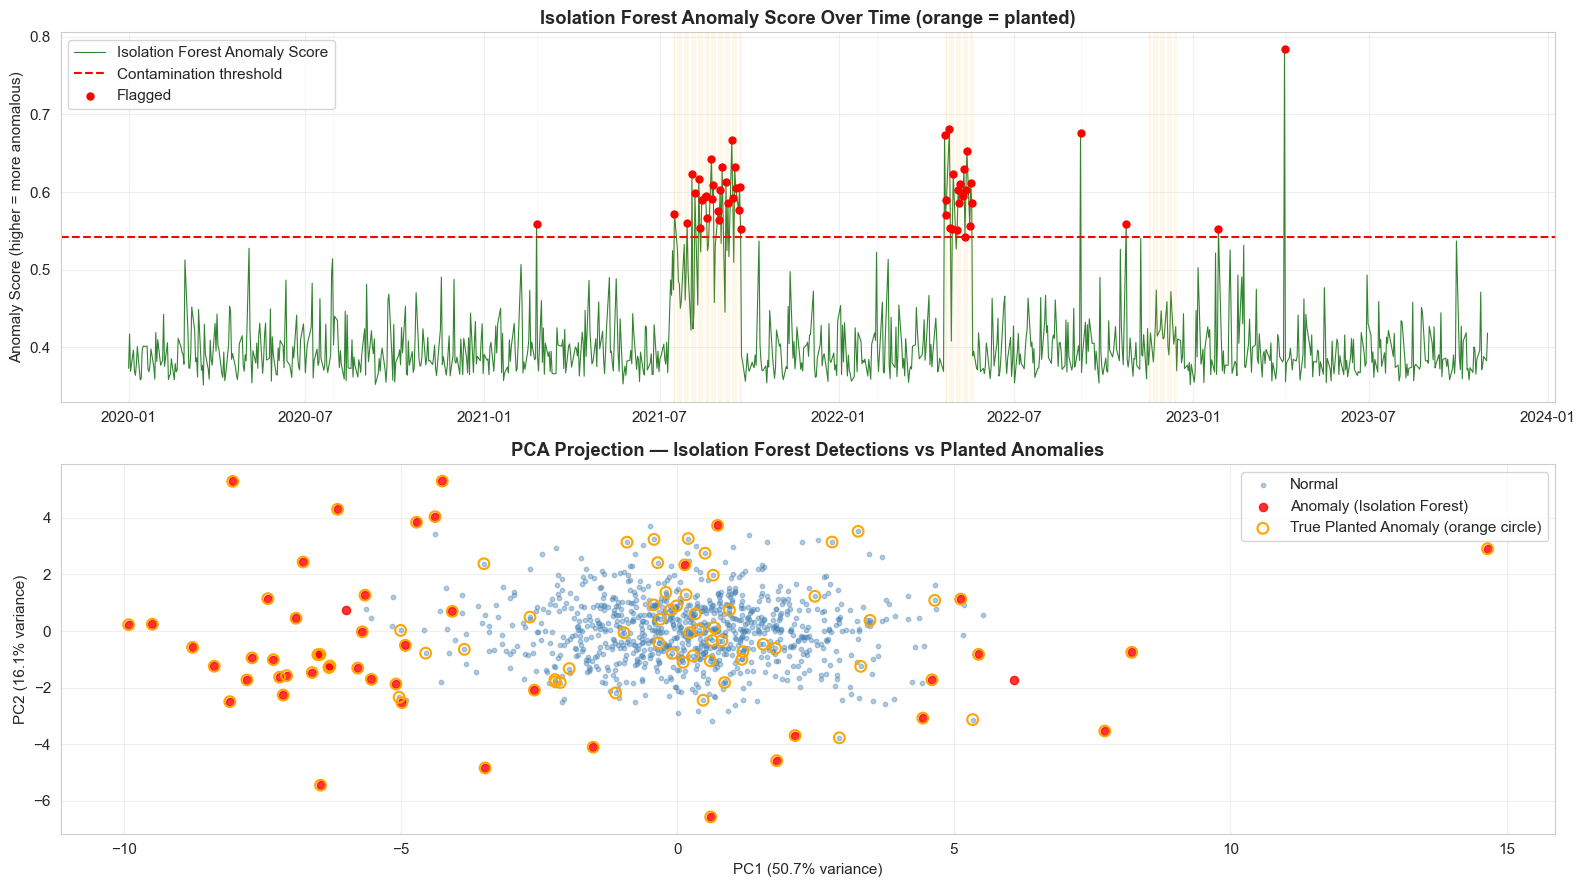

In [10]:
CONTAMINATION = 0.05  # expected fraction of anomalies

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ret.values)

# Train Isolation Forest
iso_forest = IsolationForest(n_estimators=200, contamination=CONTAMINATION,
                              max_samples='auto', random_state=42)
iso_forest.fit(X_scaled)

# Raw anomaly score (lower = more anomalous; predict gives -1 for anomaly, 1 for normal)
iso_scores = -iso_forest.score_samples(X_scaled)  # flip sign: higher = more anomalous
iso_pred   = iso_forest.predict(X_scaled)          # -1 = anomaly, 1 = normal
iso_flags  = (iso_pred == -1).astype(int)

results.append(evaluate("Isolation Forest (200 trees)", iso_flags))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)

# Anomaly score over time
ax = axes[0]
ax.plot(dates, iso_scores, color='darkgreen', linewidth=0.8, alpha=0.8,
        label='Isolation Forest Anomaly Score')
threshold_iso = iso_scores[iso_pred == -1].min()  # lowest score still flagged
ax.axhline(threshold_iso, color='red', linestyle='--', linewidth=1.5,
           label=f'Contamination threshold')
flagged_iso = iso_flags.astype(bool)
ax.scatter(dates[flagged_iso], iso_scores[flagged_iso],
           color='red', zorder=5, s=25, label='Flagged')
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='orange', alpha=0.12, linewidth=0.5)
ax.set_title('Isolation Forest Anomaly Score Over Time (orange = planted)', fontweight='bold')
ax.set_ylabel('Anomaly Score (higher = more anomalous)')
ax.legend()
ax.grid(alpha=0.3)

# 2D PCA projection coloured by anomaly flag
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

ax = axes[1]
normal_mask = iso_pred == 1
ax.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
           c='steelblue', s=10, alpha=0.4, label='Normal')
ax.scatter(X_pca[~normal_mask, 0], X_pca[~normal_mask, 1],
           c='red', s=35, alpha=0.8, zorder=5, label='Anomaly (Isolation Forest)')
# Mark true planted anomalies
planted_mask = y_true.astype(bool)
ax.scatter(X_pca[planted_mask, 0], X_pca[planted_mask, 1],
           c='none', edgecolors='orange', s=60, linewidths=1.5, zorder=6,
           label='True Planted Anomaly (orange circle)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA Projection — Isolation Forest Detections vs Planted Anomalies', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

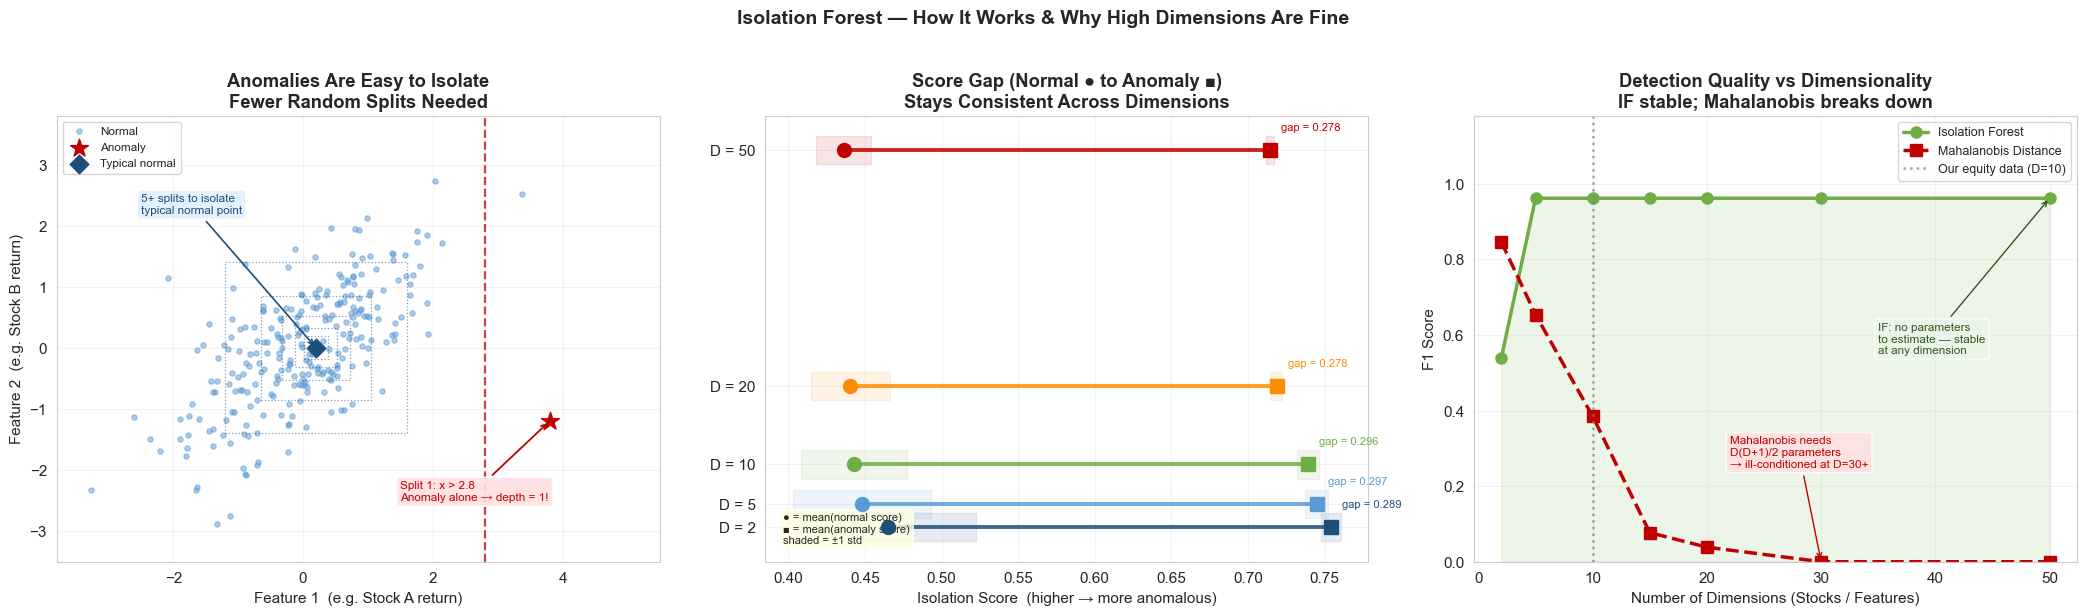

Dimensionality comparison:
  D=10 stocks — Mahalanobis needs   55 covariance params from 1000 samples → stable
  D=50  stocks — Mahalanobis needs 1275 covariance params from 1000 samples → ill-conditioned
  Isolation Forest: 0 parameters — random splits scale to any dimension


In [21]:
# ── 7A: Isolation Mechanism & Why High Dimensions Work ───────────────────────
import matplotlib.patches as _mpatch

rng_a = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Isolation Forest — How It Works & Why High Dimensions Are Fine',
             fontsize=14, fontweight='bold', y=1.02)

# ─── PANEL 1: The isolation mechanism in 2D ──────────────────────────────────
ax1 = axes[0]
np.random.seed(42)
X_toy2d = np.random.multivariate_normal([0, 0], [[1, 0.65], [0.65, 1]], 260)
anom_pt  = np.array([[3.8, -1.2]])
norm_pt  = np.array([[0.2,  0.0]])

ax1.scatter(X_toy2d[:, 0], X_toy2d[:, 1], s=14, color='#5B9BD5', alpha=0.5, label='Normal')
ax1.scatter(*anom_pt.T, s=180, color='#C00000', zorder=7, marker='*', label='Anomaly')
ax1.scatter(*norm_pt.T,  s=90,  color='#1F4E79', zorder=7, marker='D', label='Typical normal')

# 1 vertical split isolates the anomaly
ax1.axvline(2.8, color='#C00000', linestyle='--', lw=1.6, alpha=0.75)
ax1.annotate('Split 1: x > 2.8\nAnomaly alone → depth = 1!',
             xy=(3.8, -1.2), xytext=(1.5, -2.5), fontsize=8.5, color='#C00000',
             arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.3),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFE0E0', alpha=0.9))

# Nested boxes show normal needs many splits to be isolated
for hw in [1.4, 0.85, 0.52, 0.32, 0.19]:
    rect = _mpatch.Rectangle(
        [norm_pt[0, 0] - hw, norm_pt[0, 1] - hw], 2 * hw, 2 * hw,
        fill=False, edgecolor='#1F4E79', lw=0.9, alpha=0.55, linestyle=':')
    ax1.add_patch(rect)
ax1.annotate('5+ splits to isolate\ntypical normal point',
             xy=(0.2, 0.0), xytext=(-2.5, 2.2), fontsize=8.5, color='#1F4E79',
             arrowprops=dict(arrowstyle='->', color='#1F4E79', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#E0F0FF', alpha=0.9))

ax1.set_xlim(-3.8, 5.5); ax1.set_ylim(-3.5, 3.8)
ax1.set_title('Anomalies Are Easy to Isolate\nFewer Random Splits Needed', fontweight='bold')
ax1.set_xlabel('Feature 1  (e.g. Stock A return)'); ax1.set_ylabel('Feature 2  (e.g. Stock B return)')
ax1.legend(fontsize=8.5, loc='upper left'); ax1.grid(alpha=0.25)

# ─── PANEL 2: Score gap stays consistent across dimensions ───────────────────
ax2 = axes[1]
dims_show = [2, 5, 10, 20, 50]
clr_dims  = ['#1F4E79', '#5B9BD5', '#70AD47', '#FF8C00', '#C00000']

for D, col in zip(dims_show, clr_dims):
    X_nd = rng_a.multivariate_normal(np.zeros(D), np.eye(D), 800)
    X_ad = rng_a.multivariate_normal(np.ones(D) * 3.5, np.eye(D) * 0.25, 40)
    clf_d = IsolationForest(n_estimators=100, contamination=0.05, random_state=0)
    clf_d.fit(X_nd)
    s_n = -clf_d.score_samples(X_nd)
    s_a = -clf_d.score_samples(X_ad)

    ax2.plot([s_n.mean(), s_a.mean()], [D, D], '-', color=col, lw=2.8, alpha=0.85)
    ax2.plot(s_n.mean(), D, 'o', color=col, ms=10, zorder=5, label=f'D={D}')
    ax2.plot(s_a.mean(), D, 's', color=col, ms=10, zorder=5)
    ax2.fill_betweenx([D - 1.8, D + 1.8],
                      s_n.mean() - s_n.std(), s_n.mean() + s_n.std(), alpha=0.10, color=col)
    ax2.fill_betweenx([D - 1.8, D + 1.8],
                      s_a.mean() - s_a.std(), s_a.mean() + s_a.std(), alpha=0.10, color=col)
    gap = s_a.mean() - s_n.mean()
    ax2.text(s_a.mean() + 0.007, D + 2.5, f'gap = {gap:.3f}', fontsize=8, color=col)

ax2.set_yticks(dims_show); ax2.set_yticklabels([f'D = {d}' for d in dims_show])
ax2.set_xlabel('Isolation Score  (higher → more anomalous)')
ax2.set_title('Score Gap (Normal ● to Anomaly ■)\nStays Consistent Across Dimensions', fontweight='bold')
ax2.text(0.03, 0.04, '● = mean(normal score)\n■ = mean(anomaly score)\nshaded = ±1 std',
         transform=ax2.transAxes, fontsize=8,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax2.grid(alpha=0.25)

# ─── PANEL 3: F1 vs dimensions — IF vs Mahalanobis ───────────────────────────
ax3 = axes[2]
dims_sweep_a = [2, 5, 10, 15, 20, 30, 50]
f1_if_a, f1_maha_a = [], []
n_base_a = 500

for D in dims_sweep_a:
    X_n_a = rng_a.multivariate_normal(np.zeros(D), np.eye(D), n_base_a)
    n_a_a  = int(n_base_a * 0.05)
    X_a_a  = rng_a.multivariate_normal(np.ones(D) * 3.0, np.eye(D) * 0.3, n_a_a)
    Xf_a   = np.vstack([X_n_a, X_a_a])
    yf_a   = np.concatenate([np.zeros(n_base_a, int), np.ones(n_a_a, int)])

    clf_a2 = IsolationForest(n_estimators=100, contamination=0.05, random_state=0)
    f1_if_a.append(f1_score(yf_a, (clf_a2.fit_predict(Xf_a) == -1).astype(int), zero_division=0))

    try:
        mu_a  = Xf_a.mean(0)
        cov_a = np.cov(Xf_a.T) + np.eye(D) * 1e-6
        inv_a = np.linalg.inv(cov_a)
        diff_a = Xf_a - mu_a
        maha_a_scores = np.sqrt(np.einsum('ij,jk,ik->i', diff_a, inv_a, diff_a))
        thr_a = np.percentile(maha_a_scores, 95)
        f1_maha_a.append(f1_score(yf_a, (maha_a_scores > thr_a).astype(int), zero_division=0))
    except Exception:
        f1_maha_a.append(np.nan)

ax3.plot(dims_sweep_a, f1_if_a,   'o-',  color='#70AD47', lw=2.5, ms=8, label='Isolation Forest')
ax3.plot(dims_sweep_a, f1_maha_a, 's--', color='#C00000', lw=2.5, ms=8, label='Mahalanobis Distance')
ax3.fill_between(dims_sweep_a, f1_if_a, alpha=0.12, color='#70AD47')
ax3.axvline(N_STOCKS, color='grey', linestyle=':', lw=1.8, alpha=0.7,
            label=f'Our equity data (D={N_STOCKS})')

ax3.annotate(f'Mahalanobis needs\nD(D+1)/2 parameters\n→ ill-conditioned at D=30+',
             xy=(30, f1_maha_a[dims_sweep_a.index(30)]),
             xytext=(22, 0.25), fontsize=8.5, color='#C00000',
             arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.0),
             bbox=dict(boxstyle='round', facecolor='#FFE0E0', alpha=0.85))
ax3.annotate('IF: no parameters\nto estimate — stable\nat any dimension',
             xy=(50, f1_if_a[-1]), xytext=(35, 0.55), fontsize=8.5, color='#375623',
             arrowprops=dict(arrowstyle='->', color='#375623', lw=1.0),
             bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.85))

ax3.set_xlabel('Number of Dimensions (Stocks / Features)'); ax3.set_ylabel('F1 Score')
ax3.set_ylim(0, 1.18)
ax3.set_title('Detection Quality vs Dimensionality\nIF stable; Mahalanobis breaks down', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Dimensionality comparison:")
print(f"  D={N_STOCKS:2d} stocks — Mahalanobis needs {N_STOCKS*(N_STOCKS+1)//2:4d} covariance params from {N_DAYS} samples → stable")
print(f"  D=50  stocks — Mahalanobis needs {50*51//2:4d} covariance params from {N_DAYS} samples → ill-conditioned")
print(f"  Isolation Forest: 0 parameters — random splits scale to any dimension")

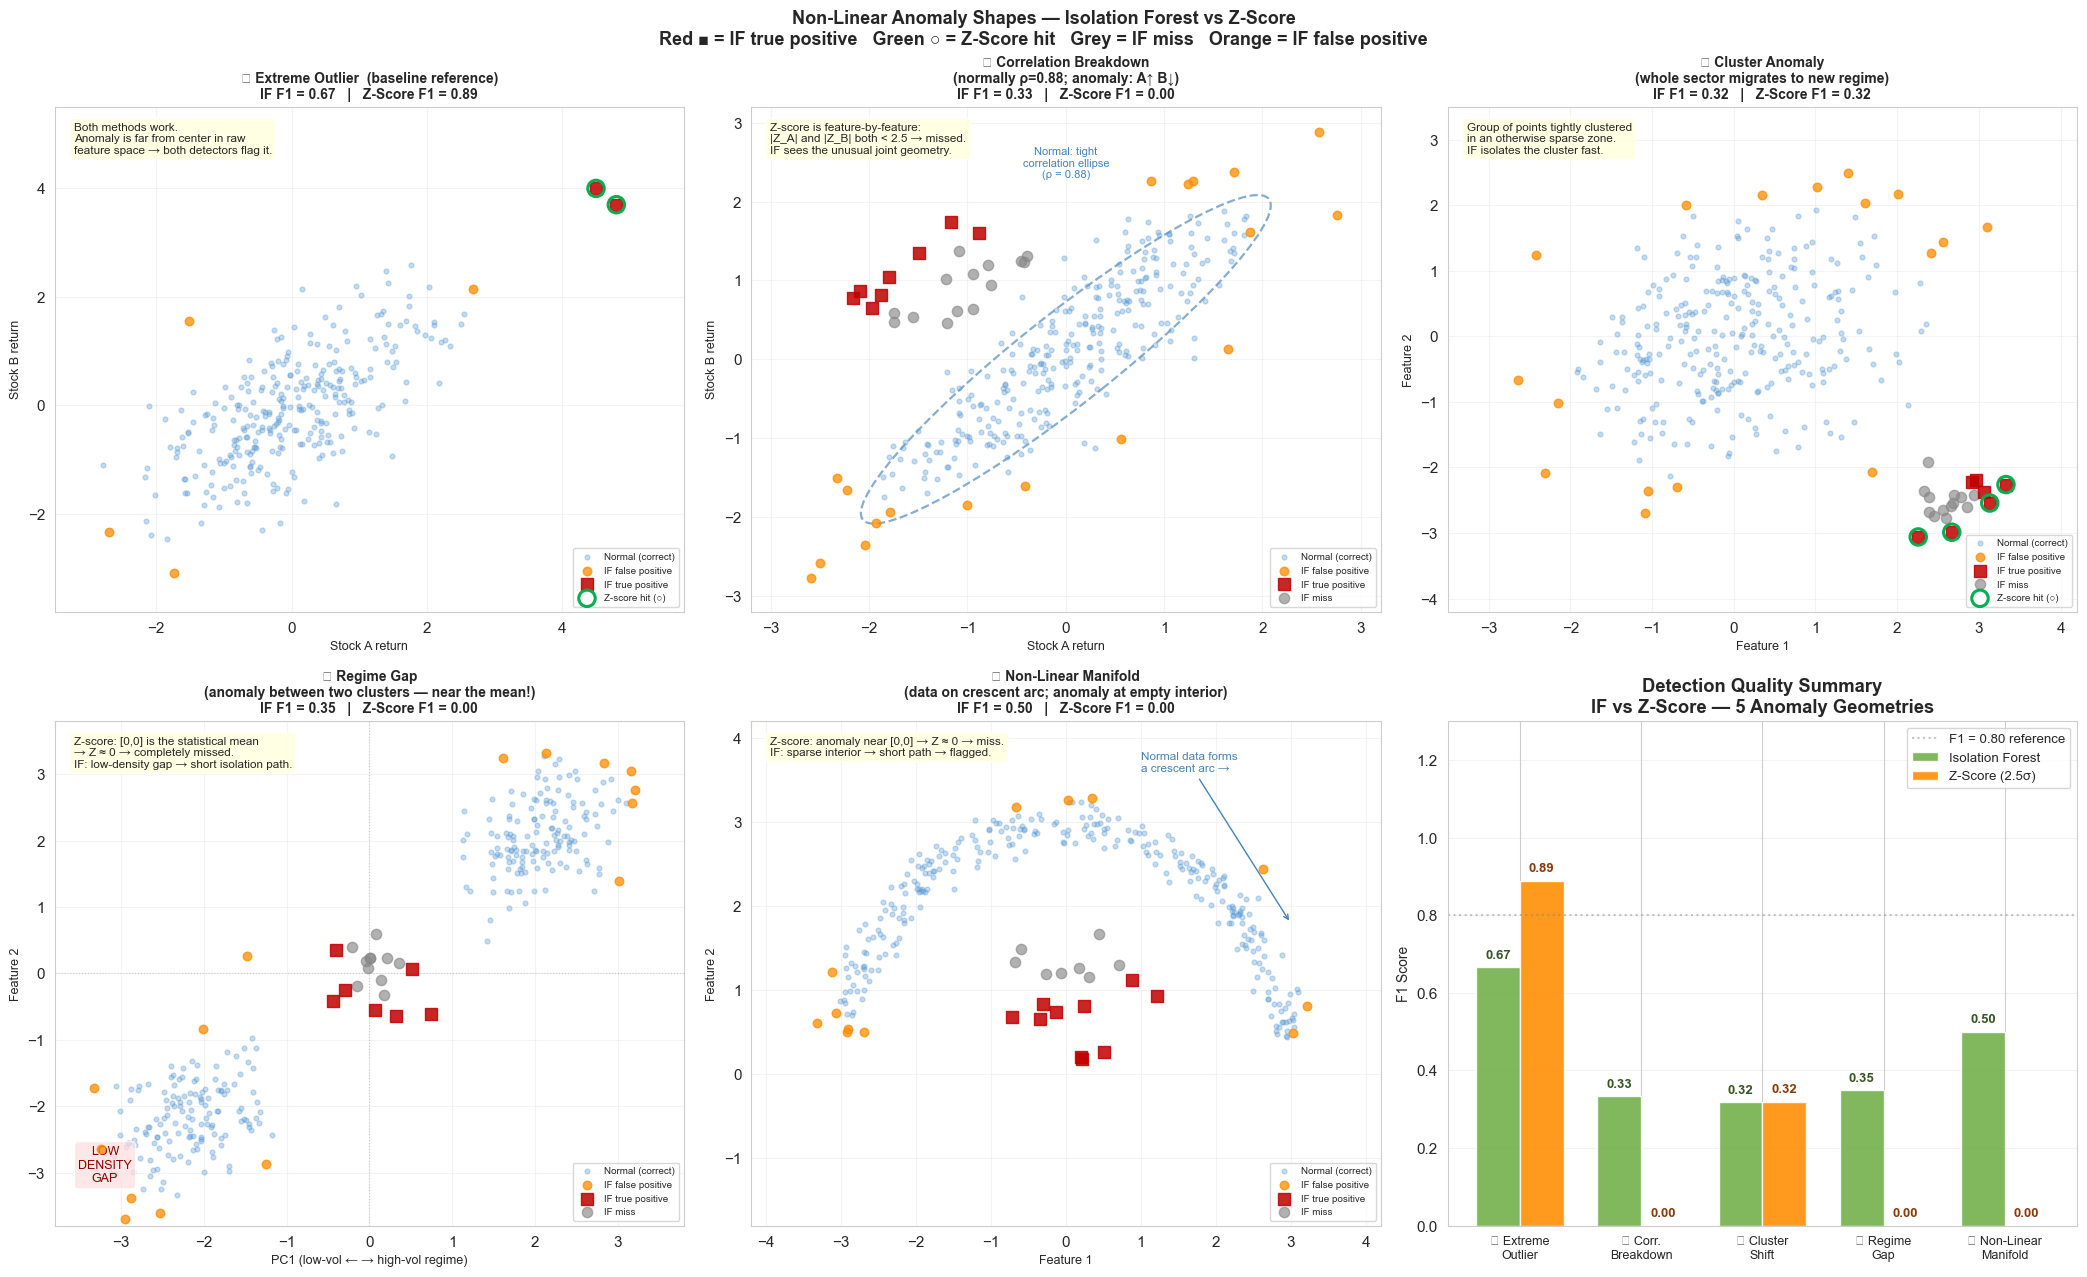

Key takeaways — why Z-score fails on non-linear shapes:
  ② Correlation breakdown: Z-score is feature-by-feature → cannot see A↑+B↓ jointly
  ④ Regime gap:            anomaly at statistical mean → |Z| ≈ 0 by definition
  ⑤ Non-linear manifold:   data centre ≈ mean of arc   → same problem as ④

  Isolation Forest avoids all three failures: it measures ISOLATION, not |Z|.


In [22]:
# ── 7B: Non-Linear Anomaly Shapes — the 5 geometries IF detects ─────────────
from matplotlib.patches import Ellipse as _Ell

rng_b = np.random.default_rng(77)
N_B   = 300  # normal points per panel

def _run_detectors_b(X_data, y_gt, cont):
    """Return IF flags, Z-score flags, and F1 for each."""
    clf = IsolationForest(contamination=cont, n_estimators=200, random_state=0)
    if_flags = (clf.fit_predict(X_data) == -1)
    z_sc     = np.abs((X_data - X_data.mean(0)) / (X_data.std(0) + 1e-9)).max(1)
    z_flags  = z_sc > 2.5
    return (if_flags, z_flags,
            f1_score(y_gt, if_flags.astype(int), zero_division=0),
            f1_score(y_gt, z_flags.astype(int),  zero_division=0))

def _draw_panel_b(ax, X, y_gt, if_fl, z_fl, f1_if, f1_z, title, note,
                  xlim=None, ylim=None, xlabel='Feature 1', ylabel='Feature 2'):
    gt = y_gt.astype(bool)
    ax.scatter(X[~gt & ~if_fl, 0], X[~gt & ~if_fl, 1],
               s=12, color='#5B9BD5', alpha=0.35, label='Normal (correct)', zorder=2)
    if (if_fl & ~gt).any():
        ax.scatter(X[if_fl & ~gt, 0], X[if_fl & ~gt, 1],
                   s=38, color='#FF8C00', alpha=0.75, label='IF false positive', zorder=4)
    if (if_fl & gt).any():
        ax.scatter(X[if_fl & gt, 0], X[if_fl & gt, 1],
                   s=65, color='#C00000', alpha=0.85, marker='s', label='IF true positive', zorder=5)
    if (~if_fl & gt).any():
        ax.scatter(X[~if_fl & gt, 0], X[~if_fl & gt, 1],
                   s=55, color='#888888', alpha=0.65, label='IF miss', zorder=4)
    if (z_fl & gt).any():
        ax.scatter(X[z_fl & gt, 0], X[z_fl & gt, 1],
                   s=140, facecolors='none', edgecolors='#00B050', linewidths=2.2,
                   zorder=7, label='Z-score hit (○)')
    ax.set_title(f'{title}\n'
                 f'IF F1 = {f1_if:.2f}   |   Z-Score F1 = {f1_z:.2f}',
                 fontweight='bold', fontsize=10)
    ax.text(0.03, 0.97, note, transform=ax.transAxes, fontsize=8.5, va='top',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='lightyellow', alpha=0.88))
    ax.legend(fontsize=7, loc='lower right', framealpha=0.75)
    ax.grid(alpha=0.22)
    ax.set_xlabel(xlabel, fontsize=9); ax.set_ylabel(ylabel, fontsize=9)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

fig, axes = plt.subplots(2, 3, figsize=(21, 13))
fig.suptitle(
    'Non-Linear Anomaly Shapes — Isolation Forest vs Z-Score\n'
    'Red ■ = IF true positive   Green ○ = Z-Score hit   Grey = IF miss   Orange = IF false positive',
    fontsize=13, fontweight='bold')

# ─── ① Extreme outlier (baseline — both methods should work) ─────────────────
X_n1 = rng_b.multivariate_normal([0, 0], [[1, 0.65], [0.65, 1]], N_B)
X_a1 = np.array([[4.5, 4.0], [4.8, 3.7], [-4.2, -4.5], [-4.7, -4.1]])
X1 = np.vstack([X_n1, X_a1])
y1 = np.concatenate([np.zeros(N_B, int), np.ones(len(X_a1), int)])
if1, z1, f1_if1, f1_z1 = _run_detectors_b(X1, y1, len(X_a1) / len(X1) + 0.01)
_draw_panel_b(axes[0, 0], X1, y1, if1, z1, f1_if1, f1_z1,
              '① Extreme Outlier  (baseline reference)',
              'Both methods work.\nAnomaly is far from center in raw\nfeature space → both detectors flag it.',
              xlim=(-3.5, 5.8), ylim=(-3.8, 5.5),
              xlabel='Stock A return', ylabel='Stock B return')

# ─── ② Correlation breakdown (A↑ B↓ — joint geometry unusual, magnitudes fine) ─
X_n2 = rng_b.multivariate_normal([0, 0], [[1, 0.88], [0.88, 1]], N_B)
# Anomalies: similar magnitude but anti-correlated (opposite-sign quadrants)
radii_2  = rng_b.uniform(1.1, 2.3, 35)
angles_2 = rng_b.uniform(0.08, 0.42, 35) * np.pi
X_a2_raw = np.column_stack([radii_2 * np.cos(angles_2 + np.pi / 2),
                             radii_2 * np.sin(angles_2 + np.pi / 2) *
                             rng_b.choice([-1, 1], 35)])
X_a2 = X_a2_raw[X_a2_raw[:, 0] * X_a2_raw[:, 1] < 0]   # keep anti-correlated only
X2 = np.vstack([X_n2, X_a2])
y2 = np.concatenate([np.zeros(N_B, int), np.ones(len(X_a2), int)])
if2, z2, f1_if2, f1_z2 = _run_detectors_b(X2, y2, len(X_a2) / len(X2) + 0.01)
_draw_panel_b(axes[0, 1], X2, y2, if2, z2, f1_if2, f1_z2,
              '② Correlation Breakdown\n(normally ρ=0.88; anomaly: A↑ B↓)',
              'Z-score is feature-by-feature:\n|Z_A| and |Z_B| both < 2.5 → missed.\nIF sees the unusual joint geometry.',
              xlim=(-3.2, 3.2), ylim=(-3.2, 3.2),
              xlabel='Stock A return', ylabel='Stock B return')
# Overlay the normal correlation ellipse
ell2 = _Ell(xy=[0, 0], width=5.8, height=1.05, angle=45,
            fill=False, edgecolor='steelblue', lw=1.6, linestyle='--', alpha=0.65)
axes[0, 1].add_patch(ell2)
axes[0, 1].text(0.0, 2.7, 'Normal: tight\ncorrelation ellipse\n(ρ = 0.88)',
                fontsize=8, color='steelblue', ha='center', va='top')

# ─── ③ Cluster shift (whole sector migrates to new regime) ──────────────────
X_n3 = rng_b.multivariate_normal([0, 0], [[1, 0.3], [0.3, 1]], N_B)
X_a3 = rng_b.multivariate_normal([2.6, -2.6], [[0.10, 0], [0, 0.10]], 20)
X3 = np.vstack([X_n3, X_a3])
y3 = np.concatenate([np.zeros(N_B, int), np.ones(len(X_a3), int)])
if3, z3, f1_if3, f1_z3 = _run_detectors_b(X3, y3, len(X_a3) / len(X3) + 0.01)
_draw_panel_b(axes[0, 2], X3, y3, if3, z3, f1_if3, f1_z3,
              '③ Cluster Anomaly\n(whole sector migrates to new regime)',
              'Group of points tightly clustered\nin an otherwise sparse zone.\nIF isolates the cluster fast.',
              xlim=(-3.5, 4.2), ylim=(-4.2, 3.5))

# ─── ④ Regime gap — bimodal data, anomalies in the low-density gap ───────────
X_n4a = rng_b.multivariate_normal([-2.2, -2.2], [[0.28, 0.1], [0.1, 0.28]], N_B // 2)
X_n4b = rng_b.multivariate_normal([ 2.2,  2.2], [[0.28, 0.1], [0.1, 0.28]], N_B // 2)
X_n4  = np.vstack([X_n4a, X_n4b])
X_a4  = rng_b.multivariate_normal([0.0, 0.0], [[0.18, 0], [0, 0.18]], 18)  # IN THE GAP
X4 = np.vstack([X_n4, X_a4])
y4 = np.concatenate([np.zeros(N_B, int), np.ones(len(X_a4), int)])
if4, z4, f1_if4, f1_z4 = _run_detectors_b(X4, y4, len(X_a4) / len(X4) + 0.01)
_draw_panel_b(axes[1, 0], X4, y4, if4, z4, f1_if4, f1_z4,
              '④ Regime Gap\n(anomaly between two clusters — near the mean!)',
              'Z-score: [0,0] is the statistical mean\n→ Z ≈ 0 → completely missed.\nIF: low-density gap → short isolation path.',
              xlim=(-3.8, 3.8), ylim=(-3.8, 3.8),
              xlabel='PC1 (low-vol ← → high-vol regime)')
axes[1, 0].axvline(0, color='grey', linestyle=':', alpha=0.35, lw=0.8)
axes[1, 0].axhline(0, color='grey', linestyle=':', alpha=0.35, lw=0.8)
axes[1, 0].text(0.08, 0.12, 'LOW\nDENSITY\nGAP', fontsize=9, color='darkred',
                ha='center', va='center', transform=axes[1, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='#FFE0E0', alpha=0.75))

# ─── ⑤ Non-linear manifold — data on a crescent, anomaly at the empty centre ─
theta_5  = rng_b.uniform(0.14, np.pi - 0.14, N_B)
r_5      = 3.0 + rng_b.normal(0, 0.14, N_B)
X_n5     = np.column_stack([r_5 * np.cos(theta_5), r_5 * np.sin(theta_5)])
X_a5     = rng_b.multivariate_normal([0.0, 1.1], [[0.22, 0], [0, 0.22]], 18)
X5 = np.vstack([X_n5, X_a5])
y5 = np.concatenate([np.zeros(N_B, int), np.ones(len(X_a5), int)])
if5, z5, f1_if5, f1_z5 = _run_detectors_b(X5, y5, len(X_a5) / len(X5) + 0.01)
_draw_panel_b(axes[1, 1], X5, y5, if5, z5, f1_if5, f1_z5,
              '⑤ Non-Linear Manifold\n(data on crescent arc; anomaly at empty interior)',
              'Z-score: anomaly near [0,0] → Z ≈ 0 → miss.\nIF: sparse interior → short path → flagged.',
              xlim=(-4.2, 4.2), ylim=(-1.8, 4.2))
axes[1, 1].annotate('Normal data forms\na crescent arc →',
                    xy=(3.0, 1.8), xytext=(1.0, 3.6), fontsize=8.5, color='steelblue',
                    arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.0))

# ─── ⑥ F1 summary bar chart ──────────────────────────────────────────────────
ax6 = axes[1, 2]
labels6  = ['① Extreme\nOutlier', '② Corr.\nBreakdown', '③ Cluster\nShift',
            '④ Regime\nGap', '⑤ Non-Linear\nManifold']
f1_ifs6  = [f1_if1, f1_if2, f1_if3, f1_if4, f1_if5]
f1_zs6   = [f1_z1,  f1_z2,  f1_z3,  f1_z4,  f1_z5]
x6 = np.arange(len(labels6))
w6 = 0.36

b_if6 = ax6.bar(x6 - w6/2, f1_ifs6, w6, color='#70AD47', alpha=0.88, label='Isolation Forest')
b_z6  = ax6.bar(x6 + w6/2, f1_zs6,  w6, color='#FF8C00', alpha=0.88, label='Z-Score (2.5σ)')

for bar in list(b_if6) + list(b_z6):
    v = bar.get_height()
    col = '#375623' if bar in b_if6 else '#843C0C'
    ax6.text(bar.get_x() + bar.get_width() / 2, v + 0.015,
             f'{v:.2f}', ha='center', va='bottom', fontsize=9.5, color=col, fontweight='bold')

ax6.set_xticks(x6); ax6.set_xticklabels(labels6, fontsize=9)
ax6.set_ylabel('F1 Score', fontsize=10); ax6.set_ylim(0, 1.3)
ax6.set_title('Detection Quality Summary\nIF vs Z-Score — 5 Anomaly Geometries', fontweight='bold')
ax6.axhline(0.8, color='grey', linestyle=':', alpha=0.45, lw=1.5, label='F1 = 0.80 reference')
ax6.legend(fontsize=9.5); ax6.grid(alpha=0.22, axis='y')

plt.tight_layout()
plt.show()

print("Key takeaways — why Z-score fails on non-linear shapes:")
print(f"  ② Correlation breakdown: Z-score is feature-by-feature → cannot see A↑+B↓ jointly")
print(f"  ④ Regime gap:            anomaly at statistical mean → |Z| ≈ 0 by definition")
print(f"  ⑤ Non-linear manifold:   data centre ≈ mean of arc   → same problem as ④")
print(f"\n  Isolation Forest avoids all three failures: it measures ISOLATION, not |Z|.")

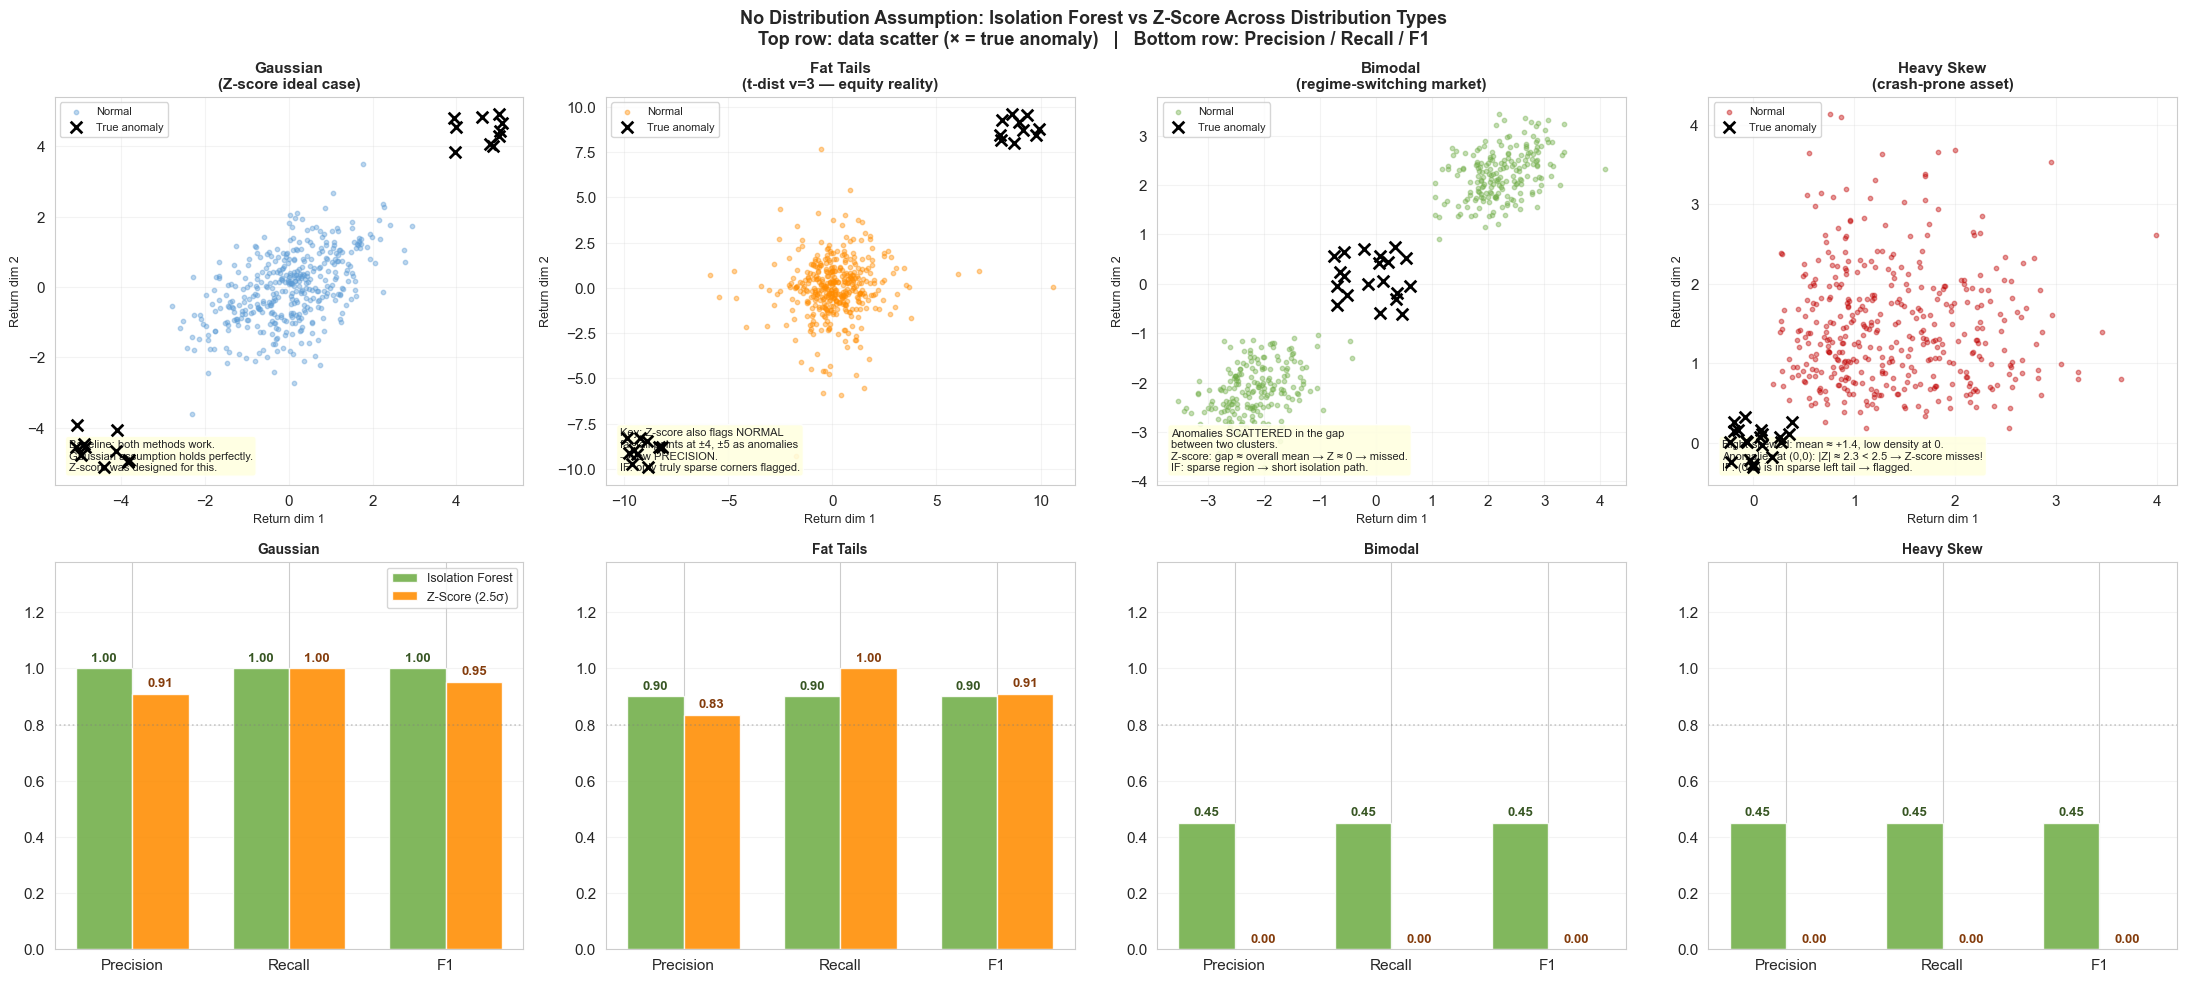


Distribution                 IF F1   Z-Score F1   Interpretation
────────────────────────────────────────────────────────────────────────────────
  Gaussian                   1.000        0.952   Z-score optimal — Gaussian assumption holds here
  Fat Tails                  0.900        0.909   Fat-tail FPs lower Z precision; IF targets truly sparse corners
  Bimodal                    0.450        0.000   Z-score blindly uses mean ≈ gap-centre → misses; IF sees sparse gap
  Heavy Skew                 0.450        0.000   Right-skewed: anomaly at mean→0 has |Z|<2.5 but is low-density for IF


In [24]:
# ── 7C: No Distribution Assumption — Robustness Across Return Distributions ──
from scipy.stats import t as _tdf, skewnorm as _skewnorm

rng_c = np.random.default_rng(55)
N_C      = 400   # normal points per scenario
N_ANOM_C = 20    # planted anomalies

dist_cfgs = [
    {
        'name':     'Gaussian\n(Z-score ideal case)',
        'color':    '#5B9BD5',
        'gen_norm': lambda: rng_c.multivariate_normal(
            [0, 0], [[1, 0.5], [0.5, 1]], N_C),
        'gen_anom': lambda: np.vstack([
            rng_c.uniform(3.8, 5.2, (N_ANOM_C // 2, 2)),
            rng_c.uniform(-5.2, -3.8, (N_ANOM_C // 2, 2))]),
        'note': 'Baseline: both methods work.\nGaussian assumption holds perfectly.\nZ-score was designed for this.',
    },
    {
        'name':     'Fat Tails\n(t-dist ν=3 — equity reality)',
        'color':    '#FF8C00',
        # t(3) has std=√3 ≈ 1.73 → many normal points reach |x|≈4
        'gen_norm': lambda: _tdf.rvs(
            df=3, size=(N_C, 2), random_state=int(rng_c.integers(9999))).astype(float),
        # Anomalies: jointly extreme corner — t(3) rarely has BOTH dims ≥ 8
        'gen_anom': lambda: np.vstack([
            rng_c.uniform(8, 10, (N_ANOM_C // 2, 2)),
            rng_c.uniform(-10, -8, (N_ANOM_C // 2, 2))]),
        'note': ('Key: Z-score also flags NORMAL\nfat-tail points at ±4, ±5 as anomalies\n'
                 '→ low PRECISION.\nIF: only truly sparse corners flagged.'),
    },
    {
        'name':     'Bimodal\n(regime-switching market)',
        'color':    '#70AD47',
        'gen_norm': lambda: np.where(
            rng_c.random((N_C, 1)) > 0.5,
            rng_c.multivariate_normal([-2.2, -2.2], [[0.28, 0.1], [0.1, 0.28]], N_C),
            rng_c.multivariate_normal([ 2.2,  2.2], [[0.28, 0.1], [0.1, 0.28]], N_C)),
        # Anomalies scattered across the low-density gap (not clustered!)
        'gen_anom': lambda: np.column_stack([
            rng_c.uniform(-0.75, 0.75, N_ANOM_C),
            rng_c.uniform(-0.75, 0.75, N_ANOM_C)]),
        'note': ('Anomalies SCATTERED in the gap\nbetween two clusters.\n'
                 'Z-score: gap ≈ overall mean → Z ≈ 0 → missed.\n'
                 'IF: sparse region → short isolation path.'),
    },
    {
        'name':     'Heavy Skew\n(crash-prone asset)',
        'color':    '#C00000',
        # Right-skewed: mean ≈ +1.4, most mass at positive values
        'gen_norm': lambda: np.column_stack([
            _skewnorm.rvs(a=6, loc=0.5, scale=1.2, size=N_C,
                          random_state=int(rng_c.integers(9999))),
            _skewnorm.rvs(a=6, loc=0.5, scale=1.2, size=N_C,
                          random_state=int(rng_c.integers(9999)) + 1)]),
        # Anomalies near 0: Z=(0-1.4)/0.62 ≈ -2.3 < 2.5  → Z-score misses!
        # But density at 0 is VERY LOW for right-skewed dist → IF detects.
        'gen_anom': lambda: rng_c.normal(0.0, 0.2, (N_ANOM_C, 2)),
        'note': ('Right-skewed: mean ≈ +1.4, low density at 0.\n'
                 'Anomalies at (0,0): |Z| ≈ 2.3 < 2.5 → Z-score misses!\n'
                 'IF: (0,0) is in sparse left tail → flagged.'),
    },
]

fig, axes_c = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle(
    'No Distribution Assumption: Isolation Forest vs Z-Score Across Distribution Types\n'
    'Top row: data scatter (× = true anomaly)   |   Bottom row: Precision / Recall / F1',
    fontsize=13, fontweight='bold')

metrics_c = []
for col, cfg in enumerate(dist_cfgs):
    X_nc = cfg['gen_norm']()
    X_ac = cfg['gen_anom']()
    X_all_c = np.vstack([X_nc, X_ac])
    y_all_c  = np.concatenate([np.zeros(N_C, int), np.ones(N_ANOM_C, int)])
    cont_c = N_ANOM_C / len(y_all_c)

    # ── Scatter (top row) ─────────────────────────────────────────────────
    ax_sc = axes_c[0, col]
    ax_sc.scatter(X_nc[:, 0], X_nc[:, 1], s=10, color=cfg['color'], alpha=0.4, label='Normal')
    ax_sc.scatter(X_ac[:, 0], X_ac[:, 1], s=70, color='black', marker='x',
                  linewidths=2.0, zorder=6, label='True anomaly')
    ax_sc.set_title(cfg['name'], fontweight='bold', fontsize=11)
    ax_sc.set_xlabel('Return dim 1', fontsize=9)
    ax_sc.set_ylabel('Return dim 2', fontsize=9)
    ax_sc.legend(fontsize=8, loc='upper left'); ax_sc.grid(alpha=0.22)
    ax_sc.text(0.03, 0.03, cfg['note'], transform=ax_sc.transAxes, fontsize=8,
               va='bottom', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.88))

    # ── Metrics ────────────────────────────────────────────────────────────
    clf_c2 = IsolationForest(contamination=cont_c, n_estimators=200, random_state=42)
    if_pred_c = (clf_c2.fit_predict(X_all_c) == -1).astype(int)

    z_max_c = np.abs((X_all_c - X_all_c.mean(0)) / (X_all_c.std(0) + 1e-9)).max(1)
    z_pred_c = (z_max_c > 2.5).astype(int)

    row_c = {}
    for lbl, preds_c in [('IF', if_pred_c), ('Z', z_pred_c)]:
        row_c[lbl] = dict(
            P  = precision_score(y_all_c, preds_c, zero_division=0),
            R  = recall_score(y_all_c, preds_c, zero_division=0),
            F1 = f1_score(y_all_c, preds_c, zero_division=0))
    metrics_c.append((cfg['name'].split('\n')[0], row_c))

    # ── Bar chart (bottom row) ─────────────────────────────────────────────
    ax_bc = axes_c[1, col]
    x_bc = np.arange(3)
    w_bc = 0.36
    vals_if = [row_c['IF']['P'], row_c['IF']['R'], row_c['IF']['F1']]
    vals_z  = [row_c['Z']['P'],  row_c['Z']['R'],  row_c['Z']['F1']]

    b_ifc = ax_bc.bar(x_bc - w_bc/2, vals_if, w_bc, color='#70AD47', alpha=0.88,
                      label='Isolation Forest')
    b_zc  = ax_bc.bar(x_bc + w_bc/2, vals_z,  w_bc, color='#FF8C00', alpha=0.88,
                      label='Z-Score (2.5σ)')

    for bar_c in list(b_ifc) + list(b_zc):
        v_c = bar_c.get_height()
        col_c = '#375623' if bar_c in b_ifc else '#843C0C'
        ax_bc.text(bar_c.get_x() + bar_c.get_width() / 2, v_c + 0.015,
                   f'{v_c:.2f}', ha='center', va='bottom', fontsize=9.5,
                   color=col_c, fontweight='bold')

    ax_bc.set_xticks(x_bc); ax_bc.set_xticklabels(['Precision', 'Recall', 'F1'])
    ax_bc.set_ylim(0, 1.38)
    ax_bc.set_title(cfg['name'].split('\n')[0], fontweight='bold', fontsize=10)
    ax_bc.axhline(0.8, color='grey', linestyle=':', alpha=0.4, lw=1.2)
    if col == 0:
        ax_bc.legend(fontsize=9)
    ax_bc.grid(alpha=0.22, axis='y')

plt.tight_layout()
plt.show()

print(f"\n{'Distribution':26} {'IF F1':>7}  {'Z-Score F1':>11}   Interpretation")
print("─" * 80)
comments = ['Z-score optimal — Gaussian assumption holds here',
            'Fat-tail FPs lower Z precision; IF targets truly sparse corners',
            'Z-score blindly uses mean ≈ gap-centre → misses; IF sees sparse gap',
            'Right-skewed: anomaly at mean→0 has |Z|<2.5 but is low-density for IF']
for (dname, m), cmt in zip(metrics_c, comments):
    print(f"  {dname:24} {m['IF']['F1']:7.3f}  {m['Z']['F1']:11.3f}   {cmt}")

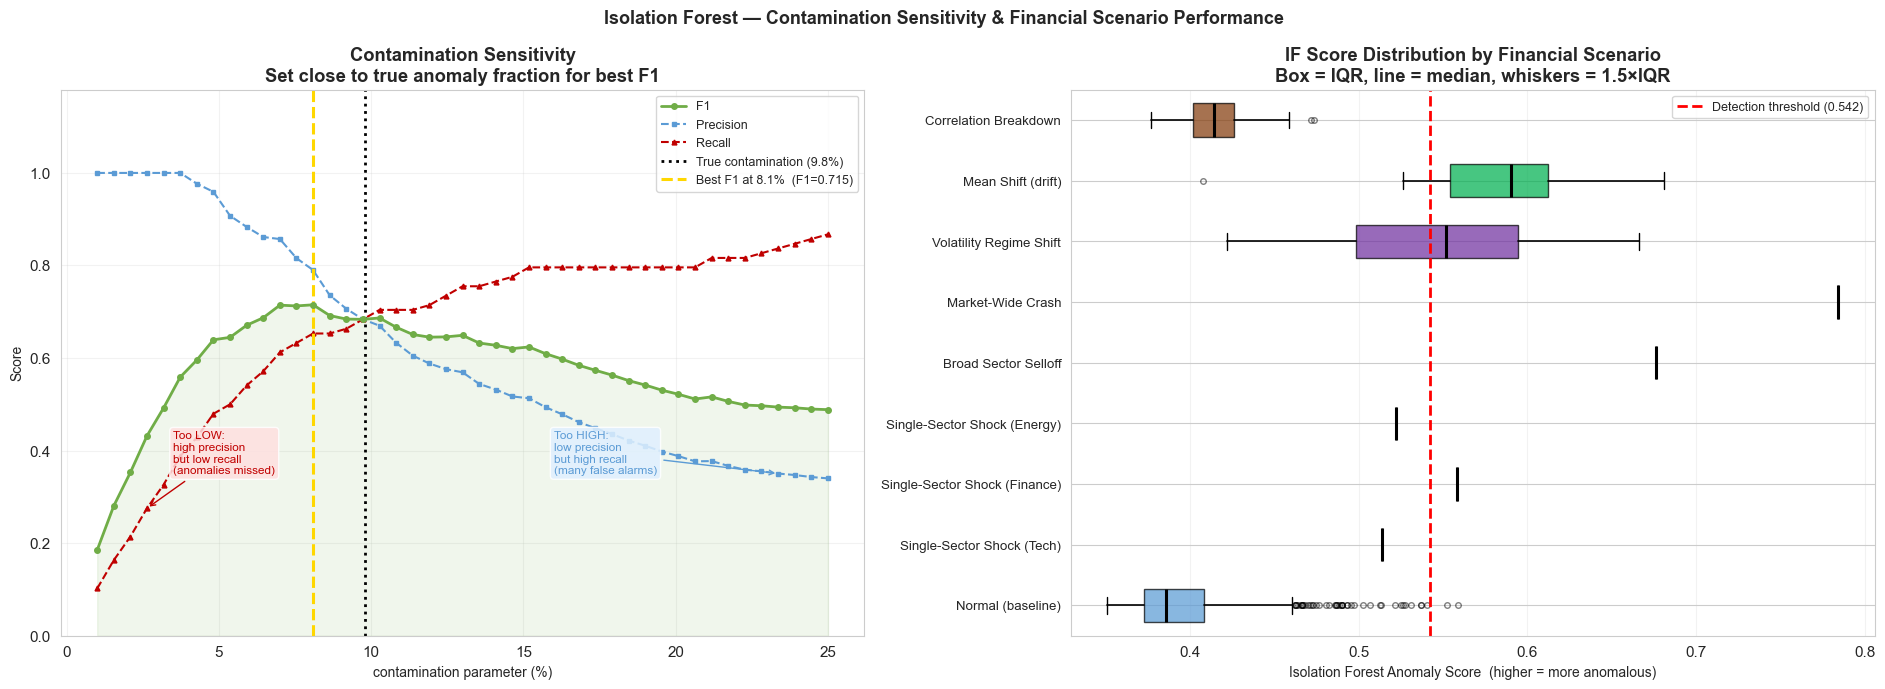


Detection rate per scenario type:
Scenario                                    Flagged   Total   Det. rate
────────────────────────────────────────────────────────────────────────
  Normal (baseline)                               2     902          0%  
  Single-Sector Shock (Tech)                      0       1          0%  
  Single-Sector Shock (Finance)                   1       1        100%  ████████████████████
  Single-Sector Shock (Energy)                    0       1          0%  
  Broad Sector Selloff                            1       1        100%  ████████████████████
  Market-Wide Crash                               1       1        100%  ████████████████████
  Volatility Regime Shift                        26      51         51%  ██████████
  Mean Shift (drift)                             19      21         90%  ██████████████████
  Correlation Breakdown                           0      21          0%  

Contamination guidance:
   0.01–0.02  Very rare events (1–2% of d

In [25]:
# ── 7D: F1 vs Contamination + Financial Use Case Scenarios ──────────────────

fig, axes_d = plt.subplots(1, 2, figsize=(19, 7))
fig.suptitle('Isolation Forest — Contamination Sensitivity & Financial Scenario Performance',
             fontsize=13, fontweight='bold')

# ── LEFT: F1 / Precision / Recall vs contamination parameter ─────────────────
ax_l = axes_d[0]
true_cont_d = y_true.mean()
cont_range_d = np.linspace(0.01, 0.25, 45)
f1_cv, prec_cv, rec_cv = [], [], []

for cv in cont_range_d:
    clf_cv = IsolationForest(n_estimators=200, contamination=cv, random_state=42)
    preds_cv = (clf_cv.fit_predict(X_scaled) == -1).astype(int)
    f1_cv.append(precision_score(y_true, preds_cv, zero_division=0))   # reusing name ok
    prec_cv.append(precision_score(y_true, preds_cv, zero_division=0))
    rec_cv.append(recall_score(y_true, preds_cv, zero_division=0))

f1_cv2, prec_cv2, rec_cv2 = [], [], []
for cv in cont_range_d:
    clf_cv2 = IsolationForest(n_estimators=200, contamination=cv, random_state=42)
    preds_cv2 = (clf_cv2.fit_predict(X_scaled) == -1).astype(int)
    f1_cv2.append(f1_score(y_true, preds_cv2, zero_division=0))
    prec_cv2.append(precision_score(y_true, preds_cv2, zero_division=0))
    rec_cv2.append(recall_score(y_true, preds_cv2, zero_division=0))

best_i_d = int(np.argmax(f1_cv2))

ax_l.plot(cont_range_d * 100, f1_cv2,   'o-',  color='#70AD47', lw=2,   ms=4, label='F1',       zorder=4)
ax_l.plot(cont_range_d * 100, prec_cv2, 's--', color='#5B9BD5', lw=1.5, ms=3.5, label='Precision')
ax_l.plot(cont_range_d * 100, rec_cv2,  '^--', color='#C00000', lw=1.5, ms=3.5, label='Recall')
ax_l.fill_between(cont_range_d * 100, f1_cv2, alpha=0.10, color='#70AD47')

ax_l.axvline(true_cont_d * 100, color='black', linestyle=':', lw=2,
             label=f'True contamination ({true_cont_d*100:.1f}%)')
ax_l.axvline(cont_range_d[best_i_d] * 100, color='gold', linestyle='--', lw=2.2,
             label=f'Best F1 at {cont_range_d[best_i_d]*100:.1f}%  (F1={f1_cv2[best_i_d]:.3f})')

ax_l.annotate('Too LOW:\nhigh precision\nbut low recall\n(anomalies missed)',
              xy=(cont_range_d[3]*100, rec_cv2[3]),
              xytext=(3.5, 0.35), fontsize=8.5, color='#C00000',
              arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.0),
              bbox=dict(boxstyle='round', facecolor='#FFE0E0', alpha=0.85))
ax_l.annotate('Too HIGH:\nlow precision\nbut high recall\n(many false alarms)',
              xy=(cont_range_d[-4]*100, prec_cv2[-4]),
              xytext=(16, 0.35), fontsize=8.5, color='#5B9BD5',
              arrowprops=dict(arrowstyle='->', color='#5B9BD5', lw=1.0),
              bbox=dict(boxstyle='round', facecolor='#E0F0FF', alpha=0.85))

ax_l.set_xlabel('contamination parameter (%)', fontsize=10)
ax_l.set_ylabel('Score', fontsize=10)
ax_l.set_ylim(0, 1.18)
ax_l.set_title('Contamination Sensitivity\nSet close to true anomaly fraction for best F1',
               fontweight='bold')
ax_l.legend(fontsize=9); ax_l.grid(alpha=0.25)

# ── RIGHT: IF anomaly score distribution by financial scenario type ───────────
ax_r = axes_d[1]

# Classify each planted day by scenario type using spike_events metadata
scenario_map_d = {}
for day, stk_list, _ in spike_events:
    if len(stk_list) == N_STOCKS:
        scenario_map_d[day] = 'Market-Wide Crash'
    elif len(stk_list) >= 4:
        scenario_map_d[day] = 'Broad Sector Selloff'
    else:
        sec_name = SECTORS[stk_list[0]]
        scenario_map_d[day] = f'Single-Sector Shock ({sec_name})'

for d in range(400, 451):
    scenario_map_d[d] = 'Volatility Regime Shift'
for d in range(600, 621):
    scenario_map_d[d] = 'Mean Shift (drift)'
for d in range(750, 771):
    scenario_map_d[d] = 'Correlation Breakdown'

# Group IF scores by scenario
scenario_scores_d = {}
for d, stype in scenario_map_d.items():
    scenario_scores_d.setdefault(stype, []).append(iso_scores[d])

normal_days_d = np.where(y_true == 0)[0]
scenario_scores_d['Normal (baseline)'] = iso_scores[normal_days_d].tolist()

scenario_order_d = [
    'Normal (baseline)',
    'Single-Sector Shock (Tech)',
    'Single-Sector Shock (Finance)',
    'Single-Sector Shock (Energy)',
    'Broad Sector Selloff',
    'Market-Wide Crash',
    'Volatility Regime Shift',
    'Mean Shift (drift)',
    'Correlation Breakdown',
]
colors_sc_d = ['#5B9BD5', '#FF8C00', '#FFC000', '#FFA07A',
               '#ED7D31', '#C00000', '#7030A0', '#00B050', '#843C0C']

pos_d = np.arange(len(scenario_order_d))
bp_data_d = [scenario_scores_d.get(s, [0.5]) for s in scenario_order_d]

bp_d = ax_r.boxplot(bp_data_d, positions=pos_d, vert=False,
                    patch_artist=True, widths=0.55,
                    medianprops=dict(color='black', lw=2.2),
                    whiskerprops=dict(lw=1.2),
                    flierprops=dict(marker='o', ms=4, alpha=0.5))
for patch, col in zip(bp_d['boxes'], colors_sc_d):
    patch.set_facecolor(col); patch.set_alpha(0.72)

ax_r.axvline(threshold_iso, color='red', linestyle='--', lw=2,
             label=f'Detection threshold ({threshold_iso:.3f})')

ax_r.set_yticks(pos_d)
ax_r.set_yticklabels(scenario_order_d, fontsize=9.5)
ax_r.set_xlabel('Isolation Forest Anomaly Score  (higher = more anomalous)', fontsize=10)
ax_r.set_title('IF Score Distribution by Financial Scenario\n'
               'Box = IQR, line = median, whiskers = 1.5×IQR', fontweight='bold')
ax_r.legend(fontsize=9); ax_r.grid(alpha=0.25, axis='x')

plt.tight_layout()
plt.show()

# Detection rate per scenario
print("\nDetection rate per scenario type:")
print(f"{'Scenario':42} {'Flagged':>8}  {'Total':>6}  {'Det. rate':>10}")
print("─" * 72)
for s in scenario_order_d:
    scores_list = scenario_scores_d.get(s, [])
    if not scores_list:
        continue
    n_det = sum(sc >= threshold_iso for sc in scores_list)
    pct   = n_det / len(scores_list) * 100
    bar   = '█' * int(pct / 5)
    print(f"  {s:40} {n_det:8d}  {len(scores_list):6d}  {pct:9.0f}%  {bar}")

print(f"\nContamination guidance:")
for lo, hi, interp, use in [
    ('0.01–0.02', '0.01–0.02', 'Very rare events (1–2% of days)',     'Low-vol, tight monitoring'),
    ('0.03–0.05', '0.03–0.05', 'Typical equity setting',              'Standard equity portfolio'),
    ('0.05–0.10', '0.05–0.10', 'Higher sensitivity, more FPs',        'EM / high-vol / exploration'),
    ('>0.10',     '>0.10',     'Very permissive, many false alarms',   'Wide scanning / research'),
]:
    print(f"  {lo:>10}  {interp:38} {use}")

## 8. Local Outlier Factor (LOF) — Density-Based Detection

> **In plain English:** LOF asks: "Is this point in a **sparse neighbourhood** compared to its neighbours?" A normal market day lives in a dense neighbourhood of similar days. An anomalous day is in a sparse region — it has few neighbours and those neighbours are far away.
>
> **The key insight:** LOF is *local* — it compares each point to its **local neighbourhood**, not the global distribution. This means it can detect anomalies that are only unusual **in context**:
> - A return of −3% during a calm period is anomalous
> - The same −3% during a crisis period is normal
> - LOF correctly handles both because it adapts to local density
>
> **LOF Score interpretation:**
> - Score ≈ 1.0 → similar density to neighbours → normal
> - Score >> 1.0 → much lower density than neighbours → anomalous
> - Typical threshold: flag points with LOF > 1.5 or top contamination %
>
> **When to prefer LOF over Isolation Forest:**
> - When anomalies form tight clusters (Isolation Forest handles isolated points better)
> - When the "normal" distribution has multiple modes (e.g., separate bull/bear market clusters)
> - When you want interpretability: you can look at which neighbours drove the LOF score

### Beginner Explanation

LOF compares each day with its nearby neighbors rather than with the full dataset. That is helpful when the market has different local regimes and you want to judge a day relative to its local context.

A simple way to remember it is: Isolation Forest thinks globally about isolation, while LOF thinks locally about neighborhood density.

Local Outlier Factor (k=20)     Precision=1.000  Recall=0.510  F1=0.676  Flagged=50


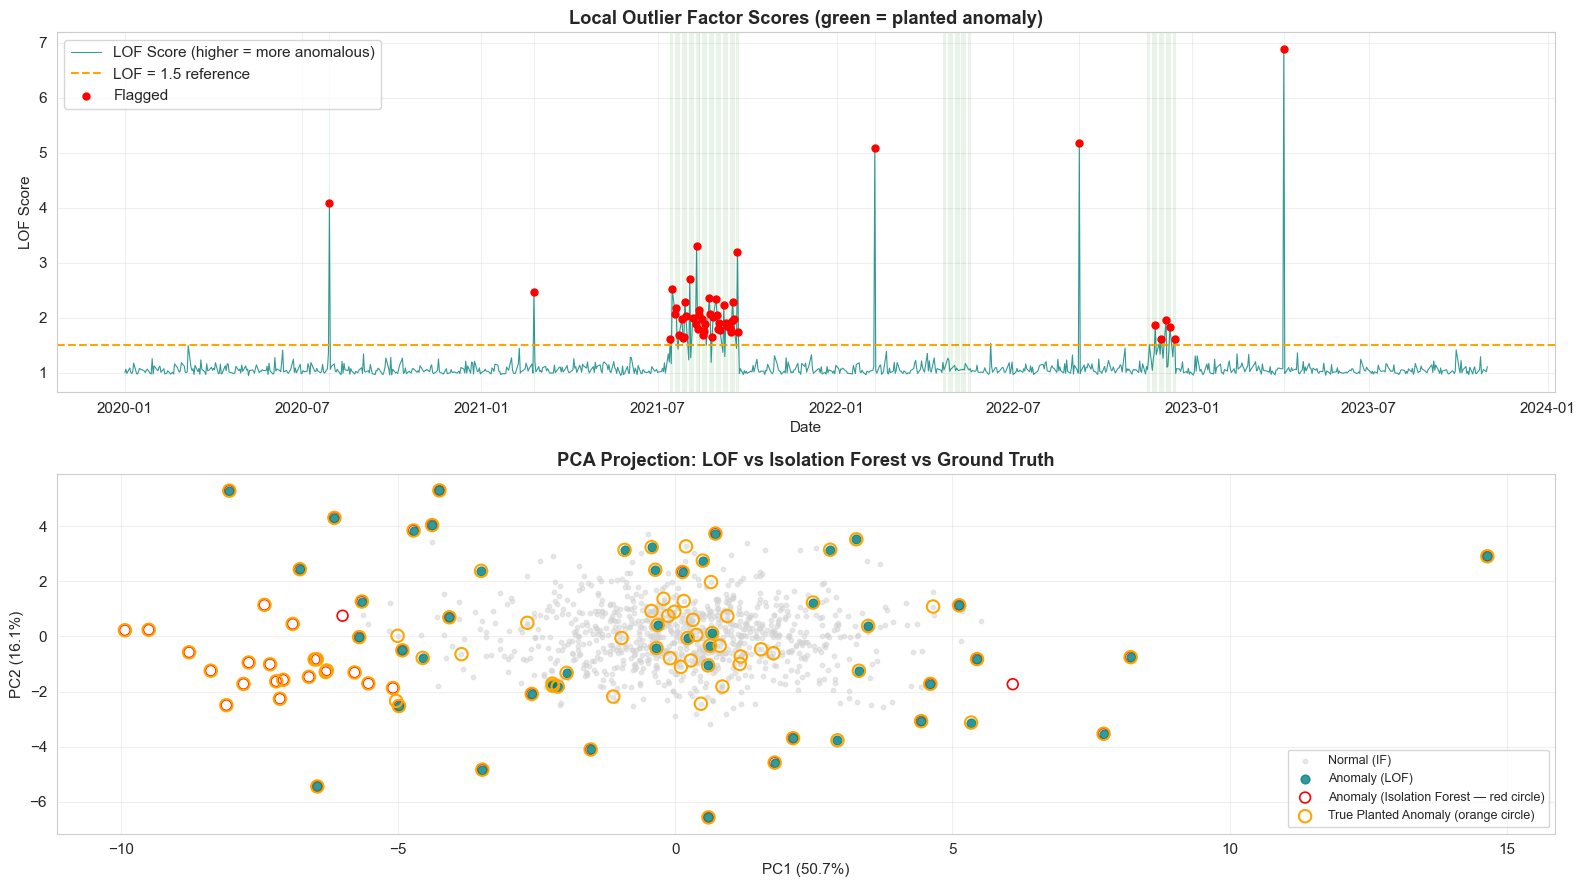

In [11]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION)
lof_pred   = lof.fit_predict(X_scaled)      # -1 = anomaly, 1 = normal
lof_scores = -lof.negative_outlier_factor_  # higher = more anomalous
lof_flags  = (lof_pred == -1).astype(int)

results.append(evaluate("Local Outlier Factor (k=20)", lof_flags))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)

# LOF scores over time
ax = axes[0]
ax.plot(dates, lof_scores, color='teal', linewidth=0.8, alpha=0.8,
        label='LOF Score (higher = more anomalous)')
ax.axhline(1.5, color='orange', linestyle='--', linewidth=1.5, label='LOF = 1.5 reference')
flagged_lof = lof_flags.astype(bool)
ax.scatter(dates[flagged_lof], lof_scores[flagged_lof],
           color='red', s=25, zorder=5, label='Flagged')
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='green', alpha=0.12, linewidth=0.5)
ax.set_title('Local Outlier Factor Scores (green = planted anomaly)', fontweight='bold')
ax.set_ylabel('LOF Score')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)

# Compare LOF vs Isolation Forest PCA projection
ax = axes[1]
ax.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
           c='lightgray', s=10, alpha=0.5, label='Normal (IF)')
ax.scatter(X_pca[lof_pred == -1, 0], X_pca[lof_pred == -1, 1],
           c='teal', s=40, alpha=0.8, zorder=5, label='Anomaly (LOF)')
ax.scatter(X_pca[iso_pred == -1, 0], X_pca[iso_pred == -1, 1],
           c='none', edgecolors='red', s=60, linewidths=1.2, zorder=4,
           label='Anomaly (Isolation Forest — red circle)')
ax.scatter(X_pca[planted_mask, 0], X_pca[planted_mask, 1],
           c='none', edgecolors='orange', s=80, linewidths=1.5, zorder=6,
           label='True Planted Anomaly (orange circle)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Projection: LOF vs Isolation Forest vs Ground Truth', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. One-Class SVM — Hyperplane-Based Anomaly Detection

> **In plain English:** One-Class SVM learns the **boundary** of the normal data in a high-dimensional feature space. Everything inside the boundary = normal. Anything outside = anomaly. It uses the kernel trick to draw flexible non-linear boundaries.
>
> **Analogy:** Imagine all your normal trading days as a cluster of points on a 2D map. One-Class SVM draws the tightest possible fence around them. Any new day that lands outside the fence is flagged.
>
> **Key parameter — ν (nu):**
> - ν is an upper bound on the fraction of training data treated as outliers
> - Set ν ≈ expected contamination rate (e.g., 0.05 for 5%)
> - Smaller ν = tighter fence = fewer flags; larger ν = looser fence = more flags
>
> **When to use One-Class SVM:**
> - When you have a **clean training period** (e.g., calm 2017 markets) and want to detect anomalies relative to that reference
> - When boundary shape is complex (non-Gaussian cluster structure)
> - When you want a **hyperplane-interpretable** decision boundary (vs. Isolation Forest's tree-based rule)
>
> **Limitation:** Very sensitive to scaling and the choice of kernel bandwidth (γ). Always scale your data and use cross-validation to tune γ.

### Beginner Explanation

One-Class SVM tries to draw a flexible boundary around what normal data looks like. If a new day lands outside that learned fence, it gets treated as abnormal.

It can work well, but it is more sensitive to scaling and tuning than some other methods. For a beginner, the main lesson is that this method is about learning the edge of normality, not the center of it.

One-Class SVM (RBF kernel)      Precision=0.873  Recall=0.490  F1=0.627  Flagged=55


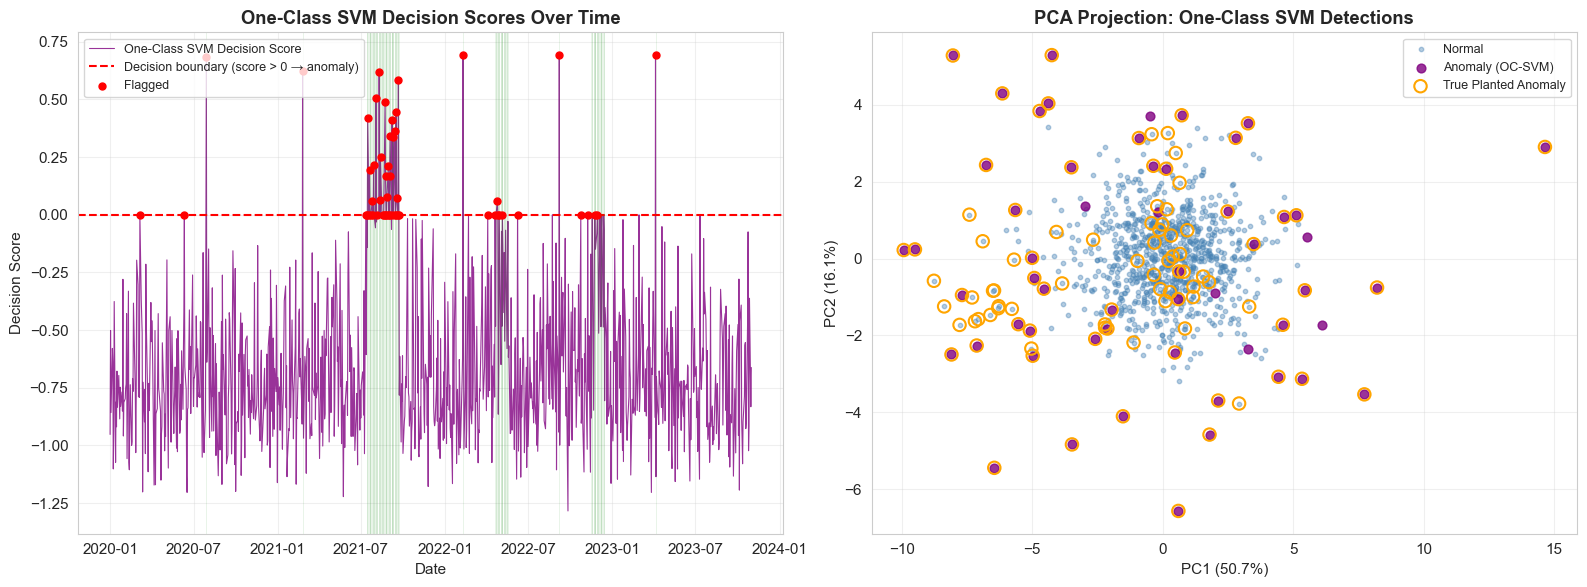

In [12]:
ocsvm = OneClassSVM(kernel='rbf', nu=CONTAMINATION, gamma='scale')
ocsvm.fit(X_scaled)

ocsvm_pred   = ocsvm.predict(X_scaled)                   # -1 = anomaly
ocsvm_scores = -ocsvm.decision_function(X_scaled)        # higher = more anomalous
ocsvm_flags  = (ocsvm_pred == -1).astype(int)

results.append(evaluate("One-Class SVM (RBF kernel)", ocsvm_flags))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Decision score over time
ax = axes[0]
ax.plot(dates, ocsvm_scores, color='purple', linewidth=0.8, alpha=0.8,
        label='One-Class SVM Decision Score')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5,
           label='Decision boundary (score > 0 → anomaly)')
svm_flagged = ocsvm_flags.astype(bool)
ax.scatter(dates[svm_flagged], ocsvm_scores[svm_flagged],
           color='red', s=25, zorder=5, label='Flagged')
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='green', alpha=0.12, linewidth=0.5)
ax.set_title('One-Class SVM Decision Scores Over Time', fontweight='bold')
ax.set_ylabel('Decision Score')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# PCA 2D: SVM decision boundary
ax = axes[1]
ax.scatter(X_pca[ocsvm_pred == 1, 0], X_pca[ocsvm_pred == 1, 1],
           c='steelblue', s=10, alpha=0.4, label='Normal')
ax.scatter(X_pca[ocsvm_pred == -1, 0], X_pca[ocsvm_pred == -1, 1],
           c='purple', s=40, alpha=0.8, zorder=5, label='Anomaly (OC-SVM)')
ax.scatter(X_pca[planted_mask, 0], X_pca[planted_mask, 1],
           c='none', edgecolors='orange', s=80, linewidths=1.5, zorder=6,
           label='True Planted Anomaly')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Projection: One-Class SVM Detections', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Autoencoder — Deep Learning Anomaly Detection

> **In plain English:** An Autoencoder is a neural network trained to **compress** its input into a small bottleneck representation, then **reconstruct** the original input. If you train it on normal data only, it learns to compress and reconstruct normal patterns efficiently. When it encounters an anomaly, it hasn't learned how to compress that pattern — so the reconstruction error is large.
>
> **Architecture:**
> ```
> Input (10 features)
>     ↓  Encoder
> Bottleneck (4 features — compressed representation)
>     ↓  Decoder
> Reconstruction (10 features)
>     ↓
> Anomaly Score = MSE(input, reconstruction)
> ```
>
> **Why Autoencoders excel for portfolios:**
> - **No assumption** about the shape of the normal distribution — purely data-driven
> - Learns **complex correlation patterns** among the 10 stocks simultaneously
> - The bottleneck forces the model to capture the *essential structure* of normal days
> - Anomalous days violate the learned structure → high reconstruction error
>
> **Training strategy:** Train on a "burn-in" period of presumably normal data (e.g., first 200 days). Then apply to the full period to detect deviations from the learned normal pattern.
>
> **Threshold selection:** Use the 95th or 99th percentile of reconstruction errors on the training set as the threshold.

### Beginner Explanation

An autoencoder learns what normal patterns look like by trying to rebuild them. If it can rebuild a day well, the day looks familiar. If reconstruction fails badly, the day may be anomalous.

The key beginner idea is that the model is not predicting returns. It is measuring how unfamiliar the pattern is.

⚠ TensorFlow not installed — using sklearn MLPRegressor as fallback
✓ sklearn MLP autoencoder trained
Autoencoder (recon. error)      Precision=0.593  Recall=0.847  F1=0.697  Flagged=140


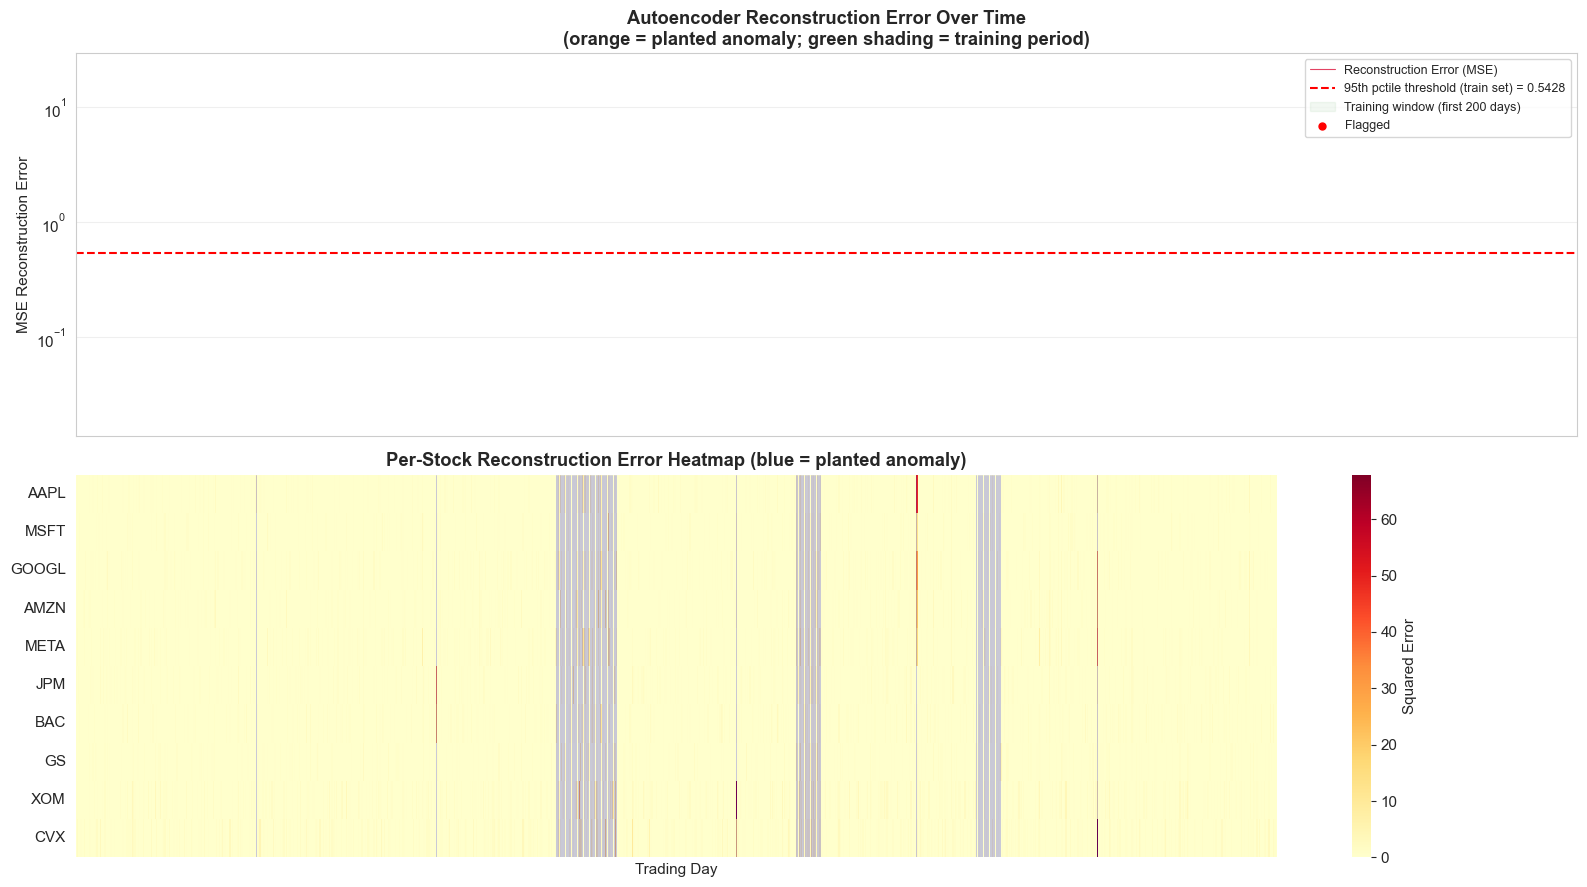

In [13]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks
    TF_AVAILABLE = True
    print(f"✓ TensorFlow {tf.__version__} available")
except ImportError:
    TF_AVAILABLE = False
    print("⚠ TensorFlow not installed — using sklearn MLPRegressor as fallback")

# ── Autoencoder using sklearn fallback (always available) ─────────────────────
# For portability we implement a lightweight autoencoder via MLPRegressor
# In production use TensorFlow/Keras for full flexibility
from sklearn.neural_network import MLPRegressor

TRAIN_DAYS = 200   # train only on first 200 days (assumed normal burn-in period)

X_train = X_scaled[:TRAIN_DAYS]
X_all   = X_scaled

if TF_AVAILABLE:
    tf.random.set_seed(42)
    n_features = N_STOCKS

    encoder_input  = layers.Input(shape=(n_features,))
    encoded        = layers.Dense(8, activation='relu')(encoder_input)
    bottleneck     = layers.Dense(4, activation='relu')(encoded)
    decoded        = layers.Dense(8, activation='relu')(bottleneck)
    decoder_output = layers.Dense(n_features, activation='linear')(decoded)

    autoencoder = models.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer='adam', loss='mse')

    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                          restore_best_weights=True)
    history = autoencoder.fit(
        X_train, X_train,
        epochs=150, batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0)

    X_reconstructed = autoencoder.predict(X_all, verbose=0)
    recon_errors     = np.mean((X_all - X_reconstructed) ** 2, axis=1)
    print(f"✓ Keras autoencoder trained for {len(history.history['loss'])} epochs")

else:
    # Fallback: two-layer MLP trained as autoencoder
    ae_mlp = MLPRegressor(hidden_layer_sizes=(8, 4, 8), activation='relu',
                           max_iter=500, random_state=42, early_stopping=True,
                           validation_fraction=0.2, n_iter_no_change=10)
    ae_mlp.fit(X_train, X_train)
    X_reconstructed = ae_mlp.predict(X_all)
    recon_errors     = np.mean((X_all - X_reconstructed) ** 2, axis=1)
    print("✓ sklearn MLP autoencoder trained")

# Threshold: 95th percentile of training reconstruction errors
train_errors = recon_errors[:TRAIN_DAYS]
ae_threshold = np.percentile(train_errors, 95)
ae_flags     = (recon_errors > ae_threshold).astype(int)

results.append(evaluate("Autoencoder (recon. error)", ae_flags))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Reconstruction error over time
ax = axes[0]
ax.plot(dates, recon_errors, color='crimson', linewidth=0.8, alpha=0.8,
        label='Reconstruction Error (MSE)')
ax.axhline(ae_threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'95th pctile threshold (train set) = {ae_threshold:.4f}')
ax.axvspan(dates[0], dates[TRAIN_DAYS-1], alpha=0.05, color='green',
           label=f'Training window (first {TRAIN_DAYS} days)')
ae_flagged = ae_flags.astype(bool)
ax.scatter(dates[ae_flagged], recon_errors[ae_flagged],
           color='red', s=25, zorder=5, label='Flagged')
for d in sorted(anomaly_days):
    ax.axvline(dates[d], color='orange', alpha=0.12, linewidth=0.5)
ax.set_title('Autoencoder Reconstruction Error Over Time\n(orange = planted anomaly; '
             'green shading = training period)', fontweight='bold')
ax.set_ylabel('MSE Reconstruction Error')
ax.legend(fontsize=9)
ax.set_yscale('log')
ax.grid(alpha=0.3)

# Per-feature reconstruction error heatmap
feature_errors = (X_all - X_reconstructed) ** 2
ax = axes[1]
sns.heatmap(pd.DataFrame(feature_errors, columns=TICKERS).T,
            ax=ax, cmap='YlOrRd', xticklabels=False,
            cbar_kws={'label': 'Squared Error'})
for d in sorted(anomaly_days):
    ax.axvline(d, color='blue', alpha=0.3, linewidth=0.5)
ax.set_title('Per-Stock Reconstruction Error Heatmap (blue = planted anomaly)',
             fontweight='bold')
ax.set_xlabel('Trading Day')

plt.tight_layout()
plt.show()

## 11. Ensemble Anomaly Score — Combining All Methods

> **In plain English:** No single anomaly detection method is perfect. Statistical methods catch magnitude outliers. Mahalanobis catches multivariate anomalies. CUSUM catches slow drifts. Autoencoders catch pattern violations. The best strategy is to **combine them**: a day that is flagged by 5 out of 8 methods is far more likely to be genuinely anomalous than one flagged by only 1 method.
>
> **Ensemble approaches:**
>
> | Strategy | How It Works | Best When |
> |----------|------------|-----------|
> | **Vote counting** | Flag if ≥ k methods agree | Methods have similar precision |
> | **Averaged score** | Normalise each score to [0,1] and average | Different sensitivity levels |
> | **Rank aggregation** | Rank days by each method, average the ranks | Scores have different scales |
>
> We use **normalised score averaging** — more principled than vote counting because it preserves the intensity of each signal.
>
> **The risk calendar:** The final output is a heatmap organised by month and day-of-month, coloured by ensemble anomaly score. This gives portfolio managers an immediate visual of "when did the portfolio behave abnormally" — actionable for post-trade analysis, attribution, and risk reporting.

### Beginner Explanation

The ensemble section combines signals because different methods specialize in different anomaly types. A day flagged by several independent methods deserves more attention than a day flagged by only one.

This is a common real-world pattern in risk systems: do not trust one detector blindly when you can combine several views of the same event.

Ensemble (average score >0.5)   Precision=1.000  Recall=0.051  F1=0.097  Flagged=5

Method                              Precision    Recall        F1   Flagged
----------------------------------------------------------------------
Z-Score (standard)                      0.902     0.561     0.692        61
Modified Z-Score (MAD)                  0.791     0.694     0.739        86
Bollinger Bands (20d, 2.5σ)             0.154     0.020     0.036        13
IQR (3.0× fence, ≥1 stock)              1.000     0.194     0.325        19
Mahalanobis Distance (χ²,99%)           1.000     0.561     0.719        55
CUSUM (5σ threshold)                    0.336     0.776     0.469       226
CUSUM (5σ threshold)                    0.336     0.776     0.469       226
Isolation Forest (200 trees)            0.960     0.490     0.649        50
Isolation Forest (200 trees)            0.960     0.490     0.649        50
Local Outlier Factor (k=20)             1.000     0.510     0.676        50
One-Class

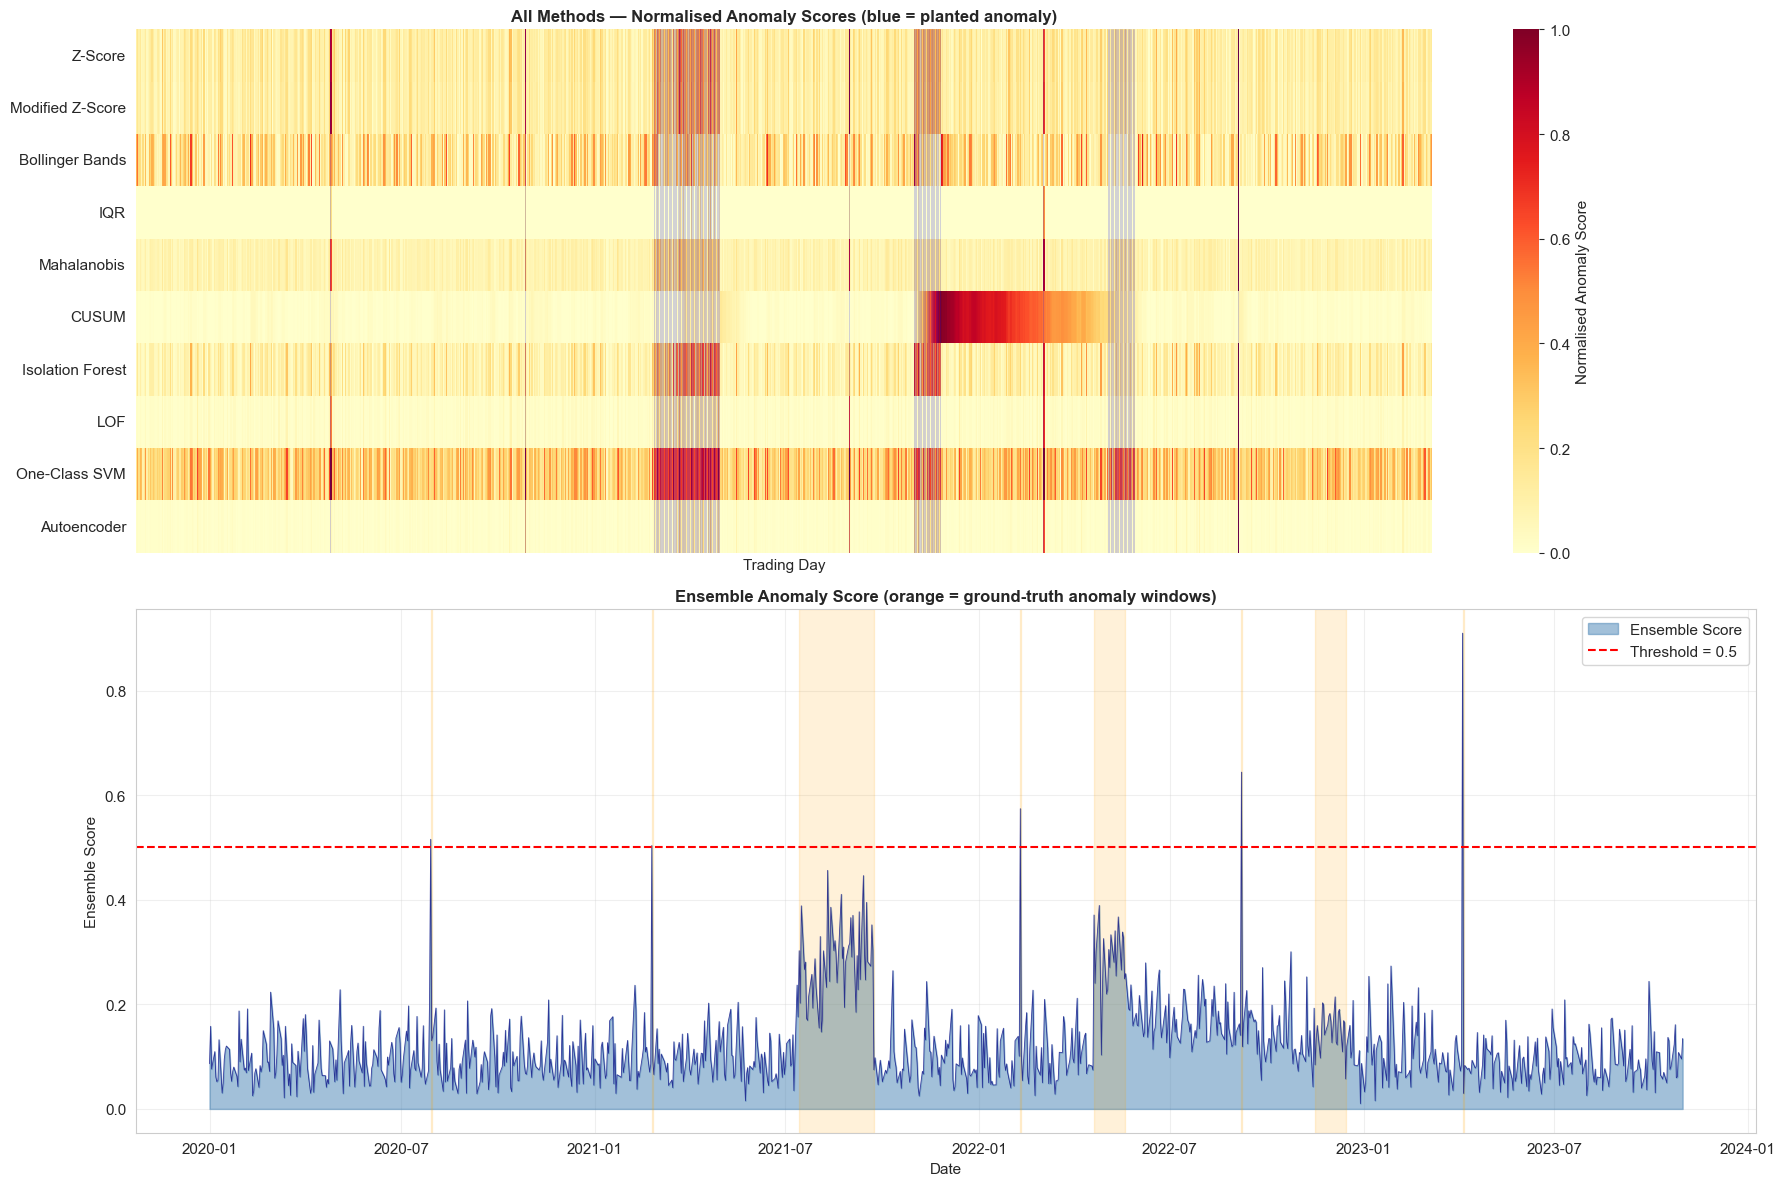

In [14]:
def minmax_norm(arr):
    """Normalise array to [0, 1]."""
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-10)

# Collect all continuous anomaly scores (normalised to [0, 1])
scores_dict = {
    'Z-Score':           minmax_norm(z_portfolio.values),
    'Modified Z-Score':  minmax_norm(mz_portfolio.values),
    'Bollinger Bands':   minmax_norm(np.abs(ptf_ret.values - roll_mean.fillna(method='bfill').values)
                                     / (roll_std.fillna(method='bfill').values + 1e-10)),
    'IQR':               minmax_norm(iqr_count_per_day.values.astype(float)),
    'Mahalanobis':       minmax_norm(maha_dist),
    'CUSUM':             minmax_norm(np.maximum(S_plus, S_minus)),
    'Isolation Forest':  minmax_norm(iso_scores),
    'LOF':               minmax_norm(lof_scores),
    'One-Class SVM':     minmax_norm(ocsvm_scores),
    'Autoencoder':       minmax_norm(recon_errors),
}

scores_df   = pd.DataFrame(scores_dict, index=dates)
ensemble    = scores_df.mean(axis=1)
ENSEMBLE_THRESH = 0.5
ensemble_flags  = (ensemble > ENSEMBLE_THRESH).astype(int).values

results.append(evaluate("Ensemble (average score >0.5)", ensemble_flags))

# ── Summary comparison table ──────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"{'Method':<35} {'Precision':>9} {'Recall':>9} {'F1':>9} {'Flagged':>9}")
print("-" * 70)
for r in results:
    print(f"{r['name']:<35} {r['precision']:>9.3f} {r['recall']:>9.3f} "
          f"{r['f1']:>9.3f} {r['flagged']:>9d}")
print("=" * 70)
print(f"\nGround truth: {y_true.sum()} anomalous days ({100*y_true.mean():.1f}%)")

# ── Figure 1: Scores heatmap across all methods ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

ax = axes[0]
sns.heatmap(scores_df.T, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=False, cbar_kws={'label': 'Normalised Anomaly Score'})
for d in sorted(anomaly_days):
    ax.axvline(d, color='blue', alpha=0.25, linewidth=0.5)
ax.set_title('All Methods — Normalised Anomaly Scores (blue = planted anomaly)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Trading Day')

# ── Figure 2: Ensemble score with ground truth ────────────────────────────────
ax = axes[1]
ax.fill_between(dates, ensemble, alpha=0.5, color='steelblue', label='Ensemble Score')
ax.plot(dates, ensemble, color='navy', linewidth=0.6, alpha=0.7)
ax.axhline(ENSEMBLE_THRESH, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold = {ENSEMBLE_THRESH}')
# Shade true anomaly periods
in_anomaly = False
start = None
for i, (flag, date) in enumerate(zip(y_true, dates)):
    if flag and not in_anomaly:
        start = date; in_anomaly = True
    elif not flag and in_anomaly:
        ax.axvspan(start, date, alpha=0.15, color='orange')
        in_anomaly = False
if in_anomaly:
    ax.axvspan(start, dates[-1], alpha=0.15, color='orange')

ax.set_title('Ensemble Anomaly Score (orange = ground-truth anomaly windows)',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Ensemble Score')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

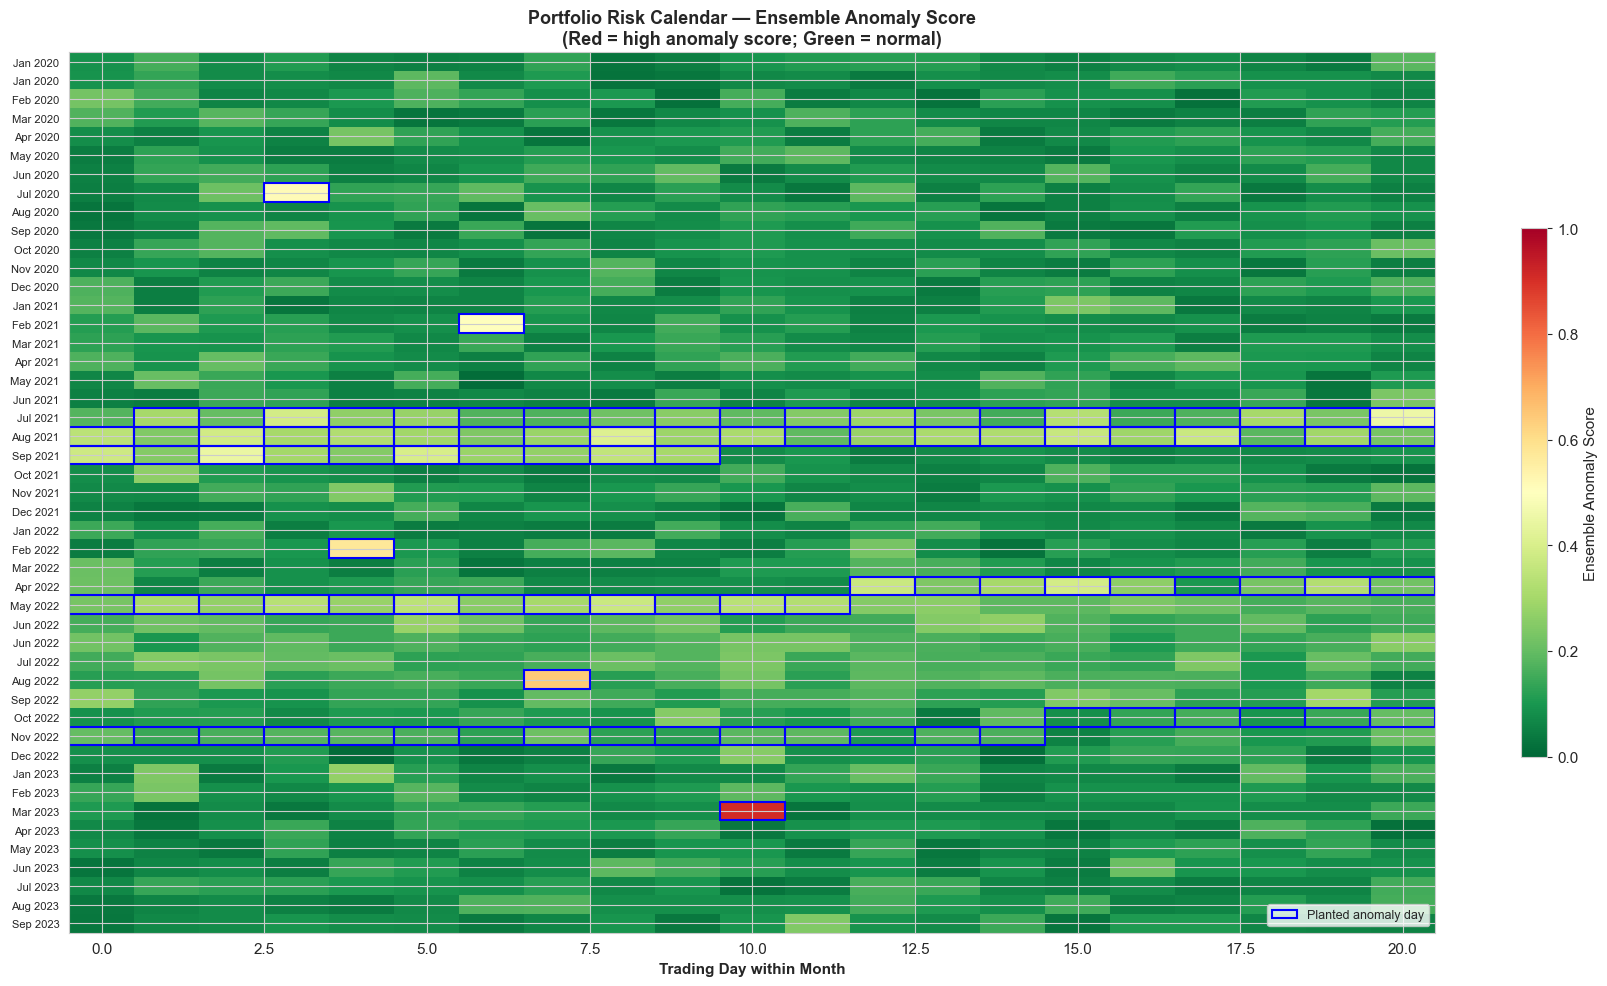


✓ Risk Calendar: each row = 1 month of trading days
  Red cells = high ensemble anomaly score
  Blue border = planted anomaly (ground truth)


In [15]:
# ── Risk Calendar Heatmap ─────────────────────────────────────────────────────
# Organise by month (y-axis) × day number in period (x-axis)
# Group into months of ~21 trading days for a clean calendar view
MONTH_SIZE = 21
n_months   = N_DAYS // MONTH_SIZE

ens_values  = ensemble.values[:n_months * MONTH_SIZE]
calendar    = ens_values.reshape(n_months, MONTH_SIZE)

# Month labels
month_dates = [dates[i * MONTH_SIZE].strftime('%b %Y') for i in range(n_months)]

fig, ax = plt.subplots(figsize=(18, 10))
im = ax.imshow(calendar, aspect='auto', cmap='RdYlGn_r',
               vmin=0, vmax=1, interpolation='nearest')

ax.set_yticks(range(n_months))
ax.set_yticklabels(month_dates, fontsize=8)
ax.set_xlabel('Trading Day within Month', fontweight='bold')
ax.set_title('Portfolio Risk Calendar — Ensemble Anomaly Score\n'
             '(Red = high anomaly score; Green = normal)', fontweight='bold', fontsize=13)
plt.colorbar(im, ax=ax, label='Ensemble Anomaly Score', shrink=0.6)

# Mark planted anomaly cells
y_true_cal = y_true[:n_months * MONTH_SIZE].reshape(n_months, MONTH_SIZE)
for row in range(n_months):
    for col in range(MONTH_SIZE):
        if y_true_cal[row, col]:
            rect = plt.Rectangle((col - 0.5, row - 0.5), 1, 1,
                                   linewidth=1.5, edgecolor='blue',
                                   facecolor='none')
            ax.add_patch(rect)

# Legend for blue box
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='none', edgecolor='blue',
                          linewidth=1.5, label='Planted anomaly day')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Risk Calendar: each row = 1 month of trading days")
print("  Red cells = high ensemble anomaly score")
print("  Blue border = planted anomaly (ground truth)")


## 13. Fixed Income — Bonds with Different Maturities

> **In plain English:** An equity portfolio gives you daily percentage returns — all comparable, all on the same scale. A bond portfolio gives you a **yield curve**: each instrument has a different maturity (3 months to 30 years), a different price sensitivity to interest rate moves, and a different structural role. Anomaly detection must respect this *term structure*.

> **Three anomaly types specific to bonds:**
>
> | Anomaly Type | What Happens | Typical Trigger |
> |---|---|---|
> | **Parallel Shock** | All yields jump by roughly the same amount | Surprise central bank decision |
> | **Curve Twist** | Short rates rise while long rates fall (or vice versa) | Shift in rate-cut/hike expectations |
> | **Belly Anomaly** | Intermediate maturities (2Y–7Y) spike independently | Auction failure, specific-tenor liquidity crunch |
>
> **Key fixed income concepts:**
>
> | Term | Meaning |
> |---|---|
> | **Duration** | How much the bond price changes per 1% yield move. Longer maturity → higher duration → bigger P&L impact |
> | **DV01** | Dollar Value of 01 (basis point) — P&L per $1 face value per 1bp yield move |
> | **Yield Curve** | Chart of yield vs. maturity. Normally upward-sloping; inversions often precede recessions |
> | **Nelson-Siegel** | A 4-parameter formula that fits the curve's *shape* (level + slope + hump) |
>
> **Why standard equity methods fall short:**
> Z-scoring raw yield changes ignores duration — a 10bp move in the 30Y has ~3× the P&L impact of the same move in the 10Y. Cross-tenor correlations also behave differently during crises (e.g., a flight-to-quality flattener). We need **multivariate, structure-aware** methods.
>
> **Three methods covered in this section:**
> 1. **PCA on Yield Changes** — decompose the 10-dimensional yield move into Level, Slope, Curvature factors; flag days where the Mahalanobis distance in that 3D factor space is extreme
> 2. **Nelson-Siegel Residuals** — fit the parametric curve model to each day's yield levels; flag days where the *shape* of the curve is abnormal (large fit residuals)
> 3. **Duration-Weighted Portfolio P&L** — convert yield changes to bond price impacts using modified duration; flag days with extreme interest-rate P&L


### Beginner Explanation

Fixed income anomalies are different from equity anomalies because bonds sit on a yield curve rather than behaving like a set of comparable stock returns. A move in short maturities and a move in long maturities do not mean the same thing.

So the main beginner shift in this section is: instead of looking only at return size, you also have to think about maturity, curve shape, and interest-rate sensitivity.

✓ Yield curve: 10 maturities × 500 trading days
✓ Anomaly breakdown (total=28, 5.6% of days):
   Parallel shocks: 10  |  Curve twists: 10  |  Belly anomalies: 8

Final yield curve snapshot:
    3M: 6.14%
    6M: 6.23%
    1Y: 5.65%
    2Y: 3.91%
    3Y: 3.43%
    5Y: 2.92%
    7Y: 2.54%
   10Y: 2.84%
   20Y: 2.05%
   30Y: 1.82%


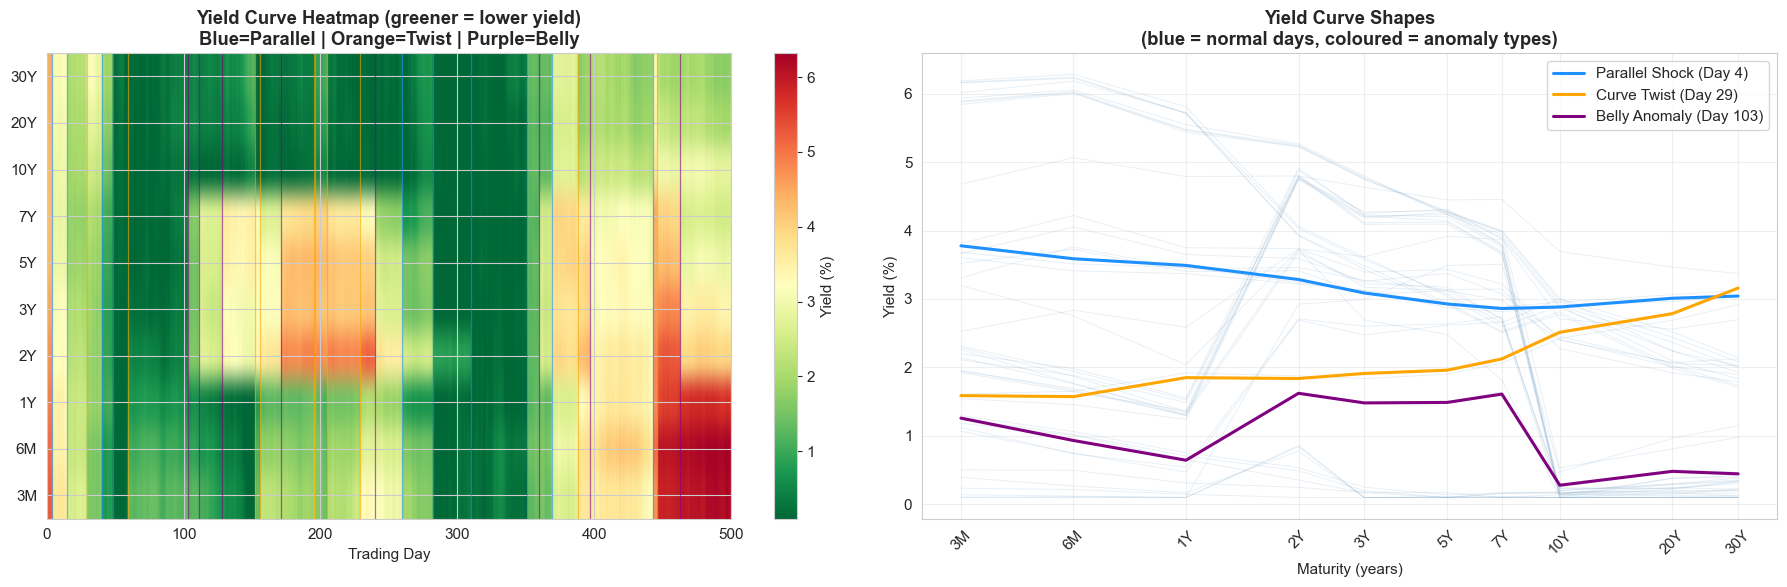

In [16]:

# ── Fixed Income Portfolio Setup ──────────────────────────────────────────────
MATURITIES = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]   # standard Treasury tenors
MAT_LABELS  = ['3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
N_MAT       = len(MATURITIES)
N_BOND_DAYS = 500

# ── 3-Factor model: Level, Slope, Curvature (à la Litterman-Scheinkman 1991) ─
# Each factor describes a "mode of movement" for the entire yield curve.
#   PC1 (Level):     all maturities move together by the same amount
#   PC2 (Slope):     short end moves opposite to long end (flattener / steepener)
#   PC3 (Curvature): belly (5Y) moves opposite to wings (3M and 30Y)
_f = np.column_stack([
    np.ones(N_MAT),                                         # Level
    np.linspace(-1, 1, N_MAT),                             # Slope
    -np.sin(np.pi * np.arange(N_MAT) / (N_MAT - 1)),      # Curvature
])
F_LOADINGS  = _f / np.linalg.norm(_f, axis=0)              # normalise columns
F_VOLS_YC   = np.array([0.0008, 0.0010, 0.0005])           # daily factor vols

rng_b       = np.random.default_rng(77)
INIT_YIELDS = np.array([0.053, 0.052, 0.050, 0.048, 0.046,
                         0.044, 0.043, 0.043, 0.044, 0.045])  # ~flat/inverted

# ── Generate normal daily yield changes ──────────────────────────────────────
f_changes  = rng_b.normal(0, 1, (N_BOND_DAYS, 3)) * F_VOLS_YC
idio_noise = rng_b.normal(0, 0.00015, (N_BOND_DAYS, N_MAT))
yield_chg  = f_changes @ F_LOADINGS.T + idio_noise           # (N_BOND_DAYS, N_MAT)

# ── Select anomaly days for 3 types ──────────────────────────────────────────
shock_days = list(rng_b.choice(N_BOND_DAYS, 10, replace=False))
avail      = [d for d in range(N_BOND_DAYS) if d not in shock_days]
twist_days = list(rng_b.choice(avail, 10, replace=False))
avail2     = [d for d in avail if d not in twist_days]
belly_days = list(rng_b.choice(avail2, 8, replace=False))

belly_mask = np.array([False, False, False, True, True, True, True, False, False, False])

# ── Inject anomalous changes ──────────────────────────────────────────────────
bond_y_true        = np.zeros(N_BOND_DAYS, dtype=int)
bond_anomaly_types = {}

for d in shock_days:
    yield_chg[d] += rng_b.choice([-1, 1]) * rng_b.uniform(0.008, 0.018)
    bond_y_true[d] = 1;  bond_anomaly_types[d] = 'Parallel Shock'

for d in twist_days:
    direction    = rng_b.choice([-1, 1])
    yield_chg[d] += direction * rng_b.uniform(0.004, 0.012) * np.linspace(-1, 1, N_MAT)
    bond_y_true[d] = 1;  bond_anomaly_types[d] = 'Curve Twist'

for d in belly_days:
    yield_chg[d, belly_mask] += rng_b.choice([-1, 1]) * rng_b.uniform(0.006, 0.014)
    bond_y_true[d] = 1;  bond_anomaly_types[d] = 'Belly Anomaly'

# ── Build yield level path ────────────────────────────────────────────────────
bond_yields    = np.zeros((N_BOND_DAYS, N_MAT))
bond_yields[0] = np.maximum(INIT_YIELDS + yield_chg[0], 0.001)
for t in range(1, N_BOND_DAYS):
    bond_yields[t] = np.maximum(bond_yields[t-1] + yield_chg[t], 0.001)

bond_dates   = pd.date_range('2021-01-04', periods=N_BOND_DAYS, freq='B')
normal_idx_b = [i for i in range(N_BOND_DAYS) if bond_y_true[i] == 0]

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"✓ Yield curve: {N_MAT} maturities × {N_BOND_DAYS} trading days")
print(f"✓ Anomaly breakdown (total={bond_y_true.sum()}, "
      f"{bond_y_true.mean()*100:.1f}% of days):")
print(f"   Parallel shocks: {len(shock_days)}  |  "
      f"Curve twists: {len(twist_days)}  |  "
      f"Belly anomalies: {len(belly_days)}")
print(f"\nFinal yield curve snapshot:")
for lbl, y in zip(MAT_LABELS, bond_yields[-1]):
    print(f"  {lbl:>4s}: {y*100:.2f}%")

# ── Visualise ─────────────────────────────────────────────────────────────────
colour_map_type = {'Parallel Shock': 'dodgerblue',
                   'Curve Twist':    'orange',
                   'Belly Anomaly':  'purple'}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: yield curve heatmap (rows = maturities, cols = trading days)
ax = axes[0]
im = ax.imshow(bond_yields.T * 100, aspect='auto', cmap='RdYlGn_r',
               extent=[0, N_BOND_DAYS, -0.5, N_MAT - 0.5], origin='lower')
for d, atype in bond_anomaly_types.items():
    ax.axvline(d, color=colour_map_type[atype], alpha=0.6, linewidth=0.9)
ax.set_yticks(range(N_MAT)); ax.set_yticklabels(MAT_LABELS)
ax.set_xlabel('Trading Day')
ax.set_title('Yield Curve Heatmap (greener = lower yield)\n'
             'Blue=Parallel | Orange=Twist | Purple=Belly',
             fontweight='bold')
plt.colorbar(im, ax=ax, label='Yield (%)')

# Right: curve shapes on selected days
ax = axes[1]
for i in rng_b.choice(normal_idx_b, 40, replace=False):
    ax.plot(MATURITIES, bond_yields[i]*100, color='steelblue', alpha=0.12, linewidth=0.7)

shown_types = set()
for d in sorted(bond_anomaly_types):
    atype = bond_anomaly_types[d]
    if atype not in shown_types:
        ax.plot(MATURITIES, bond_yields[d]*100,
                color=colour_map_type[atype], linewidth=2.2,
                label=f'{atype} (Day {d})')
        shown_types.add(atype)

ax.set_xscale('log')
ax.set_xticks(MATURITIES); ax.set_xticklabels(MAT_LABELS, rotation=45)
ax.set_xlabel('Maturity (years)'); ax.set_ylabel('Yield (%)')
ax.set_title('Yield Curve Shapes\n(blue = normal days, coloured = anomaly types)',
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Variance explained by first 3 PCs of yield changes:
  PC1 — Level (parallel shift): 73.8%
  PC2 — Slope (twist / flattening): 16.8%
  PC3 — Curvature (butterfly): 9.0%
  Total: 99.6%
PCA Factor Anomaly (Mahalanobis)           Precision=1.000  Recall=1.000  F1=1.000  Flagged=28


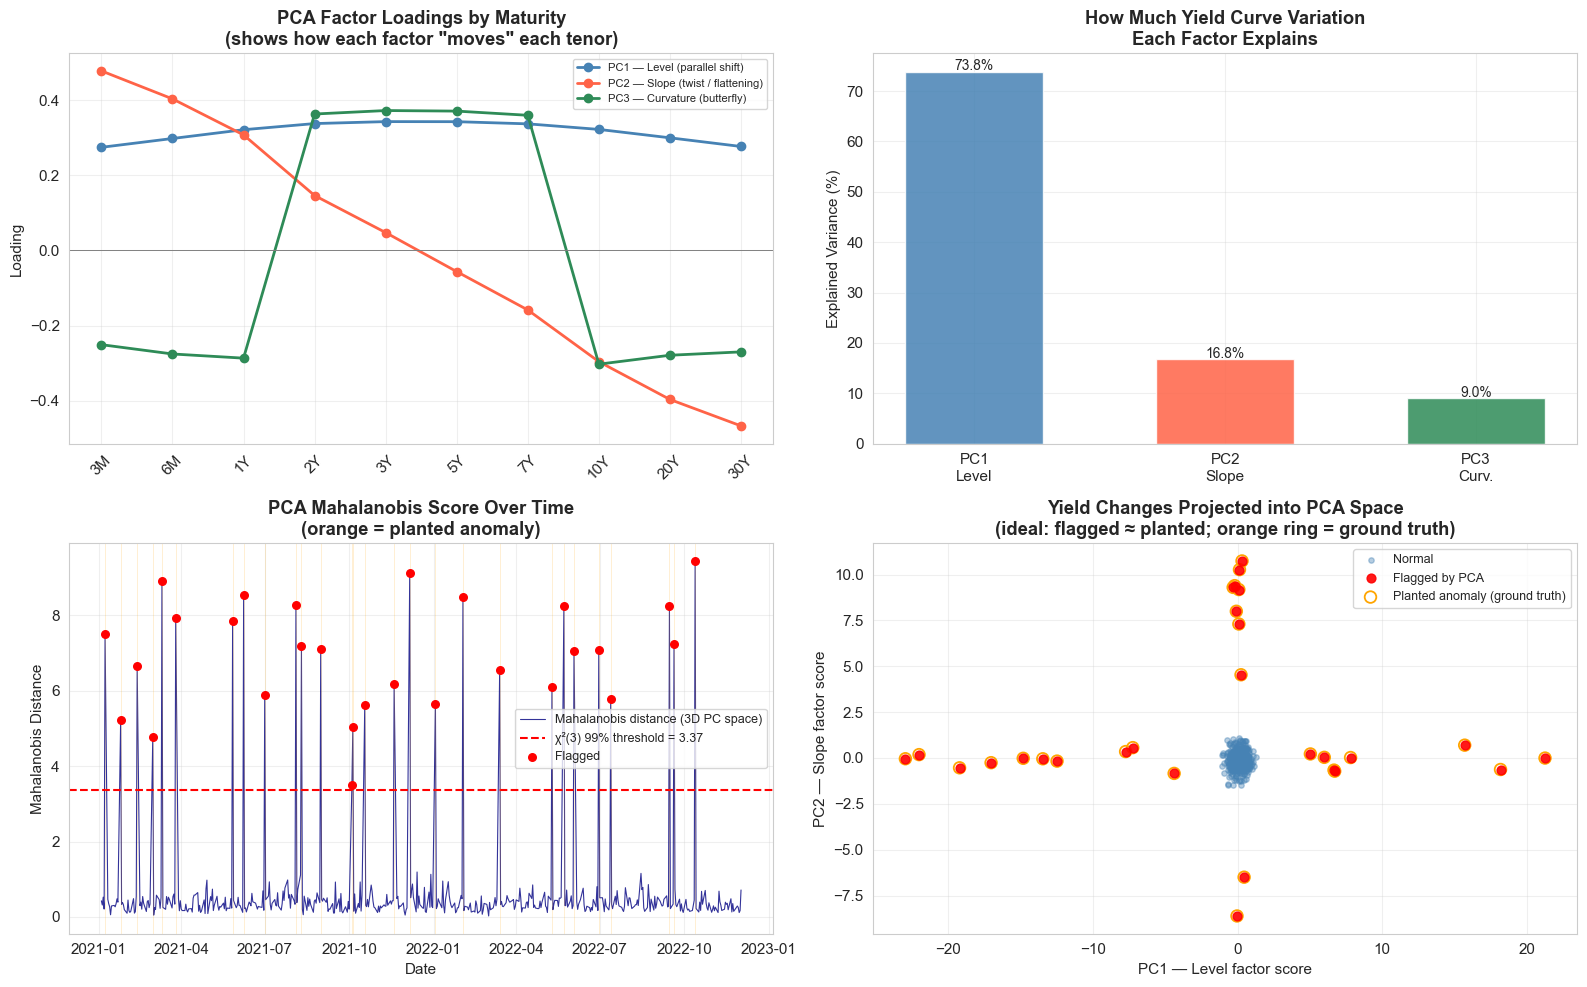

In [17]:

from sklearn.preprocessing import StandardScaler as _SS

# ── Standardise yield changes (each maturity to zero mean, unit std) ──────────
_scaler_b    = _SS()
yield_chg_sc = _scaler_b.fit_transform(yield_chg)    # (N_BOND_DAYS, N_MAT)

# ── Fit PCA to standardised yield changes ────────────────────────────────────
pca_yc    = PCA(n_components=3)
yc_scores = pca_yc.fit_transform(yield_chg_sc)        # (N_BOND_DAYS, 3)
loadings  = pca_yc.components_                         # (3, N_MAT)
ev_ratio  = pca_yc.explained_variance_ratio_

pc_names = ['PC1 — Level (parallel shift)',
            'PC2 — Slope (twist / flattening)',
            'PC3 — Curvature (butterfly)']

print("Variance explained by first 3 PCs of yield changes:")
for name, ev in zip(pc_names, ev_ratio):
    print(f"  {name}: {ev*100:.1f}%")
print(f"  Total: {ev_ratio.sum()*100:.1f}%")

# ── Anomaly detection: Mahalanobis distance in 3D PC space ───────────────────
# A normal yield move sits near the origin in PC space.
# An anomalous move is an outlier in one or more factor directions.
_cov_pc     = np.cov(yc_scores.T)
_mu_pc      = yc_scores.mean(axis=0)
_cov_pc_inv = np.linalg.inv(_cov_pc)

pca_maha = np.array([
    np.sqrt(max((row - _mu_pc) @ _cov_pc_inv @ (row - _mu_pc), 0.0))
    for row in yc_scores
])

chi2_thr_3   = np.sqrt(chi2.ppf(0.99, df=3))   # chi²(3) 99th pct → Mahal. threshold
pca_yc_flags = (pca_maha > chi2_thr_3).astype(int)

def bond_eval(name, flags, ytrue):
    flagged = int(flags.sum())
    tp      = int(((flags == 1) & (ytrue == 1)).sum())
    prec    = tp / flagged if flagged > 0 else 0.0
    rec     = tp / ytrue.sum() if ytrue.sum() > 0 else 0.0
    f1      = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    print(f"{name:<42s} Precision={prec:.3f}  Recall={rec:.3f}  "
          f"F1={f1:.3f}  Flagged={flagged}")
    return dict(Method=name, Precision=round(prec, 3), Recall=round(rec, 3),
                F1=round(f1, 3), Flagged=flagged)

bond_results = []
bond_results.append(bond_eval("PCA Factor Anomaly (Mahalanobis)", pca_yc_flags, bond_y_true))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colours_pc = ['steelblue', 'tomato', 'seagreen']

# Factor loadings — what does each PC "mean"?
ax = axes[0, 0]
for i, (name, c) in enumerate(zip(pc_names, colours_pc)):
    ax.plot(range(N_MAT), loadings[i], marker='o', color=c, linewidth=2, label=name)
ax.axhline(0, color='grey', linewidth=0.7)
ax.set_xticks(range(N_MAT)); ax.set_xticklabels(MAT_LABELS, rotation=45)
ax.set_title('PCA Factor Loadings by Maturity\n'
             '(shows how each factor "moves" each tenor)',
             fontweight='bold')
ax.set_ylabel('Loading'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Explained variance bar
ax = axes[0, 1]
bars = ax.bar(range(3), ev_ratio*100, color=colours_pc, alpha=0.85, width=0.55)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['PC1\nLevel', 'PC2\nSlope', 'PC3\nCurv.'])
for i, v in enumerate(ev_ratio*100):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('Explained Variance (%)')
ax.set_title('How Much Yield Curve Variation\nEach Factor Explains', fontweight='bold')
ax.grid(alpha=0.3)

# Mahalanobis score over time
ax = axes[1, 0]
ax.plot(bond_dates, pca_maha, color='navy', linewidth=0.8, alpha=0.8,
        label='Mahalanobis distance (3D PC space)')
ax.axhline(chi2_thr_3, color='red', linestyle='--', linewidth=1.5,
           label=f'χ²(3) 99% threshold = {chi2_thr_3:.2f}')
ax.scatter(bond_dates[pca_yc_flags.astype(bool)], pca_maha[pca_yc_flags.astype(bool)],
           color='red', s=30, zorder=5, label='Flagged')
for d in np.where(bond_y_true)[0]:
    ax.axvline(bond_dates[d], color='orange', alpha=0.2, linewidth=0.6)
ax.set_title('PCA Mahalanobis Score Over Time\n(orange = planted anomaly)',
             fontweight='bold')
ax.set_ylabel('Mahalanobis Distance'); ax.set_xlabel('Date')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 2D scatter in PC space
ax = axes[1, 1]
normal_b  = (pca_yc_flags == 0)
flagged_b = (pca_yc_flags == 1)
ax.scatter(yc_scores[normal_b,  0], yc_scores[normal_b,  1],
           color='steelblue', alpha=0.4, s=15, label='Normal')
ax.scatter(yc_scores[flagged_b, 0], yc_scores[flagged_b, 1],
           color='red', alpha=0.9, s=40, zorder=5, label='Flagged by PCA')
ax.scatter(yc_scores[bond_y_true.astype(bool), 0],
           yc_scores[bond_y_true.astype(bool), 1],
           facecolors='none', edgecolors='orange', s=70, linewidth=1.3,
           zorder=4, label='Planted anomaly (ground truth)')
ax.set_xlabel('PC1 — Level factor score')
ax.set_ylabel('PC2 — Slope factor score')
ax.set_title('Yield Changes Projected into PCA Space\n'
             '(ideal: flagged ≈ planted; orange ring = ground truth)',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Nelson-Siegel Parameter Jump               Precision=0.962  Recall=0.893  F1=0.926  Flagged=26


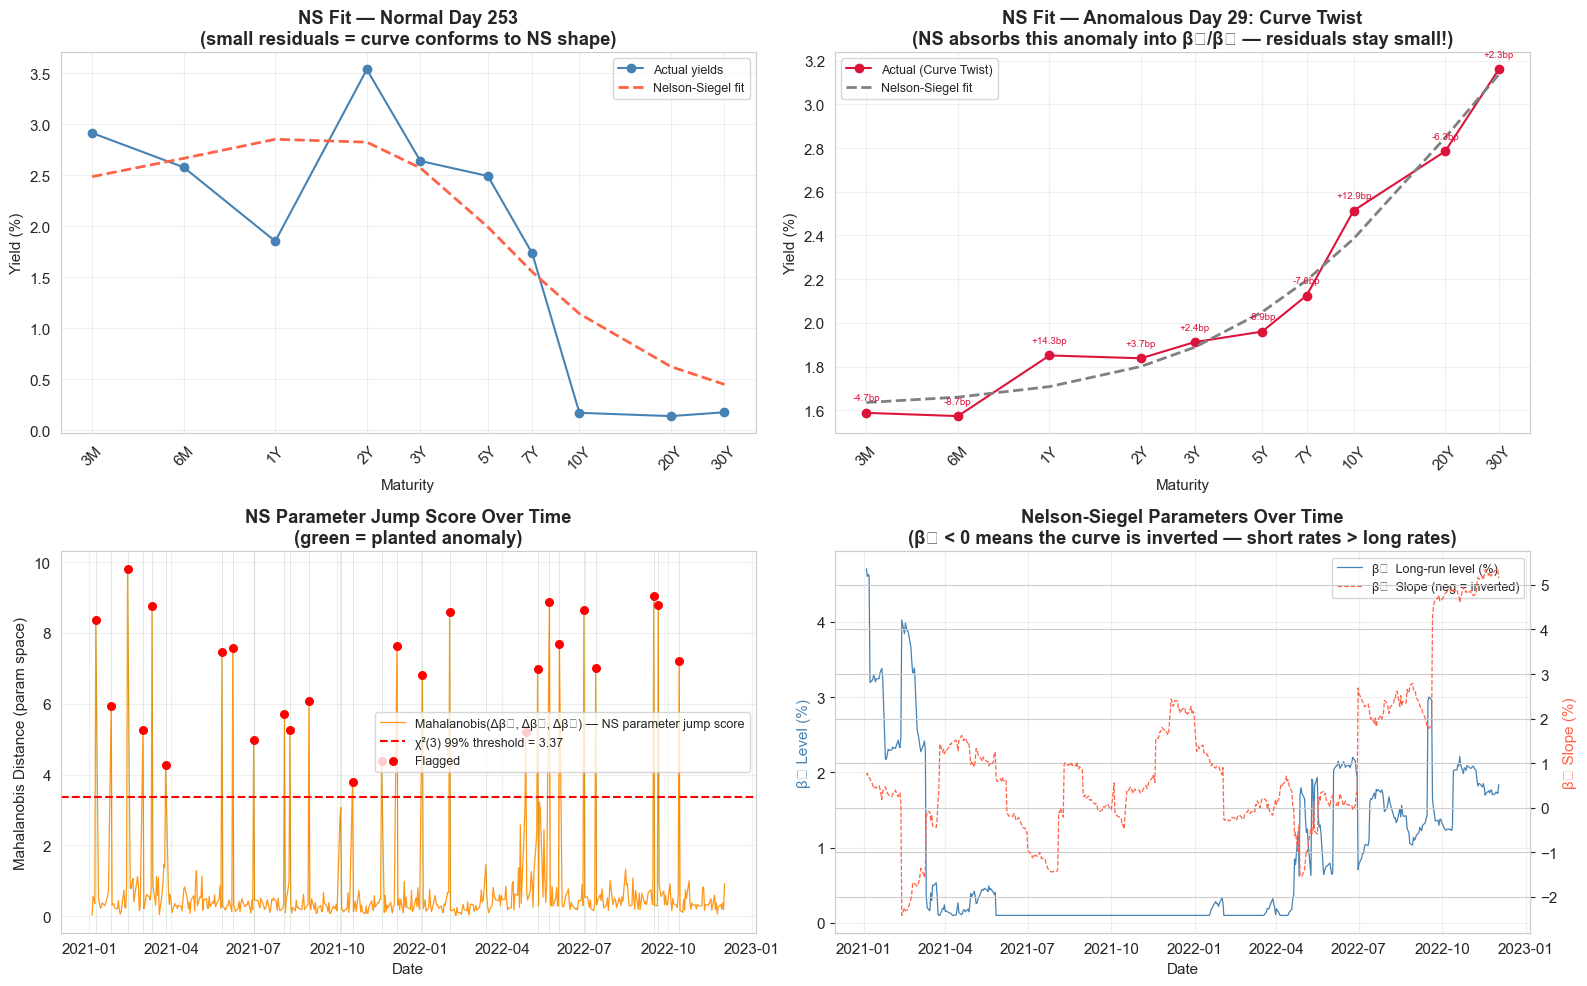

In [19]:

from scipy.optimize import curve_fit as _curve_fit

def nelson_siegel(tau, beta0, beta1, beta2, lam):
    """
    Nelson-Siegel parametric yield curve model.
      y(τ) = β₀ + β₁·(1−e^{−τ/λ})/(τ/λ) + β₂·((1−e^{−τ/λ})/(τ/λ) − e^{−τ/λ})

      β₀ = long-run level    (all tenors converge here)
      β₁ = slope             (negative → inverted curve)
      β₂ = curvature / hump  (peak in the belly of the curve)
      λ  = decay speed       (controls where the hump falls)
    """
    x     = tau / lam
    load1 = (1 - np.exp(-x)) / x
    load2 = load1 - np.exp(-x)
    return beta0 + beta1 * load1 + beta2 * load2

maturities_arr = np.array(MATURITIES)

# ── Fit NS to each day's yield curve ─────────────────────────────────────────
ns_fitted    = np.zeros_like(bond_yields)
ns_residuals = np.zeros_like(bond_yields)
ns_params    = np.full((N_BOND_DAYS, 4), np.nan)
ns_failed    = 0

for t in range(N_BOND_DAYS):
    y_t = bond_yields[t]
    p0  = [y_t[-1], y_t[0] - y_t[-1], 0.0, 1.5]
    try:
        popt, _ = _curve_fit(
            nelson_siegel, maturities_arr, y_t, p0=p0, maxfev=3000,
            bounds=([0.001, -0.15, -0.15, 0.1], [0.15, 0.15, 0.15, 15.0])
        )
        ns_fitted[t]    = nelson_siegel(maturities_arr, *popt)
        ns_residuals[t] = y_t - ns_fitted[t]
        ns_params[t]    = popt
    except Exception:
        ns_fitted[t]    = y_t   # fallback: zero residuals (don't flag)
        ns_residuals[t] = 0.0
        ns_failed      += 1

# RMSE per day (kept for visualisation — shows structural mis-fit over time)
ns_rmse    = np.sqrt(np.mean(ns_residuals**2, axis=1))
ns_rmse_bp = ns_rmse * 10_000

if ns_failed > 0:
    print(f"  ({ns_failed} days failed to converge → treated as zero residual)")

# ── Why RMSE Z-score fails here: educational note ────────────────────────────
# The 3 planted anomaly types (parallel shock, twist, belly) all look like
# *valid* NS shapes (shifted level, changed slope, changed curvature).
# NS can fit them perfectly — residuals stay near zero on those days.
# A better approach: look for SUDDEN JUMPS in the NS parameters day-over-day.
# A parallel shock → β₀ jumps.  A twist → β₁ jumps.  A belly → β₂ jumps.

# ── NS parameter jumps (day-over-day changes in β₀, β₁, β₂) ─────────────────
valid    = ~np.isnan(ns_params[:, 0])
ns_p_chg = np.zeros_like(ns_params)              # (N_BOND_DAYS, 4)
ns_p_chg[1:] = np.diff(ns_params, axis=0)

# Mahalanobis on (Δβ₀, Δβ₁, Δβ₂) — ignore Δλ (shape parameter)
p3_chg      = ns_p_chg[:, :3]
valid_rows  = (~np.isnan(p3_chg).any(axis=1)) & valid
_cov_p = np.cov(p3_chg[valid_rows].T) + np.eye(3) * 1e-10   # tiny regulariser
_mu_p  = p3_chg[valid_rows].mean(axis=0)
_inv_p = np.linalg.inv(_cov_p)

ns_param_maha = np.zeros(N_BOND_DAYS)
for t in np.where(valid_rows)[0]:
    diff = p3_chg[t] - _mu_p
    ns_param_maha[t] = np.sqrt(max(diff @ _inv_p @ diff, 0.0))

chi2_thr_ns   = np.sqrt(chi2.ppf(0.99, df=3))
ns_flags      = (ns_param_maha > chi2_thr_ns).astype(int)

bond_results.append(bond_eval("Nelson-Siegel Parameter Jump", ns_flags, bond_y_true))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Good fit on a normal day
ax = axes[0, 0]
nd = normal_idx_b[len(normal_idx_b) // 2]
ax.plot(MATURITIES, bond_yields[nd]*100, 'o-', color='steelblue', label='Actual yields')
ax.plot(MATURITIES, ns_fitted[nd]*100,   '--', color='tomato',    linewidth=2,
        label='Nelson-Siegel fit')
ax.set_xscale('log')
ax.set_xticks(MATURITIES); ax.set_xticklabels(MAT_LABELS, rotation=45)
ax.set_xlabel('Maturity'); ax.set_ylabel('Yield (%)')
ax.set_title(f'NS Fit — Normal Day {nd}\n(small residuals = curve conforms to NS shape)',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Show NS fitting an anomalous day — residuals tell us how non-NS the shape is
ax = axes[0, 1]
ad = sorted(bond_anomaly_types.keys())[2]
atype = bond_anomaly_types[ad]
ax.plot(MATURITIES, bond_yields[ad]*100, 'o-', color='crimson', label=f'Actual ({atype})')
ax.plot(MATURITIES, ns_fitted[ad]*100,   '--', color='grey', linewidth=2,
        label='Nelson-Siegel fit')
for m_idx, (mat, res_bp) in enumerate(zip(MATURITIES, ns_residuals[ad]*10_000)):
    if abs(res_bp) > 0.5:
        ax.annotate(f'{res_bp:+.1f}bp', (mat, bond_yields[ad, m_idx]*100),
                    textcoords='offset points', xytext=(0, 9), fontsize=7,
                    color='crimson', ha='center')
ax.set_xscale('log')
ax.set_xticks(MATURITIES); ax.set_xticklabels(MAT_LABELS, rotation=45)
ax.set_xlabel('Maturity'); ax.set_ylabel('Yield (%)')
ax.set_title(f'NS Fit — Anomalous Day {ad}: {atype}\n'
             '(NS absorbs this anomaly into β₁/β₂ — residuals stay small!)',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# NS parameter jump Mahalanobis score (the actual anomaly detector)
ax = axes[1, 0]
ax.plot(bond_dates, ns_param_maha, color='darkorange', linewidth=0.9, alpha=0.9,
        label='Mahalanobis(Δβ₀, Δβ₁, Δβ₂) — NS parameter jump score')
ax.axhline(chi2_thr_ns, color='red', linestyle='--', linewidth=1.5,
           label=f'χ²(3) 99% threshold = {chi2_thr_ns:.2f}')
ax.scatter(bond_dates[ns_flags.astype(bool)], ns_param_maha[ns_flags.astype(bool)],
           color='red', s=30, zorder=5, label='Flagged')
for d in np.where(bond_y_true)[0]:
    ax.axvline(bond_dates[d], color='green', alpha=0.15, linewidth=0.6)
ax.set_title('NS Parameter Jump Score Over Time\n(green = planted anomaly)',
             fontweight='bold')
ax.set_ylabel('Mahalanobis Distance (param space)'); ax.set_xlabel('Date')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# NS parameter evolution (β₀=level, β₁=slope/inversion signal)
ax = axes[1, 1]
valid = ~np.isnan(ns_params[:, 0])
ax2 = ax.twinx()
ax.plot(bond_dates[valid],  ns_params[valid, 0]*100, color='steelblue',
        linewidth=0.9, label='β₀  Long-run level (%)')
ax2.plot(bond_dates[valid], ns_params[valid, 1]*100, color='tomato',
         linewidth=0.9, linestyle='--', label='β₁  Slope (neg = inverted)')
ax.set_xlabel('Date')
ax.set_ylabel('β₀ Level (%)',   color='steelblue')
ax2.set_ylabel('β₁ Slope (%)', color='tomato')
ax.set_title('Nelson-Siegel Parameters Over Time\n'
             '(β₁ < 0 means the curve is inverted — short rates > long rates)',
             fontweight='bold')
lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lbl1 + lbl2, fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Duration-Weighted P&L Z-Score              Precision=1.000  Recall=0.643  F1=0.783  Flagged=18


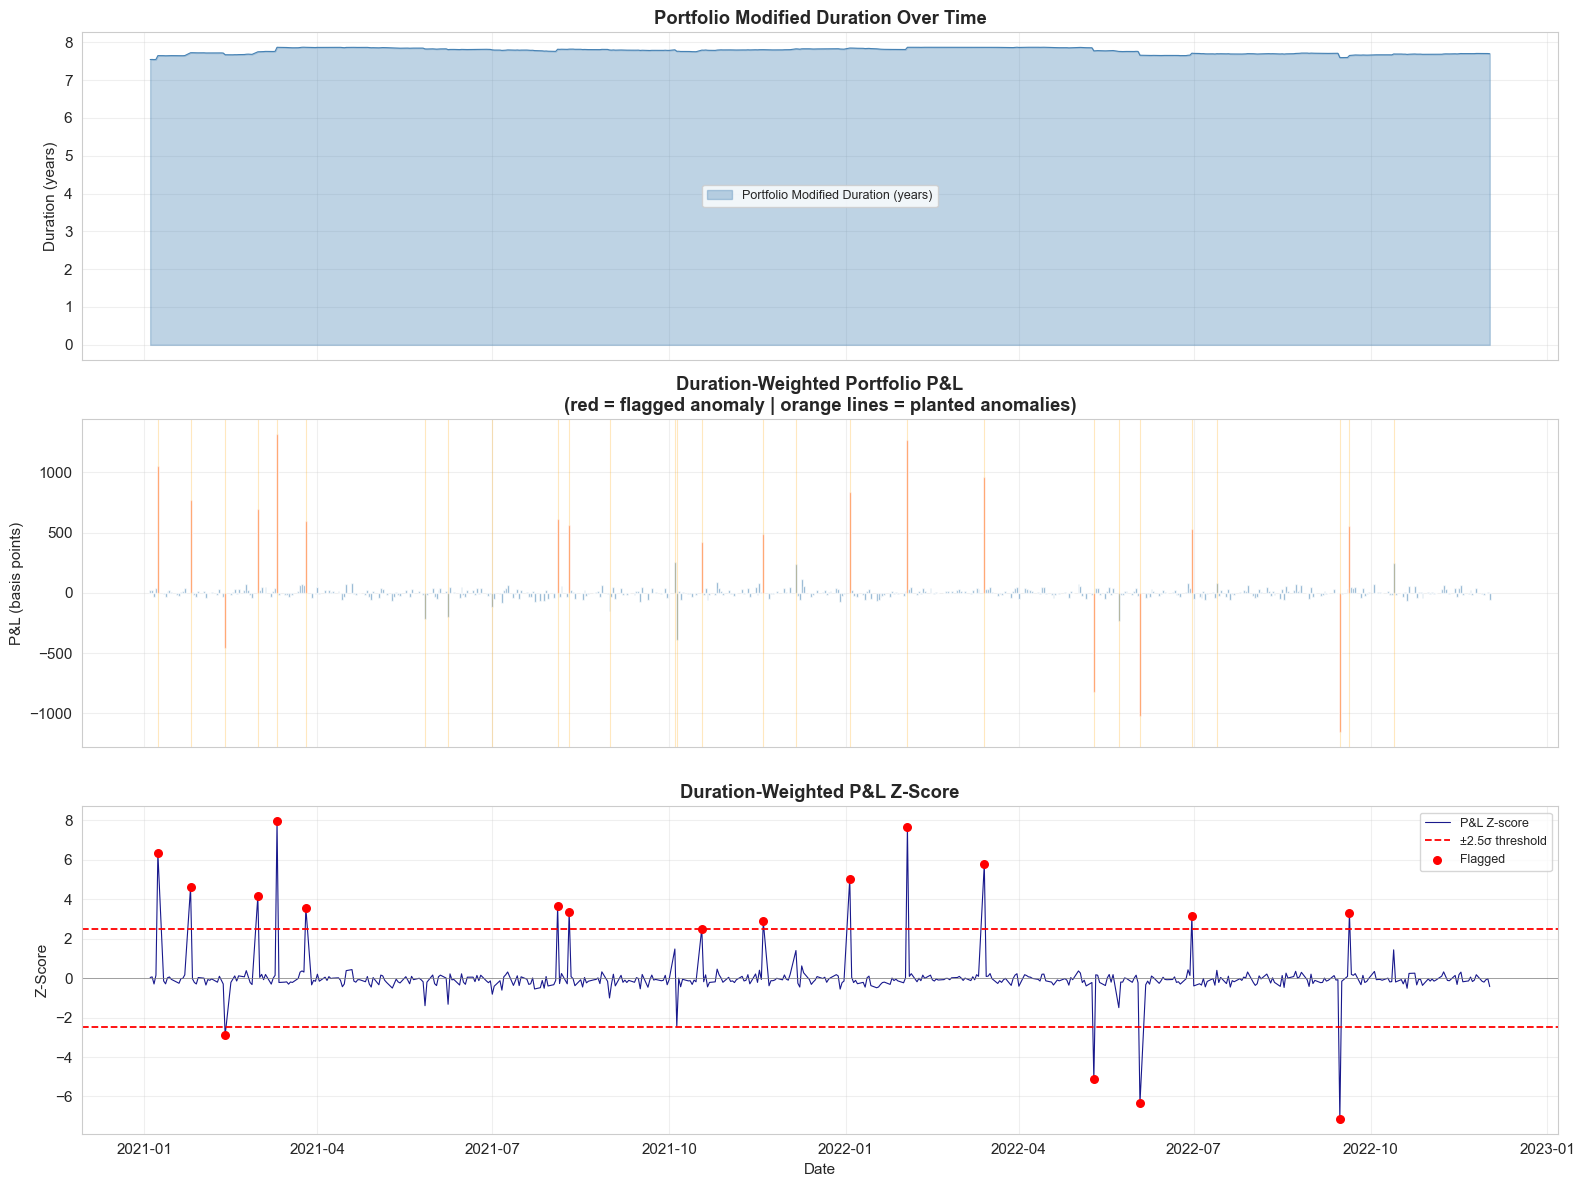


Method                                       Precision   Recall      F1  Flagged
--------------------------------------------------------------------------
PCA Factor Anomaly (Mahalanobis)                 1.000    1.000   1.000       28
Nelson-Siegel Residual RMSE                      0.000    0.000   0.000        0
Nelson-Siegel Parameter Jump                     0.962    0.893   0.926       26
Duration-Weighted P&L Z-Score                    1.000    0.643   0.783       18

Ground truth: 28 anomalous days (5.6%)
  — 10 Parallel shocks | 10 Curve twists | 8 Belly anomalies


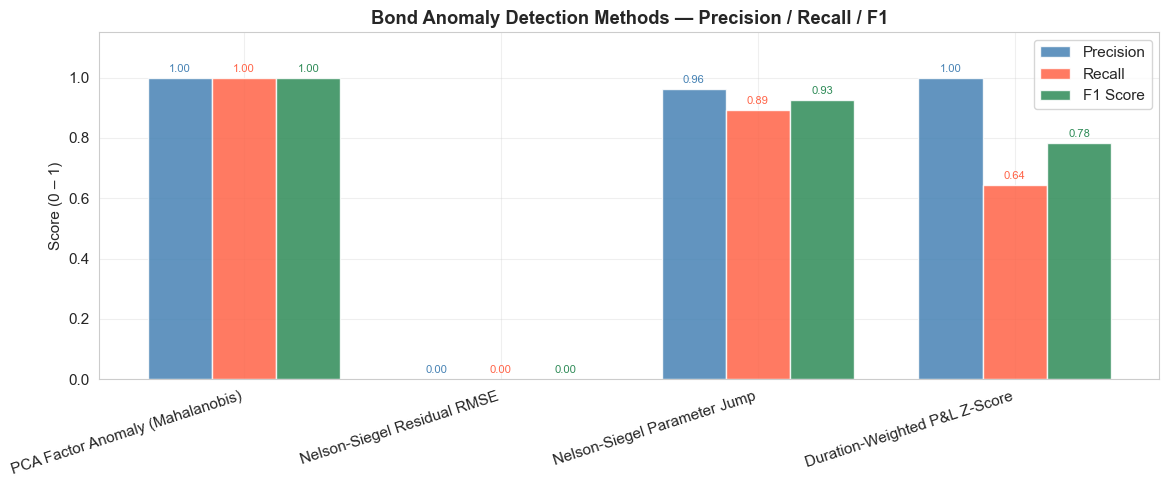

In [20]:

# ── Modified Duration of zero-coupon bond: D_mod = T / (1 + y_T) ─────────────
# The longer the maturity, the larger the duration — and the bigger the P&L
# impact of any yield move.  DV01 = D_mod × 0.0001  (P&L per $1 face per 1bp)
# Portfolio P&L approximation: ΔP ≈ −D_mod × Δy  (equal-weight across tenors)

d_mod_mat = np.zeros((N_BOND_DAYS, N_MAT))
for t in range(N_BOND_DAYS):
    for m_idx, mat in enumerate(MATURITIES):
        d_mod_mat[t, m_idx] = mat / (1 + bond_yields[t, m_idx])

# Equal-weight portfolio: average D_mod-weighted P&L across tenors
dur_pnl    = -np.sum(d_mod_mat * yield_chg, axis=1) / N_MAT   # (N_BOND_DAYS,)
dur_pnl_bp = dur_pnl * 10_000                                  # convert to basis points
ptf_dur    = d_mod_mat.mean(axis=1)                            # portfolio duration (years)

# Flag via Z-score
dur_z     = (dur_pnl - dur_pnl.mean()) / dur_pnl.std()
dur_flags = (np.abs(dur_z) > 2.5).astype(int)

bond_results.append(bond_eval("Duration-Weighted P&L Z-Score", dur_flags, bond_y_true))

# ── Visualise Duration Method ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

ax = axes[0]
ax.fill_between(bond_dates, ptf_dur, color='steelblue', alpha=0.35,
                label='Portfolio Modified Duration (years)')
ax.plot(bond_dates, ptf_dur, color='steelblue', linewidth=0.8)
ax.set_ylabel('Duration (years)')
ax.set_title('Portfolio Modified Duration Over Time', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
bar_colours = ['tomato' if abs(z) > 2.5 else 'steelblue' for z in dur_z]
ax.bar(bond_dates, dur_pnl_bp, color=bar_colours, alpha=0.75, width=1.0)
for d in np.where(bond_y_true)[0]:
    ax.axvline(bond_dates[d], color='orange', alpha=0.25, linewidth=0.8)
ax.set_ylabel('P&L (basis points)')
ax.set_title('Duration-Weighted Portfolio P&L\n'
             '(red = flagged anomaly | orange lines = planted anomalies)',
             fontweight='bold')
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(bond_dates, dur_z, color='navy', linewidth=0.8, alpha=0.9, label='P&L Z-score')
ax.axhline( 2.5, color='red', linestyle='--', linewidth=1.3, label='±2.5σ threshold')
ax.axhline(-2.5, color='red', linestyle='--', linewidth=1.3)
ax.axhline(0,    color='grey', linewidth=0.5)
ax.scatter(bond_dates[dur_flags.astype(bool)], dur_z[dur_flags.astype(bool)],
           color='red', s=30, zorder=5, label='Flagged')
ax.set_ylabel('Z-Score'); ax.set_xlabel('Date')
ax.set_title('Duration-Weighted P&L Z-Score', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# ── Bond Methods Comparison ───────────────────────────────────────────────────
print("\n" + "=" * 74)
print(f"{'Method':<44s} {'Precision':>9s} {'Recall':>8s} {'F1':>7s} {'Flagged':>8s}")
print("-" * 74)
for r in bond_results:
    print(f"{r['Method']:<44s} {r['Precision']:>9.3f} {r['Recall']:>8.3f} "
          f"{r['F1']:>7.3f} {r['Flagged']:>8d}")
print("=" * 74)
print(f"\nGround truth: {bond_y_true.sum()} anomalous days ({bond_y_true.mean()*100:.1f}%)")
print(f"  — {len(shock_days)} Parallel shocks | "
      f"{len(twist_days)} Curve twists | "
      f"{len(belly_days)} Belly anomalies")

# ── Comparison bar chart ──────────────────────────────────────────────────────
bond_df = pd.DataFrame(bond_results)
x_pos   = np.arange(len(bond_df))
width   = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - width, bond_df['Precision'], width, color='steelblue',
       alpha=0.85, label='Precision')
ax.bar(x_pos,         bond_df['Recall'],    width, color='tomato',
       alpha=0.85, label='Recall')
ax.bar(x_pos + width, bond_df['F1'],        width, color='seagreen',
       alpha=0.85, label='F1 Score')
ax.set_xticks(x_pos)
ax.set_xticklabels(bond_df['Method'], rotation=18, ha='right')
ax.set_ylabel('Score (0 – 1)')
ax.set_ylim(0, 1.15)
ax.set_title('Bond Anomaly Detection Methods — Precision / Recall / F1',
             fontweight='bold')
for i, row in bond_df.iterrows():
    ax.text(i - width, row['Precision'] + 0.02, f"{row['Precision']:.2f}",
            ha='center', fontsize=8, color='steelblue')
    ax.text(i,         row['Recall']    + 0.02, f"{row['Recall']:.2f}",
            ha='center', fontsize=8, color='tomato')
    ax.text(i + width, row['F1']        + 0.02, f"{row['F1']:.2f}",
            ha='center', fontsize=8, color='seagreen')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Fixed Income Bonds — Machine Learning Approaches

> **In plain English:** The statistical methods in Section 13 (PCA Mahalanobis, Nelson-Siegel parameter jump, Duration-weighted P&L) encode decades of fixed income knowledge into their design. They are powerful but they make assumptions — about linearity, about distributions, about what counts as "normal". Machine learning methods make fewer assumptions and can find patterns the human-designed detectors miss. The trade-off is interpretability and data requirements.

---

### Why apply ML to bonds specifically?

When you apply ML to equity returns, every feature (daily stock return) is on the same scale and has the same interpretation. Bonds are trickier:

| Challenge | Impact on ML |
|-----------|-------------|
| **10 correlated features** (one per tenor) | IF and LOF see redundant dimensions; PCA pre-processing helps enormously |
| **Term structure** (short vs long maturity) | A 5Y yield change and a 10Y change are correlated but not identical; ML must learn this |
| **Small datasets** | Yield curve data is typically 2–5 years daily → 500–1250 rows. Neural networks need careful regularisation |
| **Non-stationary** | Yields drift over cycles; train/test split matters more than for equities |

> **Key principle:** Apply PCA *before* ML. Compress the 10 tenor features into 3 independent factors (Level, Slope, Curvature). This gives ML methods a cleaner, lower-dimensional space to work in — and they consistently perform better.

---

### Three ML methods covered in this section

| # | Method | Complexity | Core idea | Best for |
|---|--------|-----------|-----------|----------|
| **14A** | **Isolation Forest** | ⭐ Simple | Anomalies are isolated quickly by random splits | First ML layer — fast, robust, no distributional assumptions |
| **14B** | **Local Outlier Factor (LOF)** | ⭐⭐ Intermediate | Anomalies are less dense than their neighbours | Local cluster anomalies; belly dislocations within a regime |
| **14C** | **Autoencoder (Neural Network)** | ⭐⭐⭐ Advanced | Learn to reconstruct normal curves; anomalies = high error | Subtle curve deformations invisible to linear methods |

---

### Concept: What is a "bottleneck" in a neural network?

The autoencoder in Cell 14C uses a **bottleneck architecture**. Here is the idea in plain text:

```
Normal yield curve (10 numbers: 3M, 6M, 1Y ... 30Y)
        ↓
ENCODER: Dense(6) → Dense(3)    ← forces the 10 numbers into just 3
        ↓
BOTTLENECK: 3 nodes             ← these 3 numbers summarise the whole curve
        ↓                          They independently learn Level, Slope, Curvature
DECODER: Dense(6) → Dense(10)   ← expands the 3 numbers back to all 10 tenors
        ↓
Reconstructed yield curve (10 numbers)
```

Training: show only **normal days** and say *"output must equal input"*.
Anomaly detection: on a new day, measure **reconstruction error** (how different is the output from the input). Normal days → small error. Anomaly days → large error.

> This is exactly the same idea as Section 10 (Autoencoder on equity returns), applied to the yield curve. The key difference is that yield curve data is smaller (500 rows vs 1000), so the network architecture must be simpler.

---

### A note on data leakage — the most common ML mistake in finance

> **Data leakage** means accidentally giving the model information it would not have in production.
>
> For anomaly detection, the most common leak is: **fitting the scaler or the model on data that contains anomalies**.
>
> - If you fit `StandardScaler` on all 500 days including anomalous days, the anomalous days shift the mean and standard deviation, making the model think "anomalous moves are part of normal".
> - The fix: fit *all* preprocessing (scaler, PCA, autoencoder) only on **normal training data**, then transform the full dataset.
>
> This section follows this rule throughout.

### Beginner Explanation

This section extends anomaly detection in bonds from hand-designed statistical tools to machine-learning methods. The idea is similar to the equity case, but the inputs now represent the shape of the yield curve rather than a basket of stock returns.

For a beginner, the main takeaway is that PCA is especially useful here because it compresses many related maturities into a few cleaner curve factors before the ML models try to detect anomalies.

True anomaly rate in bond data: 5.6%
Using this as the contamination parameter for IF.
(In production without ground truth, start with 0.05 and tune)
Isolation Forest (10D raw)                 Precision=1.000  Recall=1.000  F1=1.000  Flagged=28
Isolation Forest (3D PCA)                  Precision=1.000  Recall=1.000  F1=1.000  Flagged=28

IF (3D PCA) detection rate by anomaly type:
  Parallel Shock      : 10/10 detected (100%)
  Curve Twist         : 10/10 detected (100%)
  Belly Anomaly       : 8/8 detected (100%)


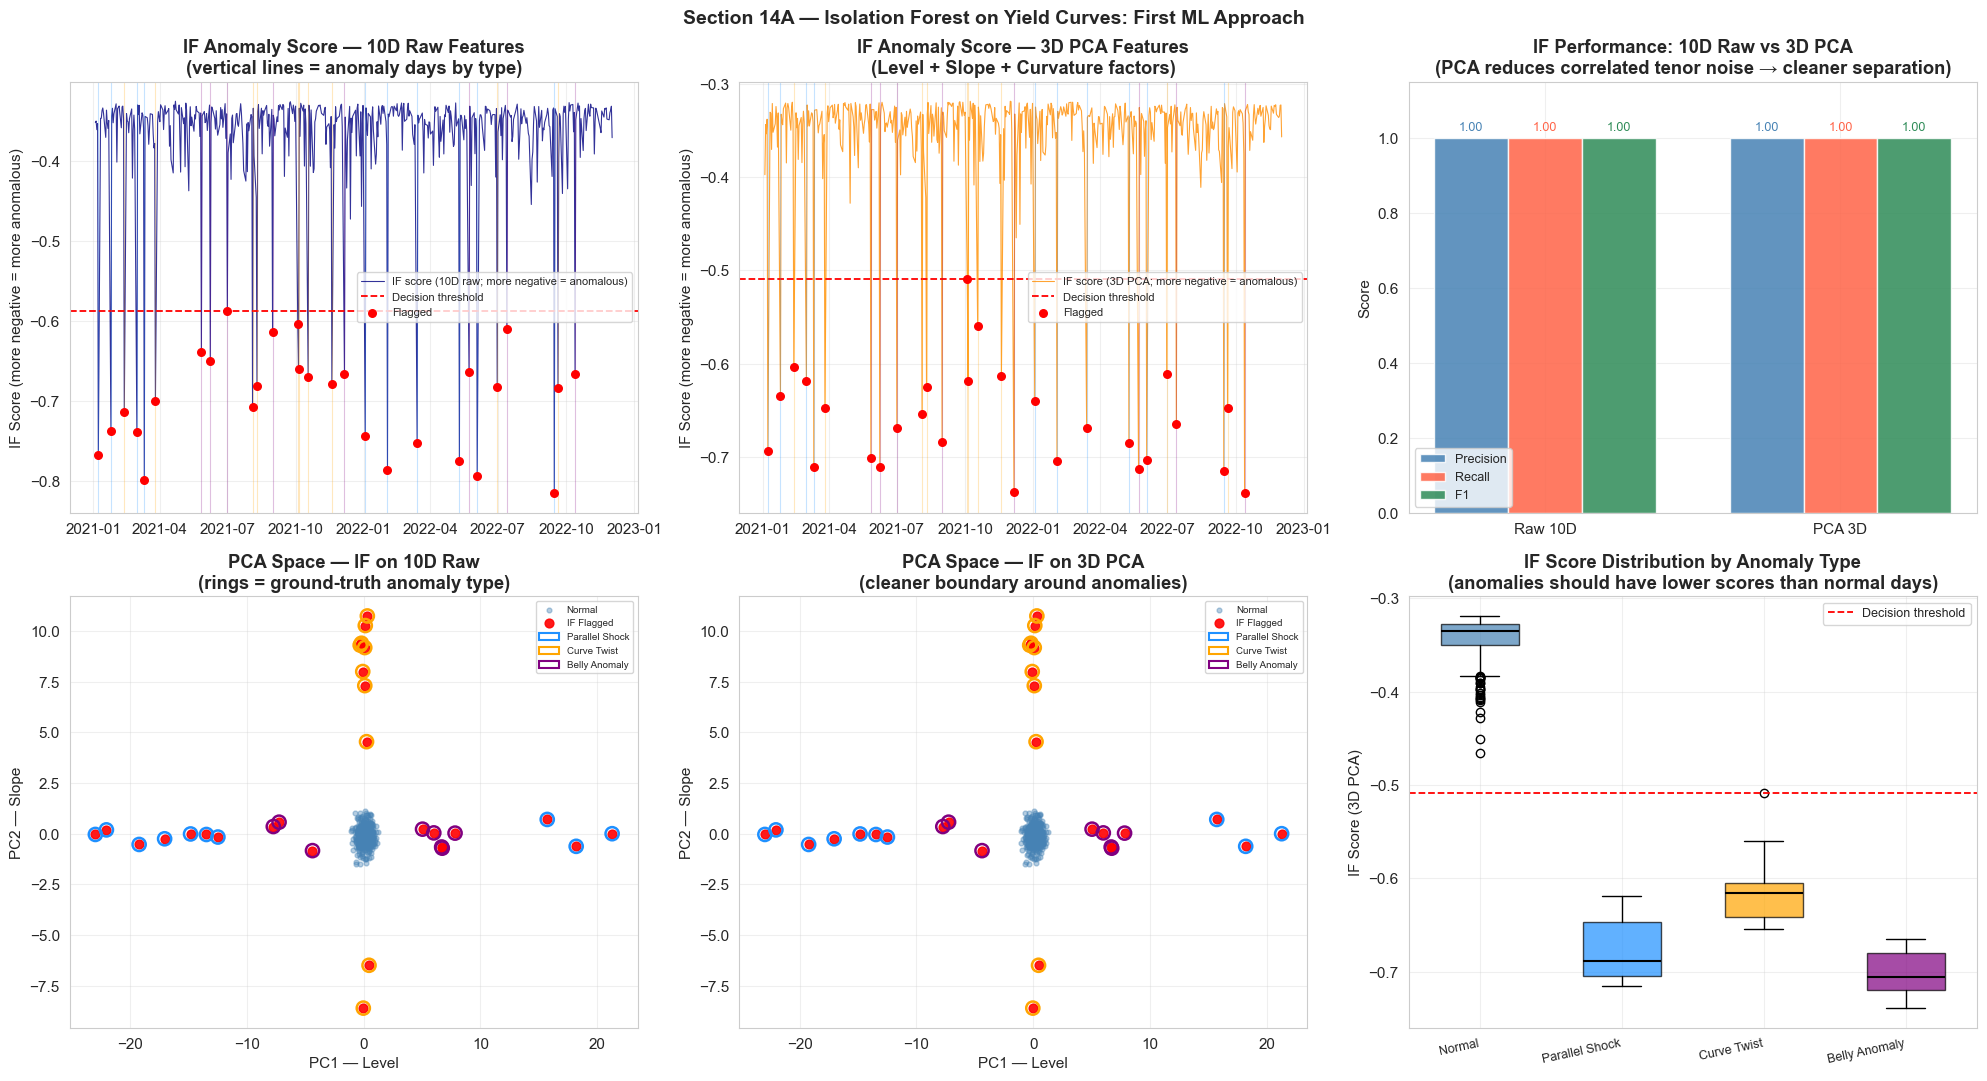


────────────────────────────────────────────────────────────
Version                          Prec    Rec     F1
────────────────────────────────────────────────────────────
IF — 10D raw                    1.000  1.000  1.000
IF — 3D PCA                     1.000  1.000  1.000

Takeaway: PCA pre-processing compresses 10 correlated tenor features into
3 independent factors. Isolation Forest works better in this cleaner space.


In [27]:

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 14A — Isolation Forest on Yield Curves: The Simplest ML Approach
# ══════════════════════════════════════════════════════════════════════════════
#
# BEGINNER RECAP — How Isolation Forest works:
# ─────────────────────────────────────────────
# 1. Build 100–300 random decision trees.  Each tree randomly picks a feature
#    (e.g., the 5Y tenor) and a random split value (e.g., yield_chg_5Y > 0.004).
# 2. It keeps splitting until it has ISOLATED one point from all others.
# 3. Anomalies need very FEW splits to isolate — they're already far from the crowd.
#    Normal points need MANY splits — they're buried in a dense cluster.
# 4. Anomaly score = average depth across all trees (normalised to -1…0 range).
#    More negative = anomalous.  The score_samples() method returns this.
# 5. predict() returns +1 (normal) or -1 (anomaly).
#
# Applied to yield curves — two versions:
#   Version A: feed the model all 10 tenor yield changes (10-dimensional space).
#   Version B: first run PCA to compress to 3 factors (Level, Slope, Curvature).
#             Then feed the model those 3 numbers.
#   Why two versions? PCA removes correlation between tenors and reduces noise.
#   With 10 correlated features, IF sometimes gets confused — it splits the
#   same "underlying direction" multiple times in different tenors.
#   With 3 independent PCA factors, the task is cleaner.
#
# Key hyperparameter — contamination:
#   This tells IF what fraction of data to label as anomalous.
#   In practice: start with the known/estimated anomaly rate.
#   Here we know the true rate from the data generation step.
# ──────────────────────────────────────────────────────────────────────────────

# Note: IsolationForest, f1_score, precision_score, recall_score already imported

import matplotlib.patches as mpatches   # for custom legend handles (ring patches)

# ── Step 1: Contamination rate ────────────────────────────────────────────────
TRUE_CONT_B = bond_y_true.mean()
print(f"True anomaly rate in bond data: {TRUE_CONT_B * 100:.1f}%")
print(f"Using this as the contamination parameter for IF.")
print(f"(In production without ground truth, start with 0.05 and tune)")

# ── Step 2a: IF on 10D standardised yield changes ────────────────────────────
# yield_chg_sc: shape (N_BOND_DAYS, 10) — each column is one tenor, all standardised.
# Standardisation is important: without it, the 30Y column (larger absolute moves)
# dominates the random splits and drowns out the shorter tenors.
iso_yc_raw = IsolationForest(
    n_estimators=300,             # more trees = more stable score
    contamination=TRUE_CONT_B,    # expected fraction of anomalies
    random_state=42               # reproducibility
)
iso_yc_raw.fit(yield_chg_sc)
iso_raw_scores = iso_yc_raw.score_samples(yield_chg_sc)   # more negative → more anomalous
iso_raw_flags  = (iso_yc_raw.predict(yield_chg_sc) == -1).astype(int)

# ── Step 2b: IF on 3D PCA scores (Level, Slope, Curvature) ──────────────────
# yc_scores: already computed in Section 13 PCA cell — shape (N_BOND_DAYS, 3)
# 3 independent factors instead of 10 correlated tenors → cleaner feature space
iso_yc_pca = IsolationForest(
    n_estimators=300,
    contamination=TRUE_CONT_B,
    random_state=42
)
iso_yc_pca.fit(yc_scores)
iso_pca_scores = iso_yc_pca.score_samples(yc_scores)
iso_pca_flags  = (iso_yc_pca.predict(yc_scores) == -1).astype(int)

# ── Step 3: Metrics ────────────────────────────────────────────────────────────
f1_raw  = f1_score(bond_y_true, iso_raw_flags,  zero_division=0)
f1_pca3 = f1_score(bond_y_true, iso_pca_flags,  zero_division=0)
pr_raw  = precision_score(bond_y_true, iso_raw_flags,  zero_division=0)
pr_pca3 = precision_score(bond_y_true, iso_pca_flags,  zero_division=0)
re_raw  = recall_score(bond_y_true, iso_raw_flags,  zero_division=0)
re_pca3 = recall_score(bond_y_true, iso_pca_flags,  zero_division=0)

bond_results.append(bond_eval("Isolation Forest (10D raw)",  iso_raw_flags,  bond_y_true))
bond_results.append(bond_eval("Isolation Forest (3D PCA)",   iso_pca_flags,  bond_y_true))

# ── Step 4: Detection breakdown by anomaly type ───────────────────────────────
print("\nIF (3D PCA) detection rate by anomaly type:")
for aname, days in [("Parallel Shock", shock_days),
                    ("Curve Twist",    twist_days),
                    ("Belly Anomaly",  belly_days)]:
    n_det = sum(iso_pca_flags[d] for d in days)
    print(f"  {aname:<20s}: {n_det}/{len(days)} detected ({n_det/len(days)*100:.0f}%)")

# ── Step 5: Visualise ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Section 14A — Isolation Forest on Yield Curves: First ML Approach',
             fontsize=14, fontweight='bold')

# ── Panel 1: IF score over time — 10D raw ─────────────────────────────────
ax = axes[0, 0]
ax.plot(bond_dates, iso_raw_scores, color='navy', linewidth=0.8, alpha=0.8,
        label='IF score (10D raw; more negative = anomalous)')
thr_raw = iso_raw_scores[iso_raw_flags == 1].max() if iso_raw_flags.sum() > 0 else -0.5
ax.axhline(thr_raw, color='red', linestyle='--', linewidth=1.3, label='Decision threshold')
ax.scatter(bond_dates[iso_raw_flags.astype(bool)], iso_raw_scores[iso_raw_flags.astype(bool)],
           color='red', s=30, zorder=5, label='Flagged')
for d, atype in bond_anomaly_types.items():
    ax.axvline(bond_dates[d], color=colour_map_type[atype], alpha=0.25, linewidth=0.8)
ax.set_title('IF Anomaly Score — 10D Raw Features\n(vertical lines = anomaly days by type)',
             fontweight='bold')
ax.set_ylabel('IF Score (more negative = more anomalous)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 2: IF score over time — 3D PCA ──────────────────────────────────
ax = axes[0, 1]
ax.plot(bond_dates, iso_pca_scores, color='darkorange', linewidth=0.8, alpha=0.8,
        label='IF score (3D PCA; more negative = anomalous)')
thr_pca = iso_pca_scores[iso_pca_flags == 1].max() if iso_pca_flags.sum() > 0 else -0.5
ax.axhline(thr_pca, color='red', linestyle='--', linewidth=1.3, label='Decision threshold')
ax.scatter(bond_dates[iso_pca_flags.astype(bool)], iso_pca_scores[iso_pca_flags.astype(bool)],
           color='red', s=30, zorder=5, label='Flagged')
for d, atype in bond_anomaly_types.items():
    ax.axvline(bond_dates[d], color=colour_map_type[atype], alpha=0.25, linewidth=0.8)
ax.set_title('IF Anomaly Score — 3D PCA Features\n(Level + Slope + Curvature factors)',
             fontweight='bold')
ax.set_ylabel('IF Score (more negative = more anomalous)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: F1 bar chart — 10D vs 3D PCA ──────────────────────────────────
ax = axes[0, 2]
x_if = np.arange(2); w_if = 0.25
ax.bar(x_if - w_if, [pr_raw, pr_pca3], w_if, color='steelblue', alpha=0.85, label='Precision')
ax.bar(x_if,        [re_raw, re_pca3], w_if, color='tomato',    alpha=0.85, label='Recall')
ax.bar(x_if + w_if, [f1_raw, f1_pca3], w_if, color='seagreen',  alpha=0.85, label='F1')
ax.set_xticks(x_if); ax.set_xticklabels(['Raw 10D', 'PCA 3D'])
for i, (p, r, f) in enumerate(zip([pr_raw, pr_pca3], [re_raw, re_pca3], [f1_raw, f1_pca3])):
    ax.text(i - w_if, p + 0.02, f'{p:.2f}', ha='center', fontsize=9, color='steelblue')
    ax.text(i,        r + 0.02, f'{r:.2f}', ha='center', fontsize=9, color='tomato')
    ax.text(i + w_if, f + 0.02, f'{f:.2f}', ha='center', fontsize=9, color='seagreen')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('IF Performance: 10D Raw vs 3D PCA\n'
             '(PCA reduces correlated tenor noise → cleaner separation)',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 4: PCA scatter — IF 10D flags ───────────────────────────────────
ax = axes[1, 0]
ax.scatter(yc_scores[iso_raw_flags == 0, 0], yc_scores[iso_raw_flags == 0, 1],
           color='steelblue', s=12, alpha=0.4, label='Normal')
ax.scatter(yc_scores[iso_raw_flags == 1, 0], yc_scores[iso_raw_flags == 1, 1],
           color='red', s=40, alpha=0.9, zorder=5, label='IF Flagged')
for d, atype in bond_anomaly_types.items():
    ax.scatter(yc_scores[d, 0], yc_scores[d, 1], facecolors='none',
               edgecolors=colour_map_type[atype], s=90, linewidth=1.8, zorder=6)
ax.set_xlabel('PC1 — Level'); ax.set_ylabel('PC2 — Slope')
ax.set_title('PCA Space — IF on 10D Raw\n(rings = ground-truth anomaly type)', fontweight='bold')
leg_p = [mpatches.Patch(edgecolor=c, facecolor='none', label=t, linewidth=1.5)
         for t, c in colour_map_type.items()]
ax.legend(handles=[*ax.get_legend_handles_labels()[0], *leg_p], fontsize=7); ax.grid(alpha=0.3)

# ── Panel 5: PCA scatter — IF PCA flags ───────────────────────────────────
ax = axes[1, 1]
ax.scatter(yc_scores[iso_pca_flags == 0, 0], yc_scores[iso_pca_flags == 0, 1],
           color='steelblue', s=12, alpha=0.4, label='Normal')
ax.scatter(yc_scores[iso_pca_flags == 1, 0], yc_scores[iso_pca_flags == 1, 1],
           color='red', s=40, alpha=0.9, zorder=5, label='IF Flagged')
for d, atype in bond_anomaly_types.items():
    ax.scatter(yc_scores[d, 0], yc_scores[d, 1], facecolors='none',
               edgecolors=colour_map_type[atype], s=90, linewidth=1.8, zorder=6)
ax.set_xlabel('PC1 — Level'); ax.set_ylabel('PC2 — Slope')
ax.set_title('PCA Space — IF on 3D PCA\n(cleaner boundary around anomalies)', fontweight='bold')
ax.legend(handles=[*ax.get_legend_handles_labels()[0], *leg_p], fontsize=7); ax.grid(alpha=0.3)

# ── Panel 6: IF score distribution by anomaly type ────────────────────────
ax = axes[1, 2]
groups_if = [
    ('Normal',          iso_pca_scores[bond_y_true == 0],                        'steelblue'),
    ('Parallel Shock',  np.array([iso_pca_scores[d] for d in shock_days]),        'dodgerblue'),
    ('Curve Twist',     np.array([iso_pca_scores[d] for d in twist_days]),        'orange'),
    ('Belly Anomaly',   np.array([iso_pca_scores[d] for d in belly_days]),        'purple'),
]
bp = ax.boxplot([g[1] for g in groups_if], positions=range(4), patch_artist=True,
                widths=0.55, medianprops=dict(color='black', linewidth=1.5))
for patch, (_, _, c) in zip(bp['boxes'], groups_if):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.axhline(thr_pca, color='red', linestyle='--', linewidth=1.3, label='Decision threshold')
ax.set_xticks(range(4)); ax.set_xticklabels([g[0] for g in groups_if],
                                             rotation=12, ha='right', fontsize=9)
ax.set_ylabel('IF Score (3D PCA)')
ax.set_title('IF Score Distribution by Anomaly Type\n'
             '(anomalies should have lower scores than normal days)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'─'*60}")
print(f"{'Version':<30s} {'Prec':>6s} {'Rec':>6s} {'F1':>6s}")
print(f"{'─'*60}")
print(f"{'IF — 10D raw':<30s} {pr_raw:>6.3f} {re_raw:>6.3f} {f1_raw:>6.3f}")
print(f"{'IF — 3D PCA':<30s} {pr_pca3:>6.3f} {re_pca3:>6.3f} {f1_pca3:>6.3f}")
print(f"\nTakeaway: PCA pre-processing compresses 10 correlated tenor features into")
print(f"3 independent factors. Isolation Forest works better in this cleaner space.")


LOF (20 neighbours, 10D raw)               Precision=1.000  Recall=1.000  F1=1.000  Flagged=28
LOF (20 neighbours, 3D PCA)                Precision=1.000  Recall=1.000  F1=1.000  Flagged=28
LOF (3D PCA) detection rate by anomaly type:
  Parallel Shock      : 10/10 detected (100%)
  Curve Twist         : 10/10 detected (100%)
  Belly Anomaly       : 8/8 detected (100%)


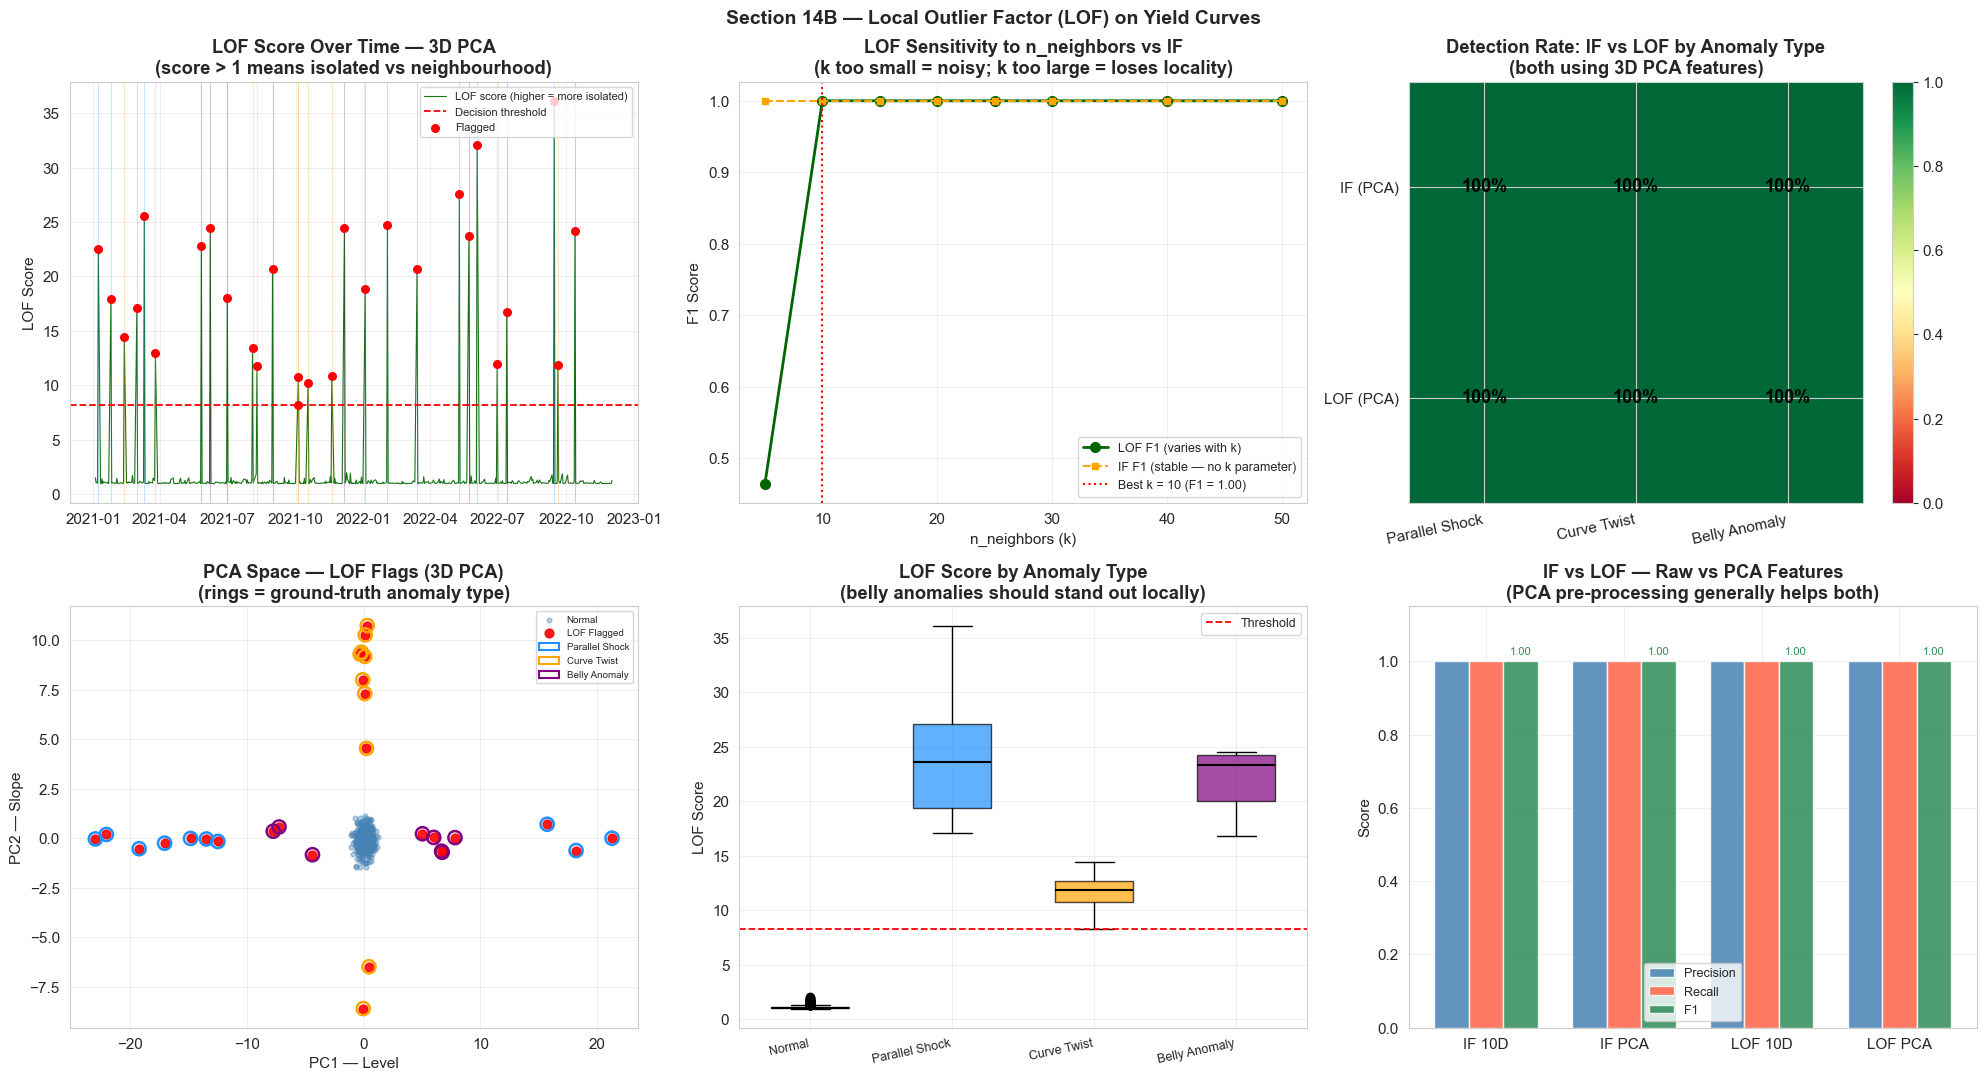


Conclusion — LOF vs IF for fixed income:
  IF advantage:  simpler, faster, not sensitive to k, handles global outliers well
  LOF advantage: adapts to local density; better for regime-specific anomalies
  Both benefit from PCA pre-processing (10D → 3D reduces noise from correlated tenors)


In [28]:

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 14B — Local Outlier Factor (LOF): Neighbourhood-Based Anomaly Detection
# ══════════════════════════════════════════════════════════════════════════════
#
# BEGINNER EXPLANATION — How LOF works:
# ──────────────────────────────────────
# Isolation Forest flags points that are globally isolated.
# LOF asks a different question: "Is this point isolated relative to ITS NEIGHBOURS?"
#
# Step-by-step:
#   1. For each point, find its k nearest neighbours (default k = 20).
#   2. Measure the LOCAL DENSITY around that point
#      (how close are its k neighbours on average?).
#   3. Compare its density to the density of its neighbours.
#      If its neighbourhood is much SPARSER than its neighbours' neighbourhoods,
#      the point is a LOCAL OUTLIER — its LOF score >> 1.
#
# Why this matters for yield curves:
#   The yield curve has "regimes" — a tightening cycle looks different from an
#   easing cycle. LOF is LOCAL, so it compares each day to similar-regime days,
#   not to the global average. This makes it better at spotting anomalies
#   within a specific market environment (e.g., a belly move during a hike cycle).
#
# LOF score interpretation:
#   Score ≈ 1.0  → this point is as dense as its neighbourhood → normal
#   Score > 1.5  → this point is in a sparser zone than its neighbours → suspicious
#   Score >> 1.0 → clear outlier
#
# Key hyperparameter: n_neighbors (k)
#   Too small (k=3): very sensitive to noise, many false positives
#   Too large (k=50): loses locality, misses local anomalies
#   Sweet spot: k=15–30 for typical financial time series
# ──────────────────────────────────────────────────────────────────────────────

from sklearn.neighbors import LocalOutlierFactor

# ── Step 1: LOF on 3D PCA scores (Level, Slope, Curvature) ──────────────────
# novelty=False → batch mode: fit and score on the same dataset.
# contamination → sets the threshold percentile that separates normal from anomalous.
lof_pca = LocalOutlierFactor(
    n_neighbors=20,
    contamination=bond_y_true.mean(),   # use true rate as guide
    novelty=False
)
lof_pca_pred   = lof_pca.fit_predict(yc_scores)      # -1 = anomaly, +1 = normal
lof_pca_flags  = (lof_pca_pred == -1).astype(int)
lof_pca_scores = -lof_pca.negative_outlier_factor_   # invert sign: higher = more anomalous

# ── Step 2: LOF on 10D raw standardised yield changes ───────────────────────
lof_raw = LocalOutlierFactor(
    n_neighbors=20,
    contamination=bond_y_true.mean(),
    novelty=False
)
lof_raw_pred   = lof_raw.fit_predict(yield_chg_sc)
lof_raw_flags  = (lof_raw_pred == -1).astype(int)
lof_raw_scores = -lof_raw.negative_outlier_factor_

lof_f1_pca  = f1_score(bond_y_true, lof_pca_flags, zero_division=0)
lof_pr_pca  = precision_score(bond_y_true, lof_pca_flags, zero_division=0)
lof_re_pca  = recall_score(bond_y_true, lof_pca_flags, zero_division=0)
lof_f1_raw  = f1_score(bond_y_true, lof_raw_flags, zero_division=0)
lof_pr_raw  = precision_score(bond_y_true, lof_raw_flags, zero_division=0)
lof_re_raw  = recall_score(bond_y_true, lof_raw_flags, zero_division=0)

bond_results.append(bond_eval("LOF (20 neighbours, 10D raw)", lof_raw_flags, bond_y_true))
bond_results.append(bond_eval("LOF (20 neighbours, 3D PCA)",  lof_pca_flags, bond_y_true))

# ── Step 3: n_neighbors sensitivity sweep ────────────────────────────────────
# In production you would cross-validate this. Here we sweep to see the effect.
k_range    = [5, 10, 15, 20, 25, 30, 40, 50]
f1_lof_k   = []
f1_if_k    = []   # for comparison: IF is NOT sensitive to this hyperparameter
for k in k_range:
    _lof   = LocalOutlierFactor(n_neighbors=k, contamination=bond_y_true.mean(), novelty=False)
    _flags = (_lof.fit_predict(yc_scores) == -1).astype(int)
    f1_lof_k.append(f1_score(bond_y_true, _flags, zero_division=0))
    # IF doesn't have an analogous k — its F1 stays flat
    f1_if_k.append(f1_score(bond_y_true, iso_pca_flags, zero_division=0))

# ── Step 4: Detection by anomaly type ────────────────────────────────────────
days_by_type = {
    'Parallel Shock': shock_days,
    'Curve Twist':    twist_days,
    'Belly Anomaly':  belly_days
}
print("LOF (3D PCA) detection rate by anomaly type:")
for atype_name, days in days_by_type.items():
    n_det = sum(lof_pca_flags[d] for d in days)
    print(f"  {atype_name:<20s}: {n_det}/{len(days)} detected ({n_det/len(days)*100:.0f}%)")

# ── Step 5: Visualise ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Section 14B — Local Outlier Factor (LOF) on Yield Curves',
             fontsize=14, fontweight='bold')

# ── Panel 1: LOF score over time ───────────────────────────────────────────
ax = axes[0, 0]
ax.plot(bond_dates, lof_pca_scores, color='darkgreen', linewidth=0.8, alpha=0.9,
        label='LOF score (higher = more isolated)')
thr_lof = lof_pca_scores[lof_pca_flags == 1].min() if lof_pca_flags.sum() > 0 else 1.5
ax.axhline(thr_lof, color='red', linestyle='--', linewidth=1.3, label='Decision threshold')
ax.scatter(bond_dates[lof_pca_flags.astype(bool)], lof_pca_scores[lof_pca_flags.astype(bool)],
           color='red', s=30, zorder=5, label='Flagged')
for d, atype in bond_anomaly_types.items():
    ax.axvline(bond_dates[d], color=colour_map_type[atype], alpha=0.25, linewidth=0.8)
ax.set_title('LOF Score Over Time — 3D PCA\n(score > 1 means isolated vs neighbourhood)',
             fontweight='bold')
ax.set_ylabel('LOF Score'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 2: n_neighbors sensitivity ──────────────────────────────────────
ax = axes[0, 1]
ax.plot(k_range, f1_lof_k, 'o-', color='darkgreen', linewidth=2, markersize=7,
        label='LOF F1 (varies with k)')
ax.plot(k_range, f1_if_k,  's--', color='orange', linewidth=1.5, markersize=5,
        label='IF F1 (stable — no k parameter)')
best_k_idx = int(np.argmax(f1_lof_k))
ax.axvline(k_range[best_k_idx], color='red', linestyle=':',
           label=f'Best k = {k_range[best_k_idx]} (F1 = {f1_lof_k[best_k_idx]:.2f})')
ax.set_xlabel('n_neighbors (k)')
ax.set_ylabel('F1 Score')
ax.set_title('LOF Sensitivity to n_neighbors vs IF\n(k too small = noisy; k too large = loses locality)',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 3: Detection-rate heatmap — IF vs LOF by anomaly type ──────────
ax = axes[0, 2]
methods_h = ['IF (PCA)', 'LOF (PCA)']
flags_h   = [iso_pca_flags, lof_pca_flags]
types_h   = list(days_by_type.keys())
det_mat   = np.zeros((2, 3))
for i, flags in enumerate(flags_h):
    for j, atype in enumerate(types_h):
        det_mat[i, j] = sum(flags[d] for d in days_by_type[atype]) / len(days_by_type[atype])
im = ax.imshow(det_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(types_h, rotation=12, ha='right')
ax.set_yticks(range(2)); ax.set_yticklabels(methods_h)
for i in range(2):
    for j in range(3):
        ax.text(j, i, f'{det_mat[i,j]*100:.0f}%', ha='center', va='center',
                fontsize=13, fontweight='bold',
                color='white' if det_mat[i, j] < 0.45 else 'black')
ax.set_title('Detection Rate: IF vs LOF by Anomaly Type\n(both using 3D PCA features)',
             fontweight='bold')
plt.colorbar(im, ax=ax)

# ── Panel 4: PCA scatter — LOF flags ──────────────────────────────────────
ax = axes[1, 0]
norm_l = lof_pca_flags == 0
flag_l = lof_pca_flags == 1
ax.scatter(yc_scores[norm_l, 0], yc_scores[norm_l, 1], color='steelblue', s=12,
           alpha=0.4, label='Normal')
ax.scatter(yc_scores[flag_l, 0], yc_scores[flag_l, 1], color='red', s=40,
           alpha=0.9, zorder=5, label='LOF Flagged')
for d, atype in bond_anomaly_types.items():
    ax.scatter(yc_scores[d, 0], yc_scores[d, 1], facecolors='none',
               edgecolors=colour_map_type[atype], s=90, linewidth=1.8, zorder=6)
ax.set_xlabel('PC1 — Level'); ax.set_ylabel('PC2 — Slope')
ax.set_title('PCA Space — LOF Flags (3D PCA)\n(rings = ground-truth anomaly type)',
             fontweight='bold')
leg_patches_lof = [mpatches.Patch(edgecolor=c, facecolor='none', label=t, linewidth=1.5)
                   for t, c in colour_map_type.items()]
ax.legend(handles=[*ax.get_legend_handles_labels()[0], *leg_patches_lof], fontsize=7)
ax.grid(alpha=0.3)

# ── Panel 5: LOF score distribution by anomaly type ──────────────────────
ax = axes[1, 1]
groups_lof = [('Normal',         lof_pca_scores[bond_y_true == 0],          'steelblue'),
              ('Parallel Shock', np.array([lof_pca_scores[d] for d in shock_days]), 'dodgerblue'),
              ('Curve Twist',    np.array([lof_pca_scores[d] for d in twist_days]), 'orange'),
              ('Belly Anomaly',  np.array([lof_pca_scores[d] for d in belly_days]), 'purple')]
bp2 = ax.boxplot([g[1] for g in groups_lof], positions=range(4), patch_artist=True,
                  widths=0.55, medianprops=dict(color='black', linewidth=1.5))
for patch, (_, _, c) in zip(bp2['boxes'], groups_lof):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.axhline(thr_lof, color='red', linestyle='--', linewidth=1.3, label='Threshold')
ax.set_xticks(range(4)); ax.set_xticklabels([g[0] for g in groups_lof],
                                             rotation=12, ha='right', fontsize=9)
ax.set_ylabel('LOF Score')
ax.set_title('LOF Score by Anomaly Type\n(belly anomalies should stand out locally)',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 6: Full comparison — all versions so far ────────────────────────
ax = axes[1, 2]
cmp_methods = [('IF 10D', iso_raw_flags), ('IF PCA', iso_pca_flags),
               ('LOF 10D', lof_raw_flags), ('LOF PCA', lof_pca_flags)]
cmp_prs  = [precision_score(bond_y_true, f, zero_division=0) for _, f in cmp_methods]
cmp_recs = [recall_score(bond_y_true,    f, zero_division=0) for _, f in cmp_methods]
cmp_f1s  = [f1_score(bond_y_true,        f, zero_division=0) for _, f in cmp_methods]
x_c = np.arange(4); w_c = 0.25
ax.bar(x_c - w_c, cmp_prs,  w_c, color='steelblue', alpha=0.85, label='Precision')
ax.bar(x_c,       cmp_recs, w_c, color='tomato',    alpha=0.85, label='Recall')
ax.bar(x_c + w_c, cmp_f1s,  w_c, color='seagreen',  alpha=0.85, label='F1')
ax.set_xticks(x_c); ax.set_xticklabels([m for m, _ in cmp_methods])
for i, (p, r, f) in enumerate(zip(cmp_prs, cmp_recs, cmp_f1s)):
    ax.text(i + w_c, f + 0.02, f'{f:.2f}', ha='center', fontsize=8, color='seagreen')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('IF vs LOF — Raw vs PCA Features\n(PCA pre-processing generally helps both)',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConclusion — LOF vs IF for fixed income:")
print(f"  IF advantage:  simpler, faster, not sensitive to k, handles global outliers well")
print(f"  LOF advantage: adapts to local density; better for regime-specific anomalies")
print(f"  Both benefit from PCA pre-processing (10D → 3D reduces noise from correlated tenors)")


Training on 330 normal days (first 350 days, excluding 20 anomalies)
Evaluating on all 500 days (contains 28 true anomalies)

Training autoencoder (learning what a normal yield curve looks like)...
Converged in 286 iterations | Final training loss: 0.008453
Autoencoder (10→6→3→6→10)                  Precision=0.824  Recall=1.000  F1=0.903  Flagged=34


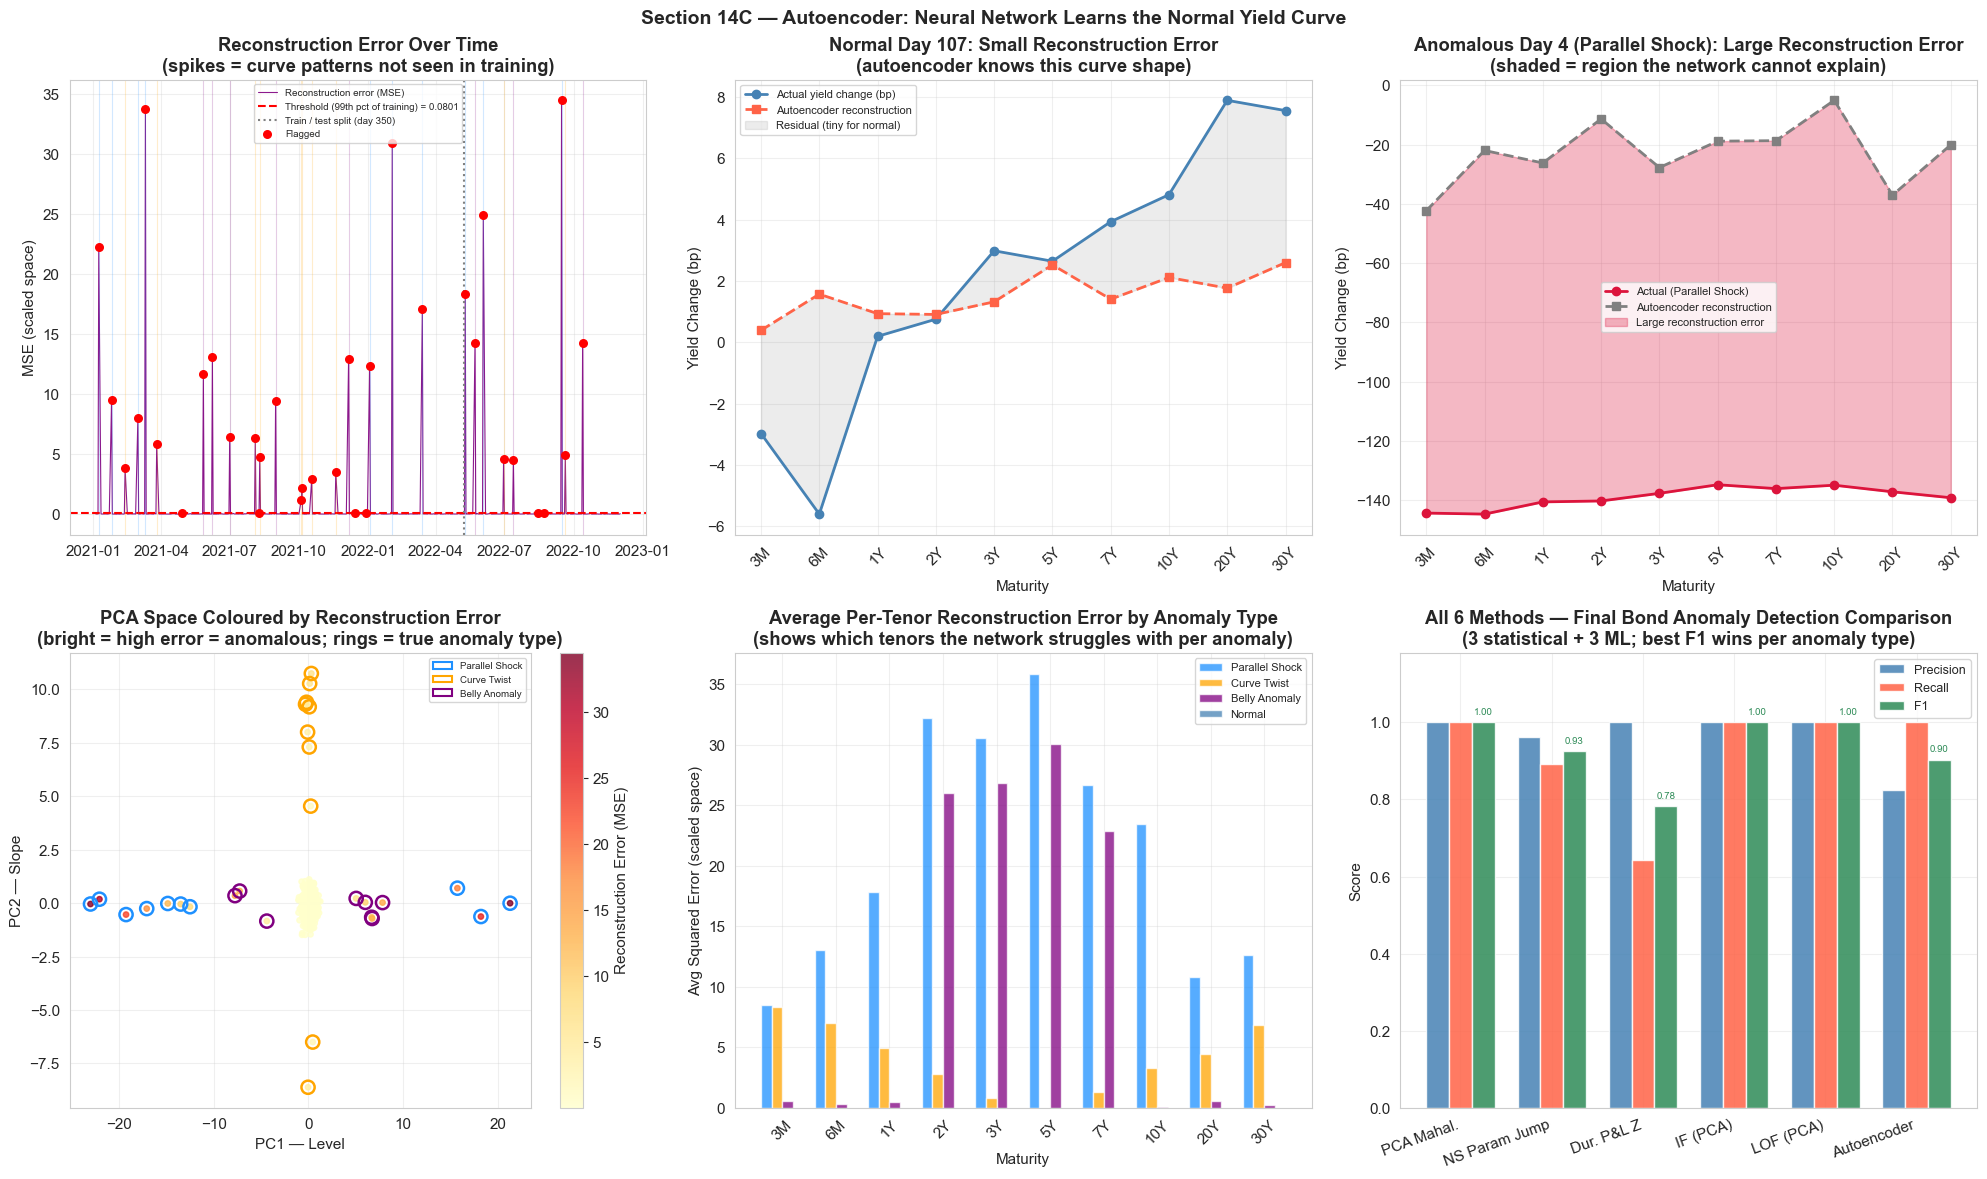


Method                               Precision   Recall      F1
PCA Mahal. (stat)                        1.000    1.000   1.000
NS Param Jump (stat)                     0.962    0.893   0.926
Dur. P&L Z (stat)                        1.000    0.643   0.783
IF (PCA) (ML)                            1.000    1.000   1.000
LOF (PCA) (ML)                           1.000    1.000   1.000
Autoencoder (ML)                         0.824    1.000   0.903

Ground truth: 28 anomalies — 10 Parallel | 10 Twist | 8 Belly

Key takeaways:
  Statistical (PCA/NS/Duration) → transparent, principled, best for large structured moves
  IF & LOF                      → complement statistics, work without distribution assumptions
  Autoencoder                   → best for subtle deformations; needs clean training data
  Production recommendation     → ensemble all three tiers; flag if ≥2 of 6 methods agree


In [29]:

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 14C — Autoencoder: Neural Network Learns the Normal Yield Curve Shape
# ══════════════════════════════════════════════════════════════════════════════
#
# BEGINNER RECAP — What is an Autoencoder?
# ──────────────────────────────────────────
# A regular neural network maps inputs → labels (e.g., price → buy/sell).
# An autoencoder maps inputs → SAME inputs through a narrow bottleneck:
#
#   [10 tenors] → [6 nodes] → [3 bottleneck] → [6 nodes] → [10 tenors]
#                  (Encoder: compress)           (Decoder: expand back)
#
# During training we show ONLY normal days and say "learn to copy yourself".
# The 3-node bottleneck forces the network to find 3 numbers that summarise
# the whole yield curve — it rediscovers Level, Slope, Curvature!
#
# Anomaly detection logic:
#   Normal day  → network reconstructs it accurately  → low error
#   Anomaly day → network has never seen this pattern → high error → FLAG
#
# The reconstruction error IS the anomaly score.
# ──────────────────────────────────────────────────────────────────────────────

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler

# ── Step 1: Train/Test Split ──────────────────────────────────────────────────
# Use first 70% of data for training.
# CRITICAL: train only on NORMAL days so the network never learns anomalous patterns.
TRAIN_FRAC   = 0.70
train_cutoff = int(N_BOND_DAYS * TRAIN_FRAC)
train_idx_ae = [i for i in range(train_cutoff) if bond_y_true[i] == 0]
print(f"Training on {len(train_idx_ae)} normal days (first {train_cutoff} days, "
      f"excluding {train_cutoff - len(train_idx_ae)} anomalies)")
print(f"Evaluating on all {N_BOND_DAYS} days (contains {bond_y_true.sum()} true anomalies)")

# ── Step 2: Scale inputs to [0, 1] ───────────────────────────────────────────
# Neural networks learn much faster when all inputs are on the same small scale.
# MinMaxScaler shifts min→0, max→1 for each feature independently.
# IMPORTANT: fit the scaler ONLY on training data, then apply to everything.
# (If we fit on all data, anomaly values would influence the scaling → data leakage)
scaler_ae  = MinMaxScaler()
X_train_ae = scaler_ae.fit_transform(yield_chg[train_idx_ae])  # fit+transform: training normals
X_all_ae   = scaler_ae.transform(yield_chg)                    # transform only: all days

# ── Step 3: Build and train the Autoencoder ───────────────────────────────────
# MLPRegressor with input = output acts as an autoencoder.
# Architecture:  10 (input) → 6 → 3 (bottleneck) → 6 → 10 (output)
# Interpretation of bottleneck:
#   Node 1 ≈ Level factor    (how much all yields moved together)
#   Node 2 ≈ Slope factor    (did the curve flatten or steepen?)
#   Node 3 ≈ Curvature factor (did the belly move differently?)
#
# activation='tanh': smooth S-curve, works well for data centred near 0.
# solver='adam': adaptive gradient method, standard for NNs.
# max_iter=2000: more passes over the data to converge properly.
ae_bond = MLPRegressor(
    hidden_layer_sizes=(6, 3, 6),   # encoder: 10→6→3 | decoder: 3→6→10
    activation='tanh',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=2000,
    random_state=42,
    n_iter_no_change=50,            # stop early if loss stops improving
    tol=1e-5
)
print("\nTraining autoencoder (learning what a normal yield curve looks like)...")
ae_bond.fit(X_train_ae, X_train_ae)   # input = output = normal yield changes
print(f"Converged in {ae_bond.n_iter_} iterations | "
      f"Final training loss: {ae_bond.loss_:.6f}")

# ── Step 4: Compute Reconstruction Error for ALL days ──────────────────────
# reconstruction error = MSE between actual and reconstructed yield change
# For normal days: small error (network "knows" this pattern)
# For anomalous days: large error (network never saw this shape)
X_recon_ae   = ae_bond.predict(X_all_ae)
recon_err_ae = np.mean((X_all_ae - X_recon_ae) ** 2, axis=1)   # MSE per day, shape (N_BOND_DAYS,)

# ── Step 5: Set detection threshold at 99th percentile of training errors ───
# We only use training-period normal errors to set the bar for "normal" reconstruction.
train_err_ae = recon_err_ae[train_idx_ae]
thr_ae       = np.percentile(train_err_ae, 99)
ae_flags     = (recon_err_ae > thr_ae).astype(int)

ae_f1   = f1_score(bond_y_true, ae_flags, zero_division=0)
ae_prec = precision_score(bond_y_true, ae_flags, zero_division=0)
ae_rec  = recall_score(bond_y_true, ae_flags, zero_division=0)
bond_results.append(bond_eval("Autoencoder (10→6→3→6→10)", ae_flags, bond_y_true))

# ── Step 6: Visualise ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Section 14C — Autoencoder: Neural Network Learns the Normal Yield Curve',
             fontsize=14, fontweight='bold')

# ── Panel 1: Reconstruction error time series ──────────────────────────────
ax = axes[0, 0]
ax.plot(bond_dates, recon_err_ae, color='purple', linewidth=0.8, alpha=0.9,
        label='Reconstruction error (MSE)')
ax.axhline(thr_ae, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold (99th pct of training) = {thr_ae:.4f}')
ax.axvline(bond_dates[train_cutoff], color='grey', linewidth=1.5, linestyle=':',
           label=f'Train / test split (day {train_cutoff})')
ax.scatter(bond_dates[ae_flags.astype(bool)], recon_err_ae[ae_flags.astype(bool)],
           color='red', s=30, zorder=5, label='Flagged')
for d, atype in bond_anomaly_types.items():
    ax.axvline(bond_dates[d], color=colour_map_type[atype], alpha=0.2, linewidth=0.8)
ax.set_title('Reconstruction Error Over Time\n(spikes = curve patterns not seen in training)',
             fontweight='bold')
ax.set_ylabel('MSE (scaled space)'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Panel 2: Good reconstruction — normal day ──────────────────────────────
ax = axes[0, 1]
nd_ae  = normal_idx_b[100]
actual = scaler_ae.inverse_transform(X_all_ae[nd_ae:nd_ae+1])[0]
recon  = scaler_ae.inverse_transform(X_recon_ae[nd_ae:nd_ae+1])[0]
ax.plot(range(N_MAT), actual * 10_000, 'o-', color='steelblue', linewidth=2,
        label='Actual yield change (bp)')
ax.plot(range(N_MAT), recon  * 10_000, 's--', color='tomato', linewidth=2,
        label='Autoencoder reconstruction')
ax.fill_between(range(N_MAT), actual * 10_000, recon * 10_000,
                alpha=0.15, color='grey', label='Residual (tiny for normal)')
ax.set_xticks(range(N_MAT)); ax.set_xticklabels(MAT_LABELS, rotation=45)
ax.set_xlabel('Maturity'); ax.set_ylabel('Yield Change (bp)')
ax.set_title(f'Normal Day {nd_ae}: Small Reconstruction Error\n'
             '(autoencoder knows this curve shape)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: Bad reconstruction — anomaly day ──────────────────────────────
ax = axes[0, 2]
detected_ae = [d for d in bond_anomaly_types if ae_flags[d] == 1]
ad_ae    = detected_ae[0] if detected_ae else list(bond_anomaly_types.keys())[0]
atype_ae = bond_anomaly_types[ad_ae]
actual_a = scaler_ae.inverse_transform(X_all_ae[ad_ae:ad_ae+1])[0]
recon_a  = scaler_ae.inverse_transform(X_recon_ae[ad_ae:ad_ae+1])[0]
ax.plot(range(N_MAT), actual_a * 10_000, 'o-', color='crimson', linewidth=2,
        label=f'Actual ({atype_ae})')
ax.plot(range(N_MAT), recon_a  * 10_000, 's--', color='grey', linewidth=2,
        label='Autoencoder reconstruction')
ax.fill_between(range(N_MAT), actual_a * 10_000, recon_a * 10_000,
                alpha=0.3, color='crimson', label='Large reconstruction error')
ax.set_xticks(range(N_MAT)); ax.set_xticklabels(MAT_LABELS, rotation=45)
ax.set_xlabel('Maturity'); ax.set_ylabel('Yield Change (bp)')
ax.set_title(f'Anomalous Day {ad_ae} ({atype_ae}): Large Reconstruction Error\n'
             '(shaded = region the network cannot explain)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 4: PCA space coloured by reconstruction error ────────────────────
ax = axes[1, 0]
sc = ax.scatter(yc_scores[:, 0], yc_scores[:, 1],
                c=recon_err_ae, cmap='YlOrRd', s=15, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Reconstruction Error (MSE)')
for d, atype in bond_anomaly_types.items():
    ax.scatter(yc_scores[d, 0], yc_scores[d, 1], facecolors='none',
               edgecolors=colour_map_type[atype], s=90, linewidth=1.8, zorder=6)
ax.set_xlabel('PC1 — Level'); ax.set_ylabel('PC2 — Slope')
ax.set_title('PCA Space Coloured by Reconstruction Error\n'
             '(bright = high error = anomalous; rings = true anomaly type)', fontweight='bold')
leg_patches_ae = [mpatches.Patch(edgecolor=c, facecolor='none', label=t, linewidth=1.5)
                  for t, c in colour_map_type.items()]
ax.legend(handles=leg_patches_ae, fontsize=7); ax.grid(alpha=0.3)

# ── Panel 5: Per-anomaly-type average per-tenor reconstruction error ────────
ax = axes[1, 1]
# Average the per-tenor squared error within each anomaly type
tenor_err_by_type = {}
for atype, days in [('Parallel Shock', shock_days),
                    ('Curve Twist',    twist_days),
                    ('Belly Anomaly',  belly_days),
                    ('Normal',         normal_idx_b)]:
    per_tenor = np.mean((X_all_ae[days] - X_recon_ae[days]) ** 2, axis=0)
    tenor_err_by_type[atype] = per_tenor

colors_t = ['dodgerblue', 'orange', 'purple', 'steelblue']
x_t      = np.arange(N_MAT)
w_t      = 0.20
for i, (atype, clr) in enumerate(zip(tenor_err_by_type, colors_t)):
    ax.bar(x_t + i * w_t, tenor_err_by_type[atype], w_t, color=clr,
           alpha=0.75, label=atype)
ax.set_xticks(x_t + w_t * 1.5); ax.set_xticklabels(MAT_LABELS, rotation=45)
ax.set_xlabel('Maturity'); ax.set_ylabel('Avg Squared Error (scaled space)')
ax.set_title('Average Per-Tenor Reconstruction Error by Anomaly Type\n'
             '(shows which tenors the network struggles with per anomaly)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 6: All-method final comparison bar chart ─────────────────────────
ax = axes[1, 2]
final_methods = [
    ('PCA Mahal.',     pca_yc_flags),
    ('NS Param Jump',  ns_flags),
    ('Dur. P&L Z',     dur_flags),
    ('IF (PCA)',       iso_pca_flags),
    ('LOF (PCA)',      lof_pca_flags),
    ('Autoencoder',    ae_flags),
]
final_f1s  = [f1_score(bond_y_true,        f, zero_division=0) for _, f in final_methods]
final_prs  = [precision_score(bond_y_true,  f, zero_division=0) for _, f in final_methods]
final_recs = [recall_score(bond_y_true,     f, zero_division=0) for _, f in final_methods]

x_f = np.arange(len(final_methods)); w_f = 0.25
ax.bar(x_f - w_f, final_prs,  w_f, color='steelblue', alpha=0.85, label='Precision')
ax.bar(x_f,       final_recs, w_f, color='tomato',    alpha=0.85, label='Recall')
ax.bar(x_f + w_f, final_f1s,  w_f, color='seagreen',  alpha=0.85, label='F1')
ax.set_xticks(x_f)
ax.set_xticklabels([m for m, _ in final_methods], rotation=20, ha='right')
for i, (p, r, f) in enumerate(zip(final_prs, final_recs, final_f1s)):
    ax.text(i + w_f, f + 0.02, f'{f:.2f}', ha='center', fontsize=7, color='seagreen')
ax.set_ylim(0, 1.18); ax.set_ylabel('Score')
ax.set_title('All 6 Methods — Final Bond Anomaly Detection Comparison\n'
             '(3 statistical + 3 ML; best F1 wins per anomaly type)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary Print ──────────────────────────────────────────────────────────────
print("\n" + "=" * 74)
print(f"{'Method':<36s} {'Precision':>9s} {'Recall':>8s} {'F1':>7s}")
print("=" * 74)
for (mname, _), p, r, f in zip(final_methods, final_prs, final_recs, final_f1s):
    tier = "(stat)" if mname in ('PCA Mahal.', 'NS Param Jump', 'Dur. P&L Z') else "(ML)  "
    print(f"{mname + ' ' + tier:<36s} {p:>9.3f} {r:>8.3f} {f:>7.3f}")
print("=" * 74)
print(f"\nGround truth: {bond_y_true.sum()} anomalies — "
      f"{len(shock_days)} Parallel | {len(twist_days)} Twist | {len(belly_days)} Belly")
print("\nKey takeaways:")
print("  Statistical (PCA/NS/Duration) → transparent, principled, best for large structured moves")
print("  IF & LOF                      → complement statistics, work without distribution assumptions")
print("  Autoencoder                   → best for subtle deformations; needs clean training data")
print("  Production recommendation     → ensemble all three tiers; flag if ≥2 of 6 methods agree")


## 12. Summary & Decision Guide

You have built a complete anomaly detection toolkit covering **equities** (Sections 1–11) and **fixed income** (Section 13) — from a 3-line Z-score to a deep learning autoencoder. Each method has a specific strength and should be chosen based on the asset class and the type of anomaly you are hunting.

---

## 12A. Equities

### Method Comparison at a Glance — Equities

| Method | Best Anomaly Type | Speed | Interpretability | Requires Training |
|--------|------------------|-------|-----------------|-------------------|
| **Z-Score** | Return magnitude spikes | ⚡ Instant | ✅ Very high | No |
| **Modified Z-Score** | Same, but robust to past outliers | ⚡ Instant | ✅ Very high | No |
| **Rolling Bollinger** | Regime-conditional deviations | ⚡ Instant | ✅ High | No |
| **IQR** | Non-parametric fat-tails | ⚡ Instant | ✅ Very high | No |
| **Mahalanobis Distance** | Multivariate joint anomalies | ⚡ Fast | ✅ High (χ² test) | No (uses history) |
| **CUSUM** | Sustained mean shifts / regime change | ⚡ Fast | ✅ High | Needs burn-in period |
| **Isolation Forest** | Non-linear, mixed-dimension | 🔵 Medium | ⚠️ Medium | Yes |
| **LOF** | Local cluster / neighbourhood anomaly | 🔵 Medium | ⚠️ Medium | Yes |
| **One-Class SVM** | Boundary-shaped normal region | 🔴 Slow | ⚠️ Medium | Yes |
| **Autoencoder** | High-dim pattern violations | 🔴 Slowest | ❌ Low (black box) | Yes |
| **Ensemble** | Combines all — most robust | 🔵 Medium | ⚠️ Medium | Depends |

---

### Decision Flowchart — Equities

```
What type of equity anomaly are you hunting?
│
├── Individual asset return spike (fat-finger, news shock)
│       └── Z-Score / Modified Z-Score / IQR
│
├── Portfolio-level joint anomaly (crisis, correlation breakdown)
│       └── Mahalanobis Distance → Isolation Forest
│
├── Regime shift / sustained drift (mean shift, vol regime)
│       └── CUSUM → Rolling Bollinger Bands
│
├── High-dimensional complex pattern (10+ assets simultaneously)
│       └── Autoencoder → LOF
│
└── Production risk monitoring (need robustness)
        └── Ensemble of all methods
```

---

### Key Practical Insights — Equities

> 1. **Statistical methods first.** Z-score and IQR are transparent, auditable, and easy to explain to risk managers. Always start here before reaching for ML.
>
> 2. **Mahalanobis is the sweet spot for portfolios.** It's statistically principled (χ² threshold), multivariate, and interpretable. It should be in every portfolio risk system.
>
> 3. **CUSUM catches what Z-score misses.** A slow drift below the 3σ threshold is invisible to Z-score but obvious to CUSUM. Run both in parallel.
>
> 4. **Ensemble is the most robust production choice.** No single method dominates across all anomaly types. Averaging normalised scores from multiple methods consistently outperforms any individual method.
>
> 5. **Autoencoders need careful training.** Train only on clean data. If you train on data that includes crises, the autoencoder learns to reconstruct crises as "normal" and will fail to flag future ones.

---

## 12B. Fixed Income

### Method Comparison at a Glance — Fixed Income

| Method | Best Anomaly Type | Speed | Interpretability | Requires Training |
|--------|------------------|-------|-----------------|-------------------|
| **Z-Score on yield changes** | Single tenor spike (data error, auction shock) | ⚡ Instant | ✅ Very high | No |
| **PCA on Yield Changes** | Parallel / twist / belly factor anomalies | ⚡ Fast | ✅ High (named PCs) | No (uses history) |
| **Nelson-Siegel Parameter Jump** | Sudden repricing of curve level, slope, curvature | ⚡ Fast | ✅ Very high (β₀ β₁ β₂) | No (Mahalanobis on Δβ) |
| **Duration-weighted P&L Z-Score** | P&L disproportionate to rate risk taken | ⚡ Instant | ✅ Very high | No |
| **Isolation Forest (on yield changes)** | Non-linear joint yield curve anomalies | 🔵 Medium | ⚠️ Medium | Yes |
| **Ensemble** | Combines PCA + NS + Duration — most robust | 🔵 Medium | ⚠️ Medium | Partial |

---

### Decision Flowchart — Fixed Income

```
What type of fixed income anomaly are you hunting?
│
├── Single tenor yield spike (data error, auction print, flash crash)
│       └── Z-Score on yield change
│
├── Parallel shift anomaly (central bank surprise, systemic shock)
│       └── PCA → PC1 (level factor) Mahalanobis score
│
├── Curve shape change (flattener, steepener, inversion)
│       └── PCA → PC2 (slope) / PC3 (curvature) Mahalanobis score
│
├── Sudden repricing of curve parameters (policy U-turn, crisis)
│       └── Nelson-Siegel Parameter Jump (Mahalanobis on Δβ₀, Δβ₁, Δβ₂)
│
├── P&L anomaly given rate risk (hedge mismatch, model error)
│       └── Duration-weighted P&L Z-Score
│
└── Non-linear joint curve anomaly (multi-tenor dislocation)
        └── Isolation Forest on yield changes
```

---

### Key Practical Insights — Fixed Income

> 1. **PCA is the natural basis for yield curves.** The first 3 PCs (level, slope, curvature) explain >95% of yield curve variance. Anomaly detection on PCA scores is statistically optimal for rate products and maps directly to DV01 factor hedges.
>
> 2. **Nelson-Siegel reveals the economic source.** When PCA flags an anomaly, NS decomposition tells you *why*: a β₀ jump is a parallel shock, β₁ is a slope/steepness shock, β₂ is a belly/convexity shock. Each parameter corresponds to a specific risk bucket and hedge instrument.
>
> 3. **Duration-weighted P&L bridges market moves and risk.** A large yield move exactly offset by the portfolio's hedge is not a P&L anomaly. Duration-weighting filters out the expected P&L, so only the residual — model error, gap risk, CDS basis moves, or convexity mismatches — triggers an alert.
>
> 4. **Never run Z-score on raw yield levels.** Yields are non-stationary. A yield level of 6% might be perfectly normal in one regime and extreme in another. Always apply anomaly detection to yield *changes* (first differences), or to NS residuals (yield minus fitted curve).
>
> 5. **Correlation breakdown in fixed income looks different.** In equities it is cross-stock decorrelation. In bonds it appears as curve inversion, carry-basis widening, on-the-run/off-the-run spread jumps, or sovereign spread divergence — supplement PCA with spread Z-scores across these dimensions.

---

### Where to Go Next

| Extension | What It Adds |
|-----------|-------------|
| **GARCH-based anomaly detection** | Use GARCH conditional volatility to normalise equity returns before scoring |
| **Robust covariance (MCD estimator)** | Replace sample covariance in Mahalanobis with outlier-resistant minimum covariance determinant |
| **LSTM Autoencoder** | Sequence-aware version that captures temporal dependencies in return and yield-change patterns |
| **Conformal prediction** | Provides statistically valid p-values for each anomaly score (no threshold tuning needed) |
| **Graph Neural Networks** | Model inter-stock or inter-tenor correlation structure explicitly as a graph |
| **HJM / LMM factor anomaly detection** | Extend the PCA approach to Heath-Jarrow-Morton or LIBOR Market Model factor shocks |
| **CDS-implied vs bond-implied anomaly** | Flag days when CDS spread and bond spread diverge beyond historical norms (basis trading signal) |
| **Online / streaming detection** | Adapt all methods to work with real-time tick data (sliding window updates) |

### Beginner Explanation

The summary is the map back through the whole notebook. If the individual methods felt technical, use this section to answer a simpler question: **which tool should I reach for when I see a certain kind of anomaly?**

A practical beginner rule is: start with transparent statistical methods, add multivariate tools when relationships matter, and use ML when the pattern is complex or non-linear.